# **Task 1: Data Handling**

*Initial configurations for the setup*

In [3]:
!pip install seaborn

In [4]:
!pip install scikit-learn

In [5]:
# Importing the required Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Display options are configured to make exploratory inspection
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [7]:
# Display floating-point values with a reasonable level of precision
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

*Import Data Files*

In [8]:
# Define the file paths
file_path_1 = "Data/Loan_Approval_Data_Set_1.csv"
file_path_2 = "Data/Loan_Approval_Data_Set_2.csv"

In [9]:
# Import the two CSV datasets
df1 = pd.read_csv(file_path_1)
df2 = pd.read_csv(file_path_2)

print("Dataset 1 imported successfully.")
print("Dataset 2 imported successfully.")

Dataset 1 imported successfully.
Dataset 2 imported successfully.


*Explore the Datasets*

In [10]:
# Inspect the dimensions of both datasets
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

Dataset 1 shape: (20000, 16)
Dataset 2 shape: (20000, 18)


In [11]:
# Display the column names of each dataset
print("Dataset 1 columns:")
print(df1.columns.tolist())
print("\nDataset 2 columns:")
print(df2.columns.tolist())

Dataset 1 columns:
['ID', 'ApplicationDate', 'AnnualIncome', 'EmploymentStatus', 'Experience', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'LoanApproved']

Dataset 2 columns:
['ApplicationDate', 'Age', 'CreditScore', 'EducationLevel', 'Experience', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'ID', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore']


In [12]:
# Examine the data types of Dataset 1 & Dataset 2
print("Dataset 1 data types:")
print(df1.dtypes)
print("\nDataset 2 data types:")
print(df2.dtypes)

Dataset 1 data types:
ID                           str
ApplicationDate              str
AnnualIncome               int64
EmploymentStatus             str
Experience                 int64
LoanDuration               int64
NumberOfDependents         int64
MonthlyDebtPayments        int64
NumberOfOpenCreditLines    int64
BankruptcyHistory          int64
PreviousLoanDefaults       int64
LengthOfCreditHistory      int64
CheckingAccountBalance     int64
TotalLiabilities           int64
NetWorth                   int64
LoanApproved               int64
dtype: object

Dataset 2 data types:
ApplicationDate                  str
Age                            int64
CreditScore                    int64
EducationLevel                   str
Experience                   float64
LoanAmount                     int64
MaritalStatus                    str
HomeOwnershipStatus              str
ID                               str
CreditCardUtilizationRate    float64
NumberOfCreditInquiries        int64
LoanPu

*Check the LoanApproved*

In [13]:
# Check the unique values of the LoanApproved variable

print("Unique LoanApproved values:")
print(df1["LoanApproved"].unique())

Unique LoanApproved values:
[0 1]


In [14]:
# Frequency distribution of LoanApproved

print("LoanApproved frequency:")
print(df1["LoanApproved"].value_counts(dropna=False))

LoanApproved frequency:
LoanApproved
0    15220
1     4780
Name: count, dtype: int64


In [15]:
# Check whether any unexpected values exist

valid_values = {0, 1}

unexpected_values = set(
    df1["LoanApproved"].dropna().unique()
) - valid_values

print("Unexpected LoanApproved values:")
print(unexpected_values)

Unexpected LoanApproved values:
set()


*Check for Columns*

In [16]:
# Identify columns that exist in both datasets
common_columns = df1.columns.intersection(
    df2.columns
)

print("Common columns:")
print(common_columns.tolist())

Common columns:
['ID', 'ApplicationDate', 'Experience']


In [17]:
# Identify columns unique to Dataset 1
dataset1_only = df1.columns.difference(
    df2.columns
)

print("Columns only in Dataset 1:")
print(dataset1_only.tolist())

Columns only in Dataset 1:
['AnnualIncome', 'BankruptcyHistory', 'CheckingAccountBalance', 'EmploymentStatus', 'LengthOfCreditHistory', 'LoanApproved', 'LoanDuration', 'MonthlyDebtPayments', 'NetWorth', 'NumberOfDependents', 'NumberOfOpenCreditLines', 'PreviousLoanDefaults', 'TotalLiabilities']


In [18]:
# Identify columns unique to Dataset 2
dataset2_only = df2.columns.difference(
    df1.columns
)

print("Columns only in Dataset 2:")
print(dataset2_only.tolist())

Columns only in Dataset 2:
['Age', 'CreditCardUtilizationRate', 'CreditScore', 'EducationLevel', 'HomeOwnershipStatus', 'InterestRate', 'JobTenure', 'LoanAmount', 'LoanPurpose', 'MaritalStatus', 'NumberOfCreditInquiries', 'PaymentHistory', 'RiskScore', 'SavingsAccountBalance', 'TotalAssets']


*Check for Primary Key*

In [19]:
# Check for completely duplicated rows

duplicate_rows_df1 = df1.duplicated().sum()
duplicate_rows_df2 = df2.duplicated().sum()
print("Duplicate rows in Dataset 1:", duplicate_rows_df1)
print("Duplicate rows in Dataset 2:", duplicate_rows_df2)

Duplicate rows in Dataset 1: 0
Duplicate rows in Dataset 2: 0


In [20]:
# Check whether ID exists in both datasets
print("Is 'ID' present in Dataset 1?", "ID" in df1.columns)
print("Is 'ID' present in Dataset 2?", "ID" in df2.columns)

Is 'ID' present in Dataset 1? True
Is 'ID' present in Dataset 2? True


In [21]:
# Check for missing IDs in Dataset 1 and Dataset 2

print(
    "Missing IDs in Dataset 1:",
    df1["ID"].isna().sum()
)

print(
    "Missing IDs in Dataset 2:",
    df2["ID"].isna().sum()
)

Missing IDs in Dataset 1: 0
Missing IDs in Dataset 2: 0


In [22]:
# Check whether IDs are unique within Dataset 1
print(
    "Duplicate IDs in Dataset 1:",
    df1["ID"].duplicated().sum()
)


# Check whether IDs are unique within Dataset 2
print(
    "Duplicate IDs in Dataset 2:",
    df2["ID"].duplicated().sum()
)

Duplicate IDs in Dataset 1: 0
Duplicate IDs in Dataset 2: 0


In [23]:
# Identify IDs that appear in both datasets

common_ids = set(df1["ID"]).intersection(
    set(df2["ID"])
)

print(
    "Number of IDs appearing in both datasets:",
    len(common_ids)
)

Number of IDs appearing in both datasets: 20000


In [24]:
# IDs present in Dataset 1 but not Dataset 2

ids_only_dataset1 = set(
    df1["ID"]
) - set(
    df2["ID"]
)

print(
    "IDs only in Dataset 1:",
    len(ids_only_dataset1)
)

IDs only in Dataset 1: 0


In [25]:
# IDs present in Dataset 2 but not Dataset 1

ids_only_dataset2 = set(
    df2["ID"]
) - set(
    df1["ID"]
)

print(
    "IDs only in Dataset 2:",
    len(ids_only_dataset2)
)

IDs only in Dataset 2: 0


In [26]:
print("Same IDs in both datasets:", set(df1["ID"]) == set(df2["ID"]))

Same IDs in both datasets: True


In [27]:
print("Dataset 1 duplicate IDs:", df1["ID"].duplicated().sum())
print("Dataset 2 duplicate IDs:", df2["ID"].duplicated().sum())

print("Dataset 1 missing IDs:", df1["ID"].isna().sum())
print("Dataset 2 missing IDs:", df2["ID"].isna().sum())

# Find IDs that exist in both datasets
common_ids = set(df1["ID"]).intersection(set(df2["ID"]))

print("Number of common IDs:", len(common_ids))

Dataset 1 duplicate IDs: 0
Dataset 2 duplicate IDs: 0
Dataset 1 missing IDs: 0
Dataset 2 missing IDs: 0
Number of common IDs: 20000


*Merging*

In [28]:
# Merge Dataset 1 and Dataset 2 using the validated ID field

merged_df = pd.merge( df1, df2, on="ID", how="inner", suffixes=("_df1", "_df2") )

In [29]:
print("Merged dataset shape:", merged_df.shape)

Merged dataset shape: (20000, 33)


In [30]:
print(merged_df.columns.tolist())

['ID', 'ApplicationDate_df1', 'AnnualIncome', 'EmploymentStatus', 'Experience_df1', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'LoanApproved', 'ApplicationDate_df2', 'Age', 'CreditScore', 'EducationLevel', 'Experience_df2', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore']


In [31]:
print("Dataset 1 rows:", len(df1))
print("Dataset 2 rows:", len(df2))
print("Merged rows:", len(merged_df))

Dataset 1 rows: 20000
Dataset 2 rows: 20000
Merged rows: 20000


In [32]:
print("Merged duplicate IDs:", merged_df["ID"].duplicated().sum())

Merged duplicate IDs: 0


In [33]:
# Display model and pipeline variable names
model_names = [
    name for name in globals()
    if any(word in name.lower() for word in [
        "model", "pipeline", "grid", "tree", "forest", "kmeans"
    ])
]

print("\n".join(sorted(model_names)))

In [34]:
# Display all user-defined variables
all_variables = [
    name for name in globals()
    if not name.startswith("_")
]

print("\n".join(sorted(all_variables)))

In
Out
common_columns
common_ids
dataset1_only
dataset2_only
df1
df2
duplicate_rows_df1
duplicate_rows_df2
exit
file_path_1
file_path_2
get_ipython
ids_only_dataset1
ids_only_dataset2
merged_df
model_names
np
open
pd
plt
quit
sns
unexpected_values
valid_values


# **Task 2 : Exploratory Data Analysis (EDA)**

In [35]:
# Check the shape of the merged dataset
print("Number of rows:", merged_df.shape[0])
print("Number of columns:", merged_df.shape[1])

Number of rows: 20000
Number of columns: 33


In [36]:
# Display the first five rows
merged_df.head()

,ID,ApplicationDate_df1,AnnualIncome,EmploymentStatus,Experience_df1,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,CheckingAccountBalance,TotalLiabilities,NetWorth,LoanApproved,ApplicationDate_df2,Age,CreditScore,EducationLevel,Experience_df2,LoanAmount,MaritalStatus,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfCreditInquiries,LoanPurpose,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore
0,A001,01-01-2018,39948,Employed,22,48,2,183,1,0,0,9,1202,19183,126928,0,01-01-2018,45,617,Master,22.000,13152,Married,Own,35.400,2,Home,29,7632,146111,11,22.750,49
1,A002,02-01-2018,39709,Employed,15,48,1,496,5,0,0,9,3460,9595,43609,0,02-01-2018,38,628,Associate,NaN,26045,Single,Mortgage,8.780,3,Debt Consolidation,21,4627,53204,3,20.100,XX
2,A003,03-01-2018,40724,Employed,26,36,2,902,2,0,0,22,895,128874,5205,0,03-01-2018,47,570,Bachelor,26.000,17627,Married,Rent,13.700,0,Education,20,886,25176,6,21.250,XX
3,A004,04-01-2018,69084,Employed,34,96,1,755,2,0,0,10,1217,5370,99452,0,04-01-2018,58,545,High School,34.000,37898,Single,Mortgage,2.670,1,Home,27,1675,104822,5,30.090,54
4,A005,05-01-2018,103264,Employed,17,36,1,274,0,0,0,27,4981,17286,227019,1,05-01-2018,37,594,Associate,17.000,9184,Married,Mortgage,3.200,0,Debt Consolidation,26,1555,244305,5,17.590,36


In [37]:
# Display the last five rows
merged_df.tail()

,ID,ApplicationDate_df1,AnnualIncome,EmploymentStatus,Experience_df1,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,CheckingAccountBalance,TotalLiabilities,NetWorth,LoanApproved,ApplicationDate_df2,Age,CreditScore,EducationLevel,Experience_df2,LoanAmount,MaritalStatus,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfCreditInquiries,LoanPurpose,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore
19995,B9997,29-09-2024,30180,Employed,19,36,3,673,5,0,0,7,3429,25642,55327,0,29-09-2072,44,587,High School,19.000,24521,Married,Rent,10.100,1,Auto,21,235,80969,1,19.550,55
19996,B9998,30-09-2024,49246,Employed,33,36,5,414,2,0,0,28,183,5569,64002,0,30-09-2072,56,567,Associate,33.000,25818,Married,Rent,47.100,0,Debt Consolidation,30,6910,69571,3,19.910,54
19997,B9999,01-10-2024,48958,Employed,20,72,3,512,3,0,0,8,746,4653,103663,0,01-10-2072,44,645,Bachelor,20.000,37033,Married,Mortgage,21.600,1,Home,28,2175,108316,3,22.670,45
19998,C001,02-10-2024,41025,Employed,36,72,3,986,4,0,0,13,260,11485,10600,0,02-10-2072,60,560,High School,36.000,14760,Married,Own,36.400,1,Debt Consolidation,17,3037,22085,5,26.480,59
19999,C002,03-10-2024,53227,Employed,0,48,0,272,3,0,0,14,1766,41636,41372,0,03-10-2072,20,574,Associate,0.000,32055,Married,Own,5.360,1,Other,36,2682,83008,5,24.260,59


In [38]:
# Display all column names
print(merged_df.columns.tolist())

['ID', 'ApplicationDate_df1', 'AnnualIncome', 'EmploymentStatus', 'Experience_df1', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'LoanApproved', 'ApplicationDate_df2', 'Age', 'CreditScore', 'EducationLevel', 'Experience_df2', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore']


In [39]:
# Display the data type of each column
print(merged_df.dtypes)

ID                               str
ApplicationDate_df1              str
AnnualIncome                   int64
EmploymentStatus                 str
Experience_df1                 int64
LoanDuration                   int64
NumberOfDependents             int64
MonthlyDebtPayments            int64
NumberOfOpenCreditLines        int64
BankruptcyHistory              int64
PreviousLoanDefaults           int64
LengthOfCreditHistory          int64
CheckingAccountBalance         int64
TotalLiabilities               int64
NetWorth                       int64
LoanApproved                   int64
ApplicationDate_df2              str
Age                            int64
CreditScore                    int64
EducationLevel                   str
Experience_df2               float64
LoanAmount                     int64
MaritalStatus                    str
HomeOwnershipStatus              str
CreditCardUtilizationRate    float64
NumberOfCreditInquiries        int64
LoanPurpose                      str
P

In [40]:
# Display dataset structure and non-null information
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         20000 non-null  str    
 1   ApplicationDate_df1        20000 non-null  str    
 2   AnnualIncome               20000 non-null  int64  
 3   EmploymentStatus           20000 non-null  str    
 4   Experience_df1             20000 non-null  int64  
 5   LoanDuration               20000 non-null  int64  
 6   NumberOfDependents         20000 non-null  int64  
 7   MonthlyDebtPayments        20000 non-null  int64  
 8   NumberOfOpenCreditLines    20000 non-null  int64  
 9   BankruptcyHistory          20000 non-null  int64  
 10  PreviousLoanDefaults       20000 non-null  int64  
 11  LengthOfCreditHistory      20000 non-null  int64  
 12  CheckingAccountBalance     20000 non-null  int64  
 13  TotalLiabilities           20000 non-null  int64  
 14  N

In [41]:
# Count unique values in every column
unique_counts = merged_df.nunique()

print(unique_counts)

ID                           20000
ApplicationDate_df1           2922
AnnualIncome                 17516
EmploymentStatus                 3
Experience_df1                  62
LoanDuration                    10
NumberOfDependents               6
MonthlyDebtPayments           1299
NumberOfOpenCreditLines         14
BankruptcyHistory                2
PreviousLoanDefaults             2
LengthOfCreditHistory           29
CheckingAccountBalance        5151
TotalLiabilities             17163
NetWorth                     17724
LoanApproved                     2
ApplicationDate_df2          20000
Age                             63
CreditScore                    322
EducationLevel                   5
Experience_df2                  61
LoanAmount                   15578
MaritalStatus                    4
HomeOwnershipStatus              4
CreditCardUtilizationRate     1962
NumberOfCreditInquiries          8
LoanPurpose                      5
PaymentHistory                  38
SavingsAccountBalanc

In [42]:
# Create a summary of data types, unique values and missing values
column_summary = pd.DataFrame({
    "Data Type": merged_df.dtypes,
    "Unique Values": merged_df.nunique(),
    "Missing Values": merged_df.isnull().sum(),
    "Missing Percentage": (merged_df.isnull().sum() / len(merged_df)) * 100
})

print(column_summary)

                          Data Type  Unique Values  Missing Values  \
ID                              str          20000               0   
ApplicationDate_df1             str           2922               0   
AnnualIncome                  int64          17516               0   
EmploymentStatus                str              3               0   
Experience_df1                int64             62               0   
LoanDuration                  int64             10               0   
NumberOfDependents            int64              6               0   
MonthlyDebtPayments           int64           1299               0   
NumberOfOpenCreditLines       int64             14               0   
BankruptcyHistory             int64              2               0   
PreviousLoanDefaults          int64              2               0   
LengthOfCreditHistory         int64             29               0   
CheckingAccountBalance        int64           5151               0   
TotalLiabilities    

In [43]:
# Display columns containing missing values
missing_values = merged_df.isnull().sum()

print(missing_values[missing_values > 0])

Experience_df2    666
MaritalStatus      15
dtype: int64


In [44]:
# Calculate missing value percentage
missing_percentage = (merged_df.isnull().sum() / len(merged_df)) * 100

print(missing_percentage[missing_percentage > 0])

Experience_df2   3.330
MaritalStatus    0.075
dtype: float64


In [45]:
# Create a missing value summary
missing_summary = pd.DataFrame({
    "Missing Values": merged_df.isnull().sum(),
    "Missing Percentage": (merged_df.isnull().sum() / len(merged_df)) * 100
})

print(missing_summary[missing_summary["Missing Values"] > 0])

                Missing Values  Missing Percentage
Experience_df2             666               3.330
MaritalStatus               15               0.075


In [46]:
# Count records where Experience_df2 is missing but Experience_df1 is available
print(
    (
        merged_df["Experience_df2"].isna() &
        merged_df["Experience_df1"].notna()
    ).sum()
)

666


In [47]:
# Compare Experience values where both datasets contain values
experience_mismatch = (
    merged_df["Experience_df1"].notna() &
    merged_df["Experience_df2"].notna() &
    (merged_df["Experience_df1"] != merged_df["Experience_df2"])
)

print("Experience mismatches:", experience_mismatch.sum())

Experience mismatches: 0


In [48]:
# Count missing Experience values in Dataset 2 with available Dataset 1 values
recoverable_experience = (
    merged_df["Experience_df2"].isna() &
    merged_df["Experience_df1"].notna()
).sum()

print("Recoverable Experience values:", recoverable_experience)

Recoverable Experience values: 666


In [49]:
# Display all MaritalStatus categories including missing values
print(merged_df["MaritalStatus"].value_counts(dropna=False))

MaritalStatus
Married     10029
Single       6077
Divorced     2881
Widowed       998
NaN            15
Name: count, dtype: int64


In [50]:
# Count the NA string in MaritalStatus
print((merged_df["MaritalStatus"] == "NA").sum())

0


In [51]:
# Count completely duplicated records
print("Duplicate rows:", merged_df.duplicated().sum())

Duplicate rows: 0


In [52]:
# Identify numerical columns
numerical_columns = merged_df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['AnnualIncome', 'Experience_df1', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'LoanApproved', 'Age', 'CreditScore', 'Experience_df2', 'LoanAmount', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate']


In [53]:
# Identify object columns
categorical_columns = merged_df.select_dtypes(
    include=["object"]
).columns

print("Object columns:")
print(categorical_columns.tolist())

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10704\2517982895.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = merged_df.select_dtypes(


Object columns:
['ID', 'ApplicationDate_df1', 'EmploymentStatus', 'ApplicationDate_df2', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'RiskScore']


In [54]:
# Generate descriptive statistics for numerical variables
merged_df[numerical_columns].describe()

,AnnualIncome,Experience_df1,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,CheckingAccountBalance,TotalLiabilities,NetWorth,LoanApproved,Age,CreditScore,Experience_df2,LoanAmount,CreditCardUtilizationRate,NumberOfCreditInquiries,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,19334.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,59161.474,17.523,54.057,1.517,454.293,3.023,0.052,0.100,14.957,1782.555,36252.413,72294.319,0.239,39.753,571.612,17.610,24882.868,37.776,0.993,23.994,4946.052,96964.395,5.003,23.906
std,40350.845,11.317,24.665,1.386,240.508,1.736,0.223,0.300,8.372,2245.379,47251.511,117920.021,0.426,11.623,50.997,11.500,13427.421,110.336,0.987,4.945,6604.887,120799.939,2.237,4.221
min,15000.000,0.000,12.000,0.000,50.000,0.000,0.000,0.000,1.000,24.000,372.000,1000.000,0.000,18.000,343.000,0.000,3674.000,1.000,0.000,8.000,73.000,2098.000,0.000,11.330
25%,31679.000,9.000,36.000,0.000,286.000,2.000,0.000,0.000,8.000,551.000,11196.750,8734.750,0.000,32.000,540.000,9.000,15575.000,4.100,0.000,21.000,1541.750,31180.250,3.000,20.910
50%,48566.000,17.000,48.000,1.000,402.000,3.000,0.000,0.000,15.000,1116.000,22203.000,32855.500,0.000,40.000,578.000,18.000,21914.500,11.300,1.000,24.000,2986.000,60699.000,5.000,23.530
75%,74391.000,25.000,72.000,2.000,564.000,4.000,0.000,0.000,22.000,2126.000,43146.500,88825.500,0.000,48.000,609.000,26.000,30835.000,25.600,2.000,27.000,5873.250,117405.250,6.000,26.550
max,485341.000,61.000,120.000,5.000,2919.000,13.000,1.000,1.000,29.000,52572.000,1417302.000,2603208.000,1.000,80.000,712.000,61.000,184732.000,992.000,7.000,45.000,200089.000,2619627.000,16.000,44.670


In [55]:
# Generate descriptive statistics for categorical variables
merged_df[categorical_columns].describe()

,ID,ApplicationDate_df1,EmploymentStatus,ApplicationDate_df2,EducationLevel,MaritalStatus,HomeOwnershipStatus,LoanPurpose,RiskScore
count,20000,20000,20000,20000,20000,19985,20000,20000,20000
unique,20000,2922,3,20000,5,4,4,5,53
top,A001,01-01-2018,Employed,01-01-2018,Bachelor,Married,Mortgage,Home,XX
freq,1,7,17036,1,6054,10029,7939,5925,1275


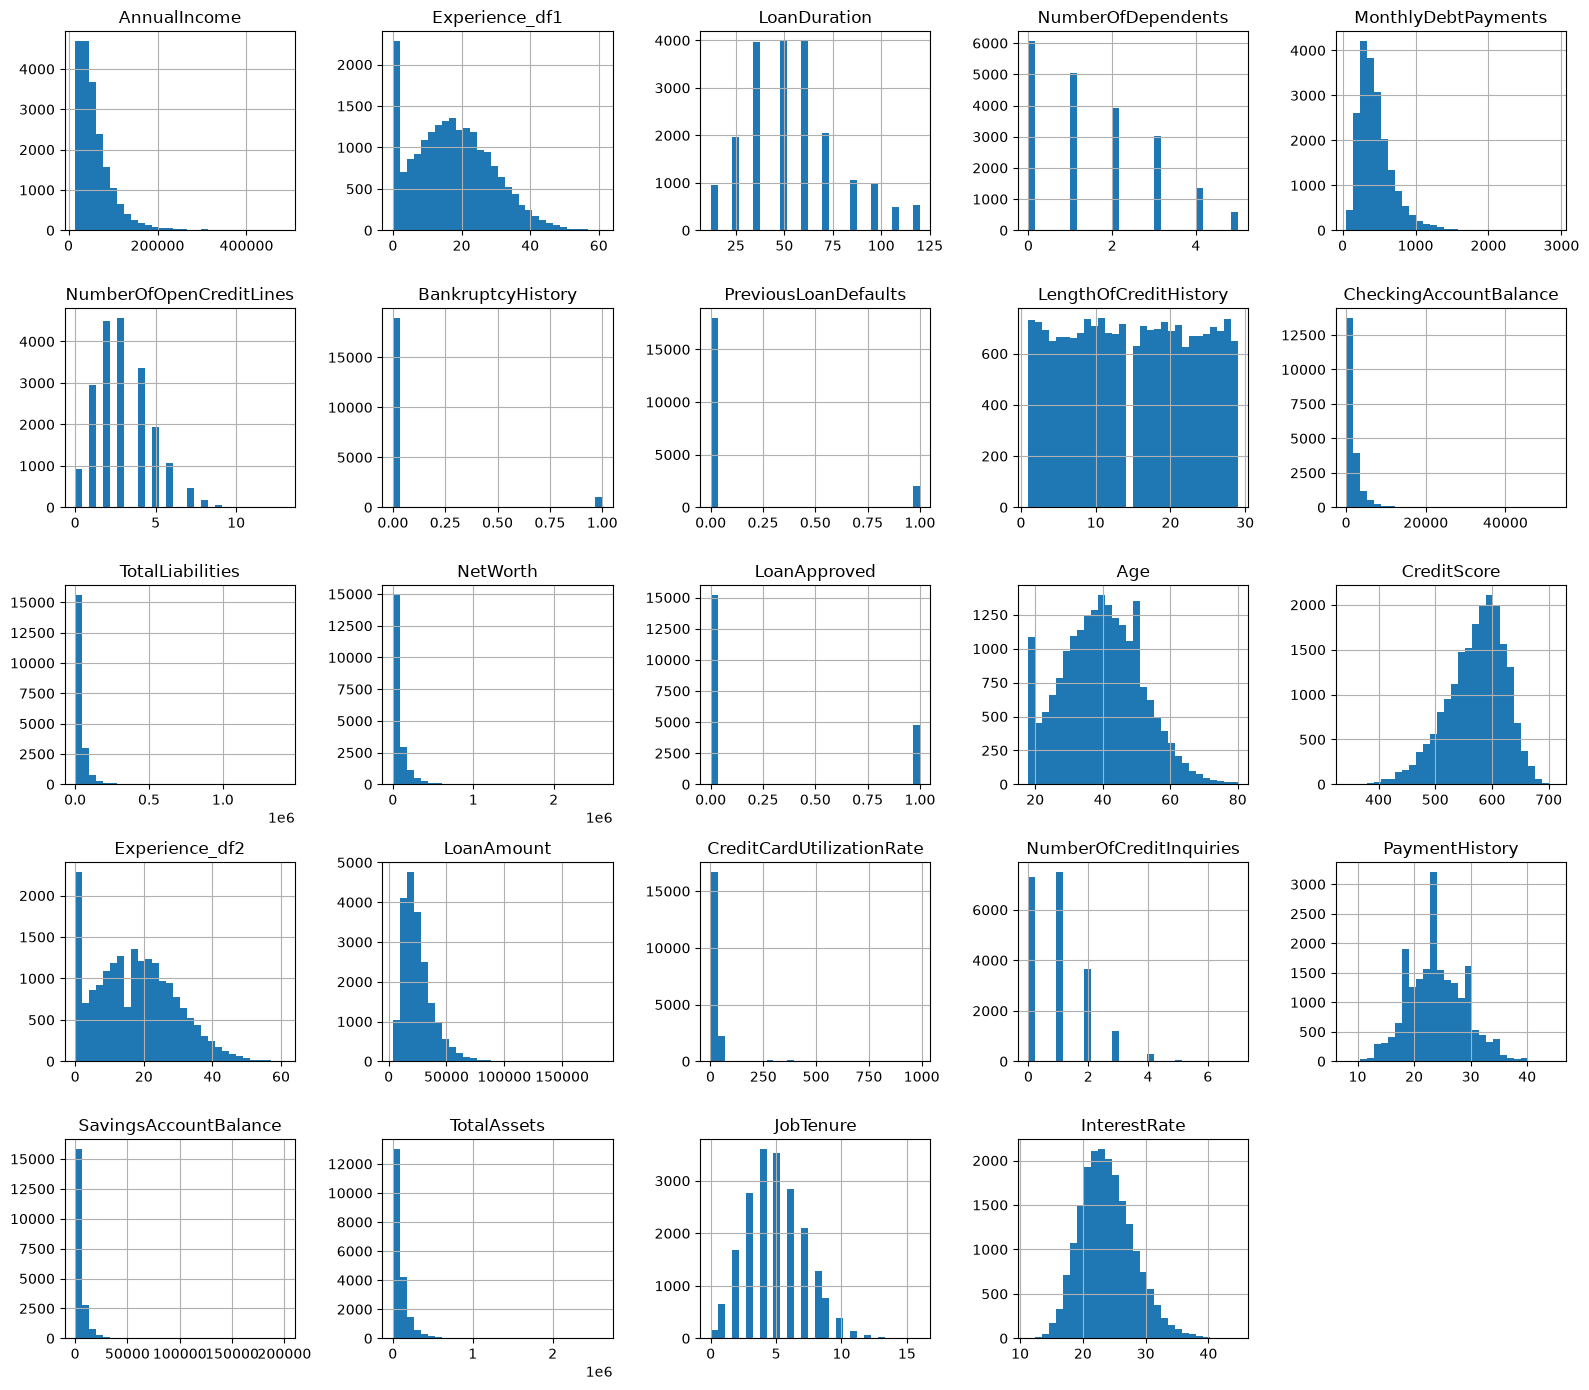

In [56]:
# Plot histograms for numerical variables
merged_df[numerical_columns].hist(figsize=(16, 14), bins=30)

plt.tight_layout()
plt.show()

In [57]:
# Display category frequencies for object variables
for column in categorical_columns:
    print("\n", column)
    print(merged_df[column].value_counts(dropna=False))


 ID
ID
A001     1
A002     1
A003     1
A004     1
A005     1
        ..
B9997    1
B9998    1
B9999    1
C001     1
C002     1
Name: count, Length: 20000, dtype: int64

 ApplicationDate_df1
ApplicationDate_df1
01-01-2018    7
02-01-2018    7
03-01-2018    7
04-01-2018    7
05-01-2018    7
             ..
27-12-2025    6
28-12-2025    6
29-12-2025    6
30-12-2025    6
31-12-2025    6
Name: count, Length: 2922, dtype: int64

 EmploymentStatus
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

 ApplicationDate_df2
ApplicationDate_df2
01-01-2018    1
02-01-2018    1
03-01-2018    1
04-01-2018    1
05-01-2018    1
             ..
29-09-2072    1
30-09-2072    1
01-10-2072    1
02-10-2072    1
03-10-2072    1
Name: count, Length: 20000, dtype: int64

 EducationLevel
EducationLevel
Bachelor       6054
High School    5908
Associate      4034
Master         3050
Doctorate       954
Name: count, dtype: int64

 MaritalStatus
MaritalS

In [58]:
# Count observations in each LoanApproved class
print(merged_df["LoanApproved"].value_counts())

LoanApproved
0    15220
1     4780
Name: count, dtype: int64


In [59]:
# Calculate LoanApproved class percentages
loan_approval_percentage = (
    merged_df["LoanApproved"].value_counts(normalize=True) * 100
)

print(loan_approval_percentage)

LoanApproved
0   76.100
1   23.900
Name: proportion, dtype: float64


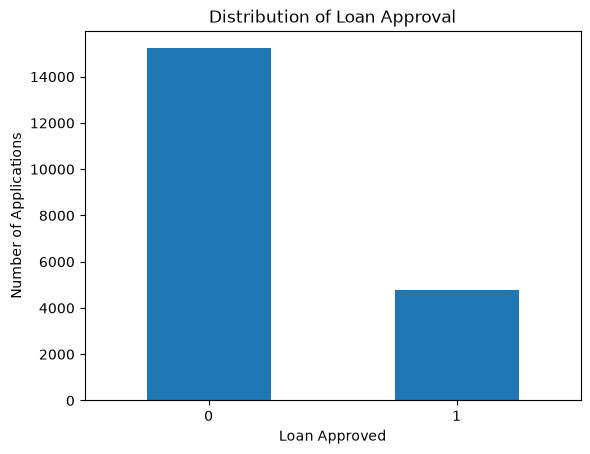

In [60]:
# Plot the distribution of loan approval classes
merged_df["LoanApproved"].value_counts().plot(kind="bar")

plt.xlabel("Loan Approved")
plt.ylabel("Number of Applications")
plt.title("Distribution of Loan Approval")
plt.xticks(rotation=0)

plt.show()

In [61]:
# Count missing Experience values in Dataset 1
print("Missing Experience_df1:", merged_df["Experience_df1"].isna().sum())

# Count missing Experience values in Dataset 2
print("Missing Experience_df2:", merged_df["Experience_df2"].isna().sum())

Missing Experience_df1: 0
Missing Experience_df2: 666


In [62]:
# Identify Experience mismatches where both values exist
experience_mismatch = (
    merged_df["Experience_df1"].notna() &
    merged_df["Experience_df2"].notna() &
    (merged_df["Experience_df1"] != merged_df["Experience_df2"])
)

print("Experience mismatches:", experience_mismatch.sum())

Experience mismatches: 0


In [63]:
# Count missing Experience values that can be recovered from Dataset 1
recoverable_experience = (
    merged_df["Experience_df2"].isna() &
    merged_df["Experience_df1"].notna()
).sum()

print("Recoverable Experience values:", recoverable_experience)

Recoverable Experience values: 666


In [64]:
# Fill missing Experience values using the verified Dataset 1 values
merged_df["Experience"] = merged_df["Experience_df2"].fillna(
    merged_df["Experience_df1"]
)

In [65]:
# Convert consolidated Experience to integer
merged_df["Experience"] = merged_df["Experience"].astype(int)

In [66]:
# Verify missing values after Experience recovery
print("Missing Experience:", merged_df["Experience"].isna().sum())

Missing Experience: 0


In [67]:
# Display MaritalStatus frequencies including missing values
print(merged_df["MaritalStatus"].value_counts(dropna=False))

MaritalStatus
Married     10029
Single       6077
Divorced     2881
Widowed       998
NaN            15
Name: count, dtype: int64


In [68]:
# Display the unique MaritalStatus categories
print(merged_df["MaritalStatus"].unique())

<ArrowStringArray>
['Married', 'Single', 'Divorced', 'Widowed', nan]
Length: 5, dtype: str


In [69]:
# Replace missing MaritalStatus values with Unknown
merged_df["MaritalStatus"] = merged_df["MaritalStatus"].fillna("Unknown")

In [70]:
# Check missing MaritalStatus values after treatment
print("Missing MaritalStatus:", merged_df["MaritalStatus"].isna().sum())

Missing MaritalStatus: 0


In [71]:
# Display RiskScore values including missing values
print(merged_df["RiskScore"].value_counts(dropna=False))

RiskScore
XX    1275
51    1271
53    1254
54    1226
55    1160
50    1095
56     912
49     890
57     826
40     799
48     748
58     719
59     622
36     547
47     527
60     474
44     473
39     426
46     420
38     382
41     376
42     369
61     350
37     338
45     325
43     318
62     307
63     220
35     185
64     164
65     145
66     116
34     109
67     106
33      96
32      93
68      78
70      57
69      54
71      29
31      25
72      24
73      19
74      11
30       9
29       6
75       6
28       5
76       5
79       3
77       3
78       2
84       1
Name: count, dtype: int64


In [72]:
# Display the number of invalid RiskScore values
invalid_risk_score_count = (merged_df["RiskScore"] == "XX").sum()

print("Invalid RiskScore values:", invalid_risk_score_count)

Invalid RiskScore values: 1275


In [73]:
# Calculate the percentage of invalid RiskScore values
invalid_risk_percentage = (
    invalid_risk_score_count / len(merged_df)
) * 100

print("Invalid RiskScore percentage:", invalid_risk_percentage)

Invalid RiskScore percentage: 6.375


In [74]:
# Convert RiskScore temporarily to numeric
risk_score_numeric = pd.to_numeric(
    merged_df["RiskScore"],
    errors="coerce"
)

# Identify non-numeric RiskScore values
invalid_risk_values = (
    risk_score_numeric.isna() &
    merged_df["RiskScore"].notna()
)

# Display the non-numeric values
print(
    merged_df.loc[
        invalid_risk_values,
        "RiskScore"
    ].value_counts()
)

RiskScore
XX    1275
Name: count, dtype: int64


In [75]:
# Convert invalid RiskScore values to missing values
merged_df["RiskScore"] = pd.to_numeric(
    merged_df["RiskScore"],
    errors="coerce"
)

In [76]:
# Check the RiskScore data type after conversion
print("RiskScore data type:", merged_df["RiskScore"].dtype)

RiskScore data type: float64


In [77]:
# Count missing RiskScore values after conversion
print("Missing RiskScore:", merged_df["RiskScore"].isna().sum())

Missing RiskScore: 1275


In [78]:
# Create the updated missing value summary
missing_summary = pd.DataFrame({
    "Missing Values": merged_df.isnull().sum(),
    "Missing Percentage": (
        merged_df.isnull().sum() / len(merged_df)
    ) * 100
})

# Display only columns containing missing values
print(
    missing_summary[
        missing_summary["Missing Values"] > 0
    ]
)

                Missing Values  Missing Percentage
Experience_df2             666               3.330
RiskScore                 1275               6.375


In [79]:
# Display descriptive statistics for RiskScore
print(merged_df["RiskScore"].describe())

count   18725.000
mean       50.579
std         8.170
min        28.000
25%        45.000
50%        51.000
75%        56.000
max        84.000
Name: RiskScore, dtype: float64


In [80]:
# Display the minimum and maximum RiskScore
print("Minimum RiskScore:", merged_df["RiskScore"].min())
print("Maximum RiskScore:", merged_df["RiskScore"].max())

Minimum RiskScore: 28.0
Maximum RiskScore: 84.0


In [81]:
# Create an indicator for missing RiskScore values
merged_df["RiskScoreMissing"] = merged_df["RiskScore"].isna()

In [82]:
# Compare loan approval rates for missing and available RiskScore
print(
    merged_df.groupby("RiskScoreMissing")["LoanApproved"]
    .mean() * 100
)

RiskScoreMissing
False   25.442
True     1.255
Name: LoanApproved, dtype: float64


In [83]:
# Compare RiskScore missingness with LoanApproved
risk_missing_crosstab = pd.crosstab(
    merged_df["RiskScoreMissing"],
    merged_df["LoanApproved"],
    normalize="index"
) * 100

print(risk_missing_crosstab)

LoanApproved          0      1
RiskScoreMissing              
False            74.558 25.442
True             98.745  1.255


In [84]:
# Convert invalid RiskScore values to missing values
merged_df["RiskScore"] = pd.to_numeric(
    merged_df["RiskScore"],
    errors="coerce"
)

In [85]:
# Create an indicator showing whether RiskScore was missing
merged_df["RiskScoreMissing"] = merged_df["RiskScore"].isna()

In [86]:
# Calculate the median RiskScore
risk_score_median = merged_df["RiskScore"].median()

# Fill missing RiskScore values with the median
merged_df["RiskScore"] = merged_df["RiskScore"].fillna(
    risk_score_median
)

In [87]:
# Check missing RiskScore values after imputation
print("Missing RiskScore after imputation:",
      merged_df["RiskScore"].isna().sum())

Missing RiskScore after imputation: 0


In [88]:
# Check the number of originally missing RiskScore records
print(merged_df["RiskScoreMissing"].value_counts())

RiskScoreMissing
False    18725
True      1275
Name: count, dtype: int64


In [89]:
# Create a copy of the merged dataset for preprocessing
df = merged_df.copy()

In [90]:
# Display the initial number of rows and columns
print("Rows before preprocessing:", df.shape[0])
print("Columns before preprocessing:", df.shape[1])

Rows before preprocessing: 20000
Columns before preprocessing: 35


In [91]:
# Display all current column names
print(df.columns.tolist())

['ID', 'ApplicationDate_df1', 'AnnualIncome', 'EmploymentStatus', 'Experience_df1', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'LoanApproved', 'ApplicationDate_df2', 'Age', 'CreditScore', 'EducationLevel', 'Experience_df2', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience', 'RiskScoreMissing']


In [92]:
# Display the current data types
print(df.dtypes)

ID                               str
ApplicationDate_df1              str
AnnualIncome                   int64
EmploymentStatus                 str
Experience_df1                 int64
LoanDuration                   int64
NumberOfDependents             int64
MonthlyDebtPayments            int64
NumberOfOpenCreditLines        int64
BankruptcyHistory              int64
PreviousLoanDefaults           int64
LengthOfCreditHistory          int64
CheckingAccountBalance         int64
TotalLiabilities               int64
NetWorth                       int64
LoanApproved                   int64
ApplicationDate_df2              str
Age                            int64
CreditScore                    int64
EducationLevel                   str
Experience_df2               float64
LoanAmount                     int64
MaritalStatus                    str
HomeOwnershipStatus              str
CreditCardUtilizationRate    float64
NumberOfCreditInquiries        int64
LoanPurpose                      str
P

In [93]:
# Count completely duplicated rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [94]:
# Count duplicated IDs
print("Duplicate IDs:", df["ID"].duplicated().sum())

Duplicate IDs: 0


In [95]:
# Remove completely duplicated rows
df = df.drop_duplicates()

In [96]:
# Display the number of rows after duplicate removal
print("Rows after duplicate removal:", df.shape[0])

Rows after duplicate removal: 20000


In [97]:
# Verify that ID remains unique
print("Duplicate IDs after cleaning:", df["ID"].duplicated().sum())

Duplicate IDs after cleaning: 0


In [98]:
# Check missing values in the consolidated Experience variable
print("Missing Experience:", df["Experience"].isna().sum())

Missing Experience: 0


In [99]:
# Check missing MaritalStatus values
print("Missing MaritalStatus:", df["MaritalStatus"].isna().sum())

Missing MaritalStatus: 0


In [100]:
# Display MaritalStatus frequencies
print(df["MaritalStatus"].value_counts())

MaritalStatus
Married     10029
Single       6077
Divorced     2881
Widowed       998
Unknown        15
Name: count, dtype: int64


In [101]:
# Check missing RiskScore values
print("Missing RiskScore:", df["RiskScore"].isna().sum())

Missing RiskScore: 0


In [102]:
# Display RiskScore missingness indicator counts
print(df["RiskScoreMissing"].value_counts())

RiskScoreMissing
False    18725
True      1275
Name: count, dtype: int64


In [103]:
# Convert Dataset 1 application dates to datetime
df["ApplicationDate_df1"] = pd.to_datetime(
    df["ApplicationDate_df1"],
    errors="coerce"
)

# Convert Dataset 2 application dates to datetime
df["ApplicationDate_df2"] = pd.to_datetime(
    df["ApplicationDate_df2"],
    errors="coerce"
)

In [104]:
# Display the converted date data types
print(df[[
    "ApplicationDate_df1",
    "ApplicationDate_df2"
]].dtypes)

ApplicationDate_df1    datetime64[us]
ApplicationDate_df2    datetime64[us]
dtype: object


In [105]:
# Count missing values in both application date columns
print(
    df[
        [
            "ApplicationDate_df1",
            "ApplicationDate_df2"
        ]
    ].isna().sum()
)

ApplicationDate_df1    12113
ApplicationDate_df2    12113
dtype: int64


In [106]:
# Calculate missing percentage for application dates
date_missing_summary = pd.DataFrame({
    "Missing Values": df[
        ["ApplicationDate_df1", "ApplicationDate_df2"]
    ].isna().sum(),
    "Missing Percentage": (
        df[
            ["ApplicationDate_df1", "ApplicationDate_df2"]
        ].isna().sum() / len(df)
    ) * 100
})

print(date_missing_summary)

                     Missing Values  Missing Percentage
ApplicationDate_df1           12113              60.565
ApplicationDate_df2           12113              60.565


In [107]:
# Check records where both application dates are missing
both_dates_missing = (
    df["ApplicationDate_df1"].isna() &
    df["ApplicationDate_df2"].isna()
)

print("Both dates missing:", both_dates_missing.sum())

Both dates missing: 12113


In [108]:
# Count records with at least one available application date
at_least_one_date = (
    df["ApplicationDate_df1"].notna() |
    df["ApplicationDate_df2"].notna()
)

print(
    "At least one date available:",
    at_least_one_date.sum()
)

At least one date available: 7887


In [109]:
# Count records where both application dates are available
both_dates_available = (
    df["ApplicationDate_df1"].notna() &
    df["ApplicationDate_df2"].notna()
)

print(
    "Both dates available:",
    both_dates_available.sum()
)

Both dates available: 7887


In [110]:
# Check records where only one application date is missing
only_one_date_missing = (
    df["ApplicationDate_df1"].isna() ^
    df["ApplicationDate_df2"].isna()
)

print(
    "Only one date missing:",
    only_one_date_missing.sum()
)

Only one date missing: 0


In [111]:
# Count records where only Dataset 1 date is missing
only_df1_missing = (
    df["ApplicationDate_df1"].isna() &
    df["ApplicationDate_df2"].notna()
)

# Count records where only Dataset 2 date is missing
only_df2_missing = (
    df["ApplicationDate_df1"].notna() &
    df["ApplicationDate_df2"].isna()
)

print(
    "Only ApplicationDate_df1 missing:",
    only_df1_missing.sum()
)

print(
    "Only ApplicationDate_df2 missing:",
    only_df2_missing.sum()
)

Only ApplicationDate_df1 missing: 0
Only ApplicationDate_df2 missing: 0


In [112]:
# Create application date availability categories
date_pattern = np.select(
    [
        df["ApplicationDate_df1"].isna() &
        df["ApplicationDate_df2"].isna(),

        df["ApplicationDate_df1"].notna() &
        df["ApplicationDate_df2"].notna()
    ],
    [
        "Both dates missing",
        "Both dates available"
    ],
    default="Only one date available"
)

# Count each date availability pattern
print(pd.Series(date_pattern).value_counts())

Both dates missing      12113
Both dates available     7887
Name: count, dtype: int64


In [113]:
# Compare the two application dates where both are available
date_comparison = (
    df.loc[
        both_dates_available,
        "ApplicationDate_df1"
    ] ==
    df.loc[
        both_dates_available,
        "ApplicationDate_df2"
    ]
)

print(
    "Matching dates:",
    date_comparison.sum()
)

print(
    "Non-matching dates:",
    (~date_comparison).sum()
)

Matching dates: 1152
Non-matching dates: 6735


In [114]:
# Calculate monthly income from annual income
df["MonthlyIncome"] = df["AnnualIncome"] / 12

In [115]:
# Display annual and monthly income
print(
    df[
        ["AnnualIncome", "MonthlyIncome"]
    ].head()
)

   AnnualIncome  MonthlyIncome
0         39948       3329.000
1         39709       3309.083
2         40724       3393.667
3         69084       5757.000
4        103264       8605.333


In [116]:
# Display descriptive statistics for MonthlyIncome
print(
    df["MonthlyIncome"].describe()
)

count   20000.000
mean     4930.123
std      3362.570
min      1250.000
25%      2639.917
50%      4047.167
75%      6199.250
max     40445.083
Name: MonthlyIncome, dtype: float64


In [117]:
# Check for non-positive monthly income
print(
    "Invalid MonthlyIncome:",
    (df["MonthlyIncome"] <= 0).sum()
)

Invalid MonthlyIncome: 0


In [118]:
# Display LoanDuration descriptive statistics
print(
    df["LoanDuration"].describe()
)

count   20000.000
mean       54.057
std        24.665
min        12.000
25%        36.000
50%        48.000
75%        72.000
max       120.000
Name: LoanDuration, dtype: float64


In [119]:
# Display unique LoanDuration values
print(
    sorted(df["LoanDuration"].unique())
)

[np.int64(12), np.int64(24), np.int64(36), np.int64(48), np.int64(60), np.int64(72), np.int64(84), np.int64(96), np.int64(108), np.int64(120)]


In [120]:
# Display InterestRate descriptive statistics
print(
    df["InterestRate"].describe()
)

count   20000.000
mean       23.906
std         4.221
min        11.330
25%        20.910
50%        23.530
75%        26.550
max        44.670
Name: InterestRate, dtype: float64


In [121]:
# Calculate monthly interest rate
monthly_rate = df["InterestRate"] / (100 * 12)

# Calculate monthly loan payment
df["MonthlyLoanPayment"] = (
    df["LoanAmount"] *
    monthly_rate *
    (1 + monthly_rate) ** df["LoanDuration"]
) / (
    (1 + monthly_rate) ** df["LoanDuration"] - 1
)

In [122]:
# Count zero interest rate loans
print(
    "Zero InterestRate:",
    (df["InterestRate"] == 0).sum()
)

Zero InterestRate: 0


In [123]:
# Display monthly loan payment statistics
print(
    df["MonthlyLoanPayment"].describe()
)

count   20000.000
mean      911.536
std       674.556
min        97.024
25%       493.736
50%       728.474
75%      1112.676
max     10892.286
Name: MonthlyLoanPayment, dtype: float64


In [124]:
# Check for negative monthly loan payments
print(
    "Negative MonthlyLoanPayment:",
    (df["MonthlyLoanPayment"] < 0).sum()
)

Negative MonthlyLoanPayment: 0


In [125]:
# Calculate total debt to income ratio
df["TotalDebtToIncomeRatio"] = (
    (
        df["MonthlyLoanPayment"] +
        df["MonthlyDebtPayments"]
    ) *
    100 /
    df["MonthlyIncome"]
)

In [126]:
# Display debt to income ratio statistics
print(
    df["TotalDebtToIncomeRatio"].describe()
)

count   20000.000
mean       40.047
std        33.823
min         1.604
25%        17.862
50%        30.101
75%        50.754
max       464.764
Name: TotalDebtToIncomeRatio, dtype: float64


In [127]:
# Check for negative debt to income ratios
print(
    "Negative TotalDebtToIncomeRatio:",
    (df["TotalDebtToIncomeRatio"] < 0).sum()
)

Negative TotalDebtToIncomeRatio: 0


In [128]:
# Check infinite values in engineered variables
print(
    "Infinite MonthlyIncome:",
    df["MonthlyIncome"].isin(
        [float("inf"), -float("inf")]
    ).sum()
)

print(
    "Infinite MonthlyLoanPayment:",
    df["MonthlyLoanPayment"].isin(
        [float("inf"), -float("inf")]
    ).sum()
)

print(
    "Infinite TotalDebtToIncomeRatio:",
    df["TotalDebtToIncomeRatio"].isin(
        [float("inf"), -float("inf")]
    ).sum()
)

Infinite MonthlyIncome: 0
Infinite MonthlyLoanPayment: 0
Infinite TotalDebtToIncomeRatio: 0


In [129]:
# Identify numerical columns for outlier analysis
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

In [130]:
# Calculate IQR-based outlier counts
outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append([
        column,
        outlier_count,
        lower_bound,
        upper_bound
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Column",
        "Outlier Count",
        "Lower Bound",
        "Upper Bound"
    ]
)

print(outlier_df)

                       Column  Outlier Count  Lower Bound  Upper Bound
0                AnnualIncome            947   -32389.000   138459.000
1              Experience_df1             75      -15.000       49.000
2                LoanDuration              0      -18.000      126.000
3          NumberOfDependents              0       -3.000        5.000
4         MonthlyDebtPayments            744     -131.000      981.000
5     NumberOfOpenCreditLines            249       -1.000        7.000
6           BankruptcyHistory           1048        0.000        0.000
7        PreviousLoanDefaults           2001        0.000        0.000
8       LengthOfCreditHistory              0      -13.000       43.000
9      CheckingAccountBalance           1522    -1811.500     4488.500
10           TotalLiabilities           1533   -36727.875    91071.125
11                   NetWorth           1564  -111401.375   208961.625
12               LoanApproved           4780        0.000        0.000
13    

In [131]:
# Display variables containing potential outliers
print(
    outlier_df[
        outlier_df["Outlier Count"] > 0
    ]
)

                       Column  Outlier Count  Lower Bound  Upper Bound
0                AnnualIncome            947   -32389.000   138459.000
1              Experience_df1             75      -15.000       49.000
4         MonthlyDebtPayments            744     -131.000      981.000
5     NumberOfOpenCreditLines            249       -1.000        7.000
6           BankruptcyHistory           1048        0.000        0.000
7        PreviousLoanDefaults           2001        0.000        0.000
9      CheckingAccountBalance           1522    -1811.500     4488.500
10           TotalLiabilities           1533   -36727.875    91071.125
11                   NetWorth           1564  -111401.375   208961.625
12               LoanApproved           4780        0.000        0.000
13                        Age             64        8.000       72.000
14                CreditScore            242      436.500      712.500
15             Experience_df2             47      -16.500       51.500
16    

In [132]:
# Define binary variables to exclude from IQR analysis
binary_columns = [
    "BankruptcyHistory",
    "PreviousLoanDefaults",
    "LoanApproved"
]

# Select numerical variables excluding binary variables
iqr_columns = [
    column
    for column in numerical_columns
    if column not in binary_columns
]

In [133]:
# Calculate IQR outliers for appropriate numerical variables
outlier_summary = []

for column in iqr_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append([
        column,
        outlier_count,
        lower_bound,
        upper_bound
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Column",
        "Outlier Count",
        "Lower Bound",
        "Upper Bound"
    ]
)

print(outlier_df)

                       Column  Outlier Count  Lower Bound  Upper Bound
0                AnnualIncome            947   -32389.000   138459.000
1              Experience_df1             75      -15.000       49.000
2                LoanDuration              0      -18.000      126.000
3          NumberOfDependents              0       -3.000        5.000
4         MonthlyDebtPayments            744     -131.000      981.000
5     NumberOfOpenCreditLines            249       -1.000        7.000
6       LengthOfCreditHistory              0      -13.000       43.000
7      CheckingAccountBalance           1522    -1811.500     4488.500
8            TotalLiabilities           1533   -36727.875    91071.125
9                    NetWorth           1564  -111401.375   208961.625
10                        Age             64        8.000       72.000
11                CreditScore            242      436.500      712.500
12             Experience_df2             47      -16.500       51.500
13    

In [134]:
# Check for invalid Age values
print(
    "Invalid Age:",
    (df["Age"] <= 0).sum()
)

# Check for invalid AnnualIncome values
print(
    "Invalid AnnualIncome:",
    (df["AnnualIncome"] <= 0).sum()
)

# Check for invalid LoanAmount values
print(
    "Invalid LoanAmount:",
    (df["LoanAmount"] <= 0).sum()
)

# Check for invalid Experience values
print(
    "Invalid Experience:",
    (df["Experience"] < 0).sum()
)

# Check for invalid CreditScore values
print(
    "Invalid CreditScore:",
    (df["CreditScore"] <= 0).sum()
)

# Check for invalid MonthlyIncome values
print(
    "Invalid MonthlyIncome:",
    (df["MonthlyIncome"] <= 0).sum()
)

Invalid Age: 0
Invalid AnnualIncome: 0
Invalid LoanAmount: 0
Invalid Experience: 0
Invalid CreditScore: 0
Invalid MonthlyIncome: 0


In [135]:
# Create the final missing value summary
final_missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df)
    ) * 100
})

print(
    final_missing_summary[
        final_missing_summary["Missing Values"] > 0
    ]
)

                     Missing Values  Missing Percentage
ApplicationDate_df1           12113              60.565
ApplicationDate_df2           12113              60.565
Experience_df2                  666               3.330


In [136]:
# Check final duplicate rows
print(
    "Final duplicate rows:",
    df.duplicated().sum()
)

# Check final duplicate IDs
print(
    "Final duplicate IDs:",
    df["ID"].duplicated().sum()
)

Final duplicate rows: 0
Final duplicate IDs: 0


In [137]:
# Display final dataset dimensions
print(
    "Final rows:",
    df.shape[0]
)

print(
    "Final columns:",
    df.shape[1]
)

Final rows: 20000
Final columns: 38


In [138]:
# Display final column names
print(df.columns.tolist())

['ID', 'ApplicationDate_df1', 'AnnualIncome', 'EmploymentStatus', 'Experience_df1', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'LoanApproved', 'ApplicationDate_df2', 'Age', 'CreditScore', 'EducationLevel', 'Experience_df2', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience', 'RiskScoreMissing', 'MonthlyIncome', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']


In [139]:
# Display final data types
print(df.dtypes)

ID                                      str
ApplicationDate_df1          datetime64[us]
AnnualIncome                          int64
EmploymentStatus                        str
Experience_df1                        int64
LoanDuration                          int64
NumberOfDependents                    int64
MonthlyDebtPayments                   int64
NumberOfOpenCreditLines               int64
BankruptcyHistory                     int64
PreviousLoanDefaults                  int64
LengthOfCreditHistory                 int64
CheckingAccountBalance                int64
TotalLiabilities                      int64
NetWorth                              int64
LoanApproved                          int64
ApplicationDate_df2          datetime64[us]
Age                                   int64
CreditScore                           int64
EducationLevel                          str
Experience_df2                      float64
LoanAmount                            int64
MaritalStatus                   

In [140]:
# Display descriptive statistics for numerical variables
print(df.describe().T)

                              count                        mean  \
ApplicationDate_df1            7887  2021-11-24 05:19:30.787371   
AnnualIncome              20000.000                   59161.474   
Experience_df1            20000.000                      17.523   
LoanDuration              20000.000                      54.057   
NumberOfDependents        20000.000                       1.517   
MonthlyDebtPayments       20000.000                     454.293   
NumberOfOpenCreditLines   20000.000                       3.023   
BankruptcyHistory         20000.000                       0.052   
PreviousLoanDefaults      20000.000                       0.100   
LengthOfCreditHistory     20000.000                      14.957   
CheckingAccountBalance    20000.000                    1782.555   
TotalLiabilities          20000.000                   36252.413   
NetWorth                  20000.000                   72294.319   
LoanApproved              20000.000                       0.23

In [141]:
# Display descriptive statistics for categorical variables
print(
    df.describe(include="object").T
)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10704\2456999290.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


                     count unique       top   freq
ID                   20000  20000      A001      1
EmploymentStatus     20000      3  Employed  17036
EducationLevel       20000      5  Bachelor   6054
MaritalStatus        20000      5   Married  10029
HomeOwnershipStatus  20000      4  Mortgage   7939
LoanPurpose          20000      5      Home   5925


In [142]:
# Display LoanApproved frequency
print(
    df["LoanApproved"].value_counts()
)

LoanApproved
0    15220
1     4780
Name: count, dtype: int64


In [143]:
# Calculate LoanApproved percentages
approval_percentage = (
    df["LoanApproved"]
    .value_counts(normalize=True)
    .mul(100)
)

print(approval_percentage)

LoanApproved
0   76.100
1   23.900
Name: proportion, dtype: float64


<Axes: title={'center': 'Loan Approval Distribution'}, xlabel='Loan Approved', ylabel='Number of Applications'>

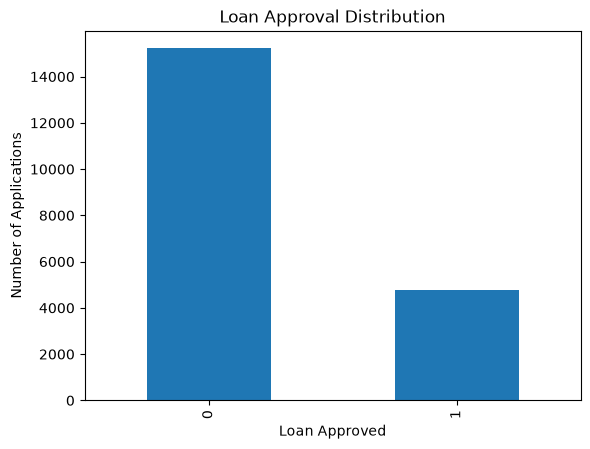

In [144]:
# Plot LoanApproved distribution
df["LoanApproved"].value_counts().sort_index().plot(
    kind="bar",
    title="Loan Approval Distribution",
    xlabel="Loan Approved",
    ylabel="Number of Applications"
)

In [145]:
# Display EmploymentStatus frequencies
print(
    df["EmploymentStatus"].value_counts()
)

EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64


In [146]:
# Calculate EmploymentStatus percentages
print(
    df["EmploymentStatus"]
    .value_counts(normalize=True)
    .mul(100)
)

EmploymentStatus
Employed        85.180
Self-Employed    7.865
Unemployed       6.955
Name: proportion, dtype: float64


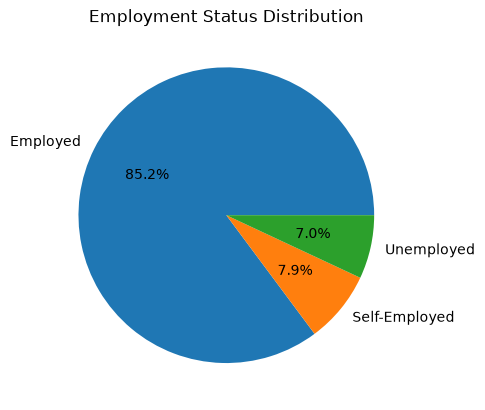

In [147]:
# Plot EmploymentStatus distribution as a pie chart
df["EmploymentStatus"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    title="Employment Status Distribution",
    ylabel=""
)

plt.show()

In [148]:
# Display EducationLevel frequencies
print(
    df["EducationLevel"].value_counts()
)

EducationLevel
Bachelor       6054
High School    5908
Associate      4034
Master         3050
Doctorate       954
Name: count, dtype: int64


In [149]:
# Calculate EducationLevel percentages
print(
    df["EducationLevel"]
    .value_counts(normalize=True)
    .mul(100)
)

EducationLevel
Bachelor      30.270
High School   29.540
Associate     20.170
Master        15.250
Doctorate      4.770
Name: proportion, dtype: float64


In [150]:
# Display MaritalStatus frequencies
print(
    df["MaritalStatus"].value_counts()
)

MaritalStatus
Married     10029
Single       6077
Divorced     2881
Widowed       998
Unknown        15
Name: count, dtype: int64


In [151]:
# Display home ownership frequencies
print(
    df["HomeOwnershipStatus"].value_counts()
)

HomeOwnershipStatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64


In [152]:
# Display loan purpose frequencies
print(
    df["LoanPurpose"].value_counts()
)

LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64


array([[<Axes: title={'center': 'AnnualIncome'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'CreditScore'}>],
       [<Axes: title={'center': 'LoanAmount'}>,
        <Axes: title={'center': 'InterestRate'}>,
        <Axes: title={'center': 'RiskScore'}>],
       [<Axes: title={'center': 'MonthlyIncome'}>,
        <Axes: title={'center': 'MonthlyLoanPayment'}>,
        <Axes: title={'center': 'TotalDebtToIncomeRatio'}>]], dtype=object)

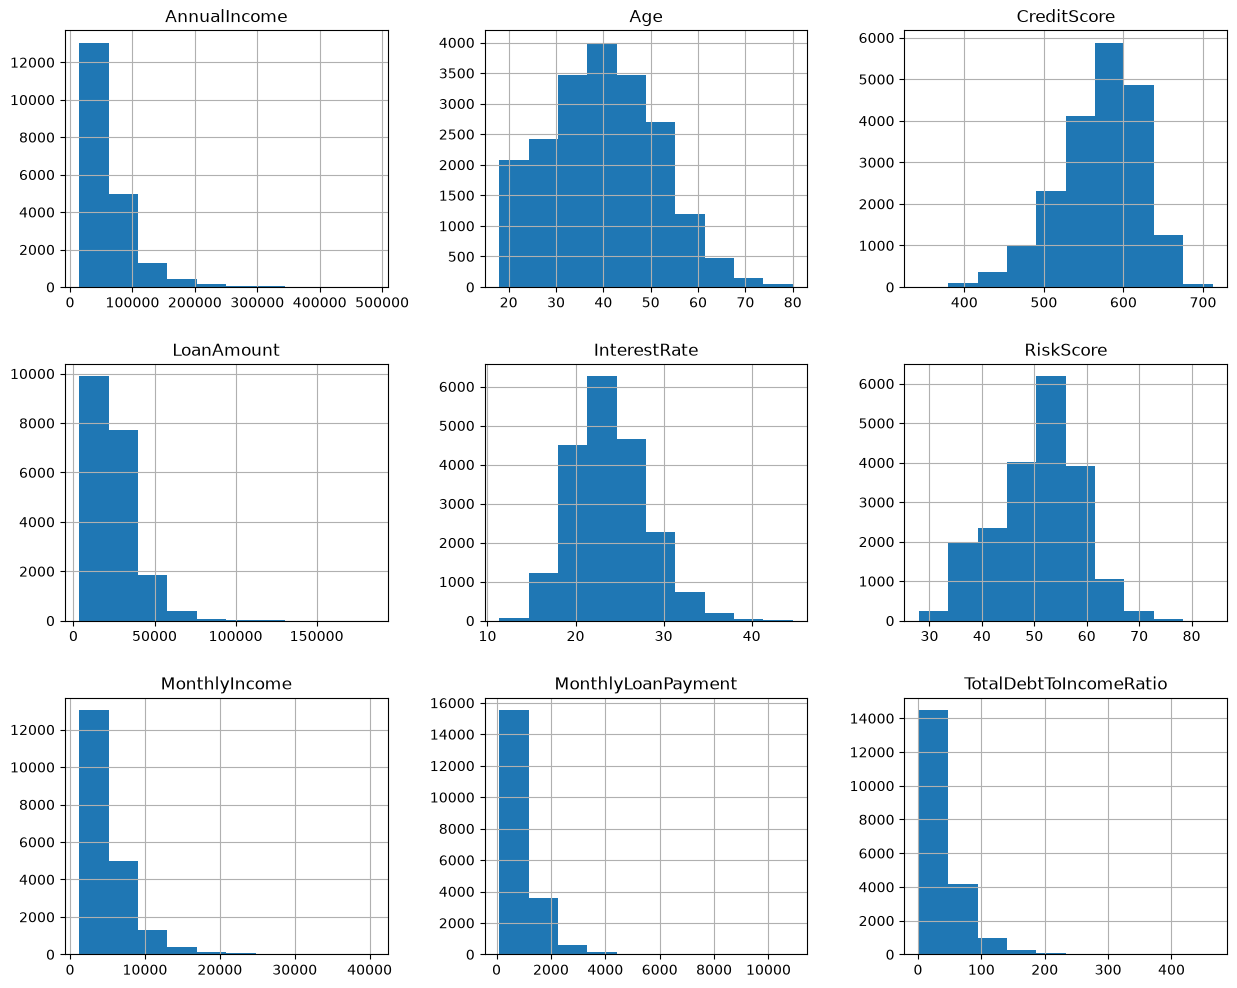

In [153]:
# Display histograms for numerical variables
df[
    [
        "AnnualIncome",
        "Age",
        "CreditScore",
        "LoanAmount",
        "InterestRate",
        "RiskScore",
        "MonthlyIncome",
        "MonthlyLoanPayment",
        "TotalDebtToIncomeRatio"
    ]
].hist(
    figsize=(15, 12)
)

In [154]:
# Compare mean and median for key numerical variables
summary_comparison = pd.DataFrame({
    "Mean": df[
        [
            "AnnualIncome",
            "Age",
            "CreditScore",
            "LoanAmount",
            "InterestRate",
            "RiskScore",
            "MonthlyIncome",
            "MonthlyLoanPayment",
            "TotalDebtToIncomeRatio"
        ]
    ].mean(),
    "Median": df[
        [
            "AnnualIncome",
            "Age",
            "CreditScore",
            "LoanAmount",
            "InterestRate",
            "RiskScore",
            "MonthlyIncome",
            "MonthlyLoanPayment",
            "TotalDebtToIncomeRatio"
        ]
    ].median()
})

print(summary_comparison)

                            Mean    Median
AnnualIncome           59161.474 48566.000
Age                       39.753    40.000
CreditScore              571.612   578.000
LoanAmount             24882.868 21914.500
InterestRate              23.906    23.530
RiskScore                 50.606    51.000
MonthlyIncome           4930.123  4047.167
MonthlyLoanPayment       911.536   728.474
TotalDebtToIncomeRatio    40.047    30.101


In [155]:
# Calculate loan approval rate by employment status
employment_approval = pd.crosstab(
    df["EmploymentStatus"],
    df["LoanApproved"],
    normalize="index"
) * 100

print(employment_approval)

LoanApproved          0      1
EmploymentStatus              
Employed         75.998 24.002
Self-Employed    72.155 27.845
Unemployed       81.812 18.188


<Axes: title={'center': 'Loan Approval by Employment Status'}, xlabel='Employment Status', ylabel='Number of Applications'>

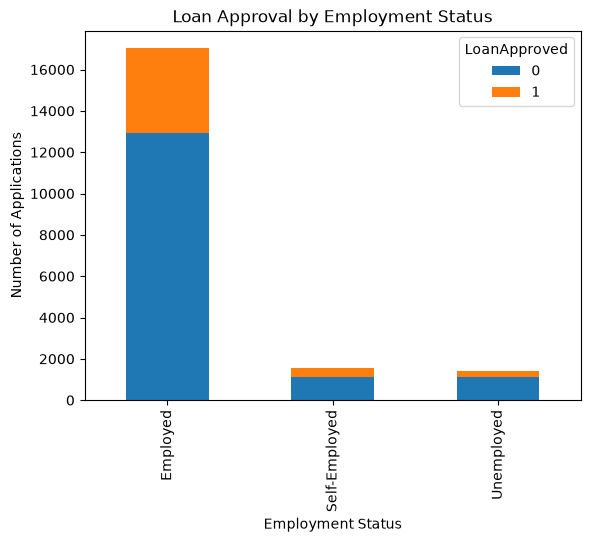

In [156]:
# Plot loan approval by employment status
pd.crosstab(
    df["EmploymentStatus"],
    df["LoanApproved"]
).plot(
    kind="bar",
    stacked=True,
    title="Loan Approval by Employment Status",
    xlabel="Employment Status",
    ylabel="Number of Applications"
)

In [157]:
# Calculate loan approval rate by education level
education_approval = pd.crosstab(
    df["EducationLevel"],
    df["LoanApproved"],
    normalize="index"
) * 100

print(education_approval)

LoanApproved        0      1
EducationLevel              
Associate      79.574 20.426
Bachelor       73.356 26.644
Doctorate      55.975 44.025
High School    85.562 14.438
Master         64.918 35.082


In [158]:
# Calculate loan approval rate by marital status
marital_approval = pd.crosstab(
    df["MaritalStatus"],
    df["LoanApproved"],
    normalize="index"
) * 100

print(marital_approval)

LoanApproved       0      1
MaritalStatus              
Divorced      75.529 24.471
Married       76.129 23.871
Single        76.057 23.943
Unknown       86.667 13.333
Widowed       77.555 22.445


In [159]:
# Calculate loan approval rate by home ownership
home_approval = pd.crosstab(
    df["HomeOwnershipStatus"],
    df["LoanApproved"],
    normalize="index"
) * 100

print(home_approval)

LoanApproved             0      1
HomeOwnershipStatus              
Mortgage            74.846 25.154
Other               79.519 20.481
Own                 75.114 24.886
Rent                77.230 22.770


In [160]:
# Calculate loan approval rate by loan purpose
purpose_approval = pd.crosstab(
    df["LoanPurpose"],
    df["LoanApproved"],
    normalize="index"
) * 100

print(purpose_approval)

LoanApproved            0      1
LoanPurpose                     
Auto               75.731 24.269
Debt Consolidation 76.487 23.513
Education          74.701 25.299
Home               76.203 23.797
Other              77.667 22.333


In [161]:
# Compare CreditScore by loan approval status
print(
    df.groupby("LoanApproved")["CreditScore"].describe()
)

                 count    mean    std     min     25%     50%     75%     max
LoanApproved                                                                 
0            15220.000 567.554 50.918 343.000 536.000 574.000 605.000 703.000
1             4780.000 584.534 49.066 382.000 555.000 591.000 620.000 712.000


Text(0, 0.5, 'Credit Score')

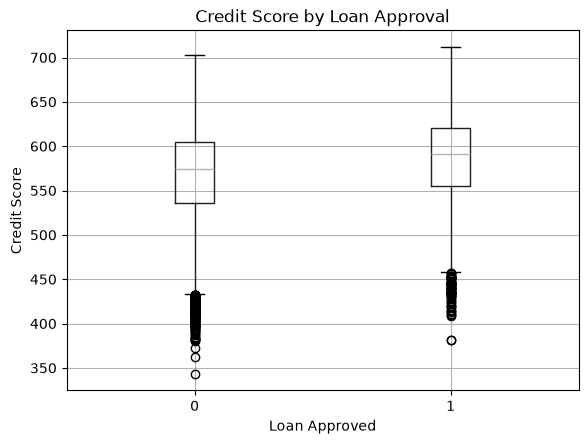

In [162]:
# Plot CreditScore distribution by loan approval
df.boxplot(
    column="CreditScore",
    by="LoanApproved"
)

plt.title("Credit Score by Loan Approval")
plt.suptitle("")
plt.xlabel("Loan Approved")
plt.ylabel("Credit Score")

In [163]:
# Compare annual income by loan approval
print(
    df.groupby("LoanApproved")["AnnualIncome"].describe()
)

                 count       mean       std       min       25%       50%  \
LoanApproved                                                                
0            15220.000  45641.461 24079.007 15000.000 28028.750 40557.500   
1             4780.000 102210.551 50313.413 15787.000 67380.500 91269.500   

                    75%        max  
LoanApproved                        
0             57559.000 228805.000  
1            123959.500 485341.000  


In [164]:
# Compare loan amount by approval status
print(
    df.groupby("LoanApproved")["LoanAmount"].describe()
)

                 count      mean       std      min       25%       50%  \
LoanApproved                                                              
0            15220.000 26684.996 14113.204 4044.000 16949.250 23566.000   
1             4780.000 19144.709  8769.867 3674.000 12774.750 17336.500   

                   75%        max  
LoanApproved                       
0            32987.250 184732.000  
1            23712.250  82644.000  


In [165]:
# Compare risk score by loan approval
print(
    df.groupby("LoanApproved")["RiskScore"].describe()
)

                 count   mean   std    min    25%    50%    75%    max
LoanApproved                                                          
0            15220.000 54.024 5.342 38.000 50.000 54.000 57.000 84.000
1             4780.000 39.725 3.882 28.000 37.000 40.000 42.000 56.000


In [166]:
# Compare debt to income ratio by loan approval
print(
    df.groupby("LoanApproved")[
        "TotalDebtToIncomeRatio"
    ].describe()
)

                 count   mean    std   min    25%    50%    75%     max
LoanApproved                                                           
0            15220.000 47.809 35.065 5.184 24.899 37.937 59.251 464.764
1             4780.000 15.331  8.306 1.604  9.587 13.705 19.109 102.925


Text(0, 0.5, 'Total Debt to Income Ratio')

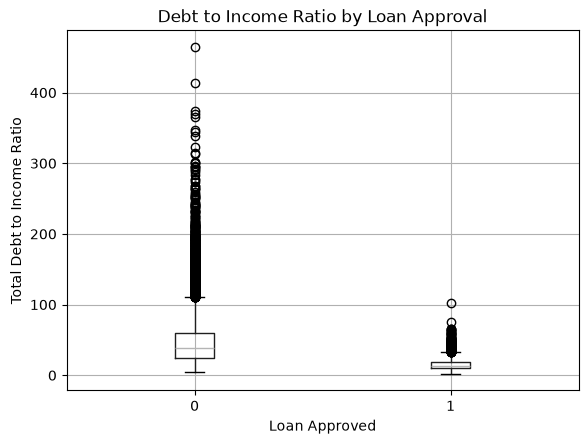

In [167]:
# Plot key financial variables by loan approval
df.boxplot(
    column="TotalDebtToIncomeRatio",
    by="LoanApproved"
)

plt.title("Debt to Income Ratio by Loan Approval")
plt.suptitle("")
plt.xlabel("Loan Approved")
plt.ylabel("Total Debt to Income Ratio")

Text(0, 0.5, 'Annual Income')

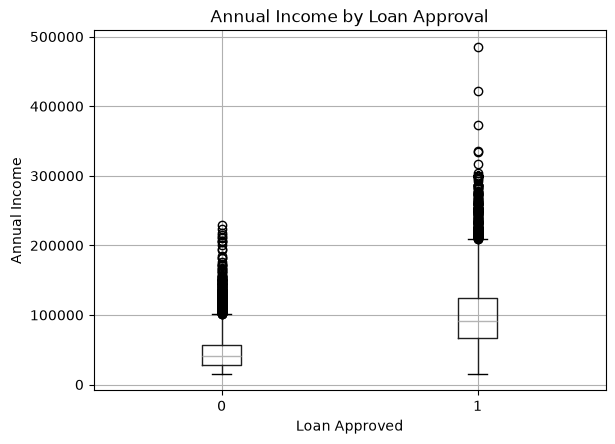

In [168]:
# Plot annual income by loan approval
df.boxplot(
    column="AnnualIncome",
    by="LoanApproved"
)

plt.title("Annual Income by Loan Approval")
plt.suptitle("")
plt.xlabel("Loan Approved")
plt.ylabel("Annual Income")

In [169]:
# Calculate numerical correlation matrix
correlation_matrix = df.select_dtypes(
    include=["int64", "float64"]
).corr()

print(correlation_matrix)

                           AnnualIncome  Experience_df1  LoanDuration  \
AnnualIncome                      1.000           0.146         0.003   
Experience_df1                    0.146           1.000        -0.008   
LoanDuration                      0.003          -0.008         1.000   
NumberOfDependents               -0.001           0.000        -0.001   
MonthlyDebtPayments              -0.001           0.019         0.000   
NumberOfOpenCreditLines          -0.008          -0.002         0.001   
BankruptcyHistory                 0.004           0.010        -0.000   
PreviousLoanDefaults              0.004          -0.002         0.016   
LengthOfCreditHistory            -0.005          -0.001         0.014   
CheckingAccountBalance            0.009           0.009        -0.003   
TotalLiabilities                 -0.002          -0.000         0.004   
NetWorth                         -0.004           0.015        -0.009   
LoanApproved                      0.598           0

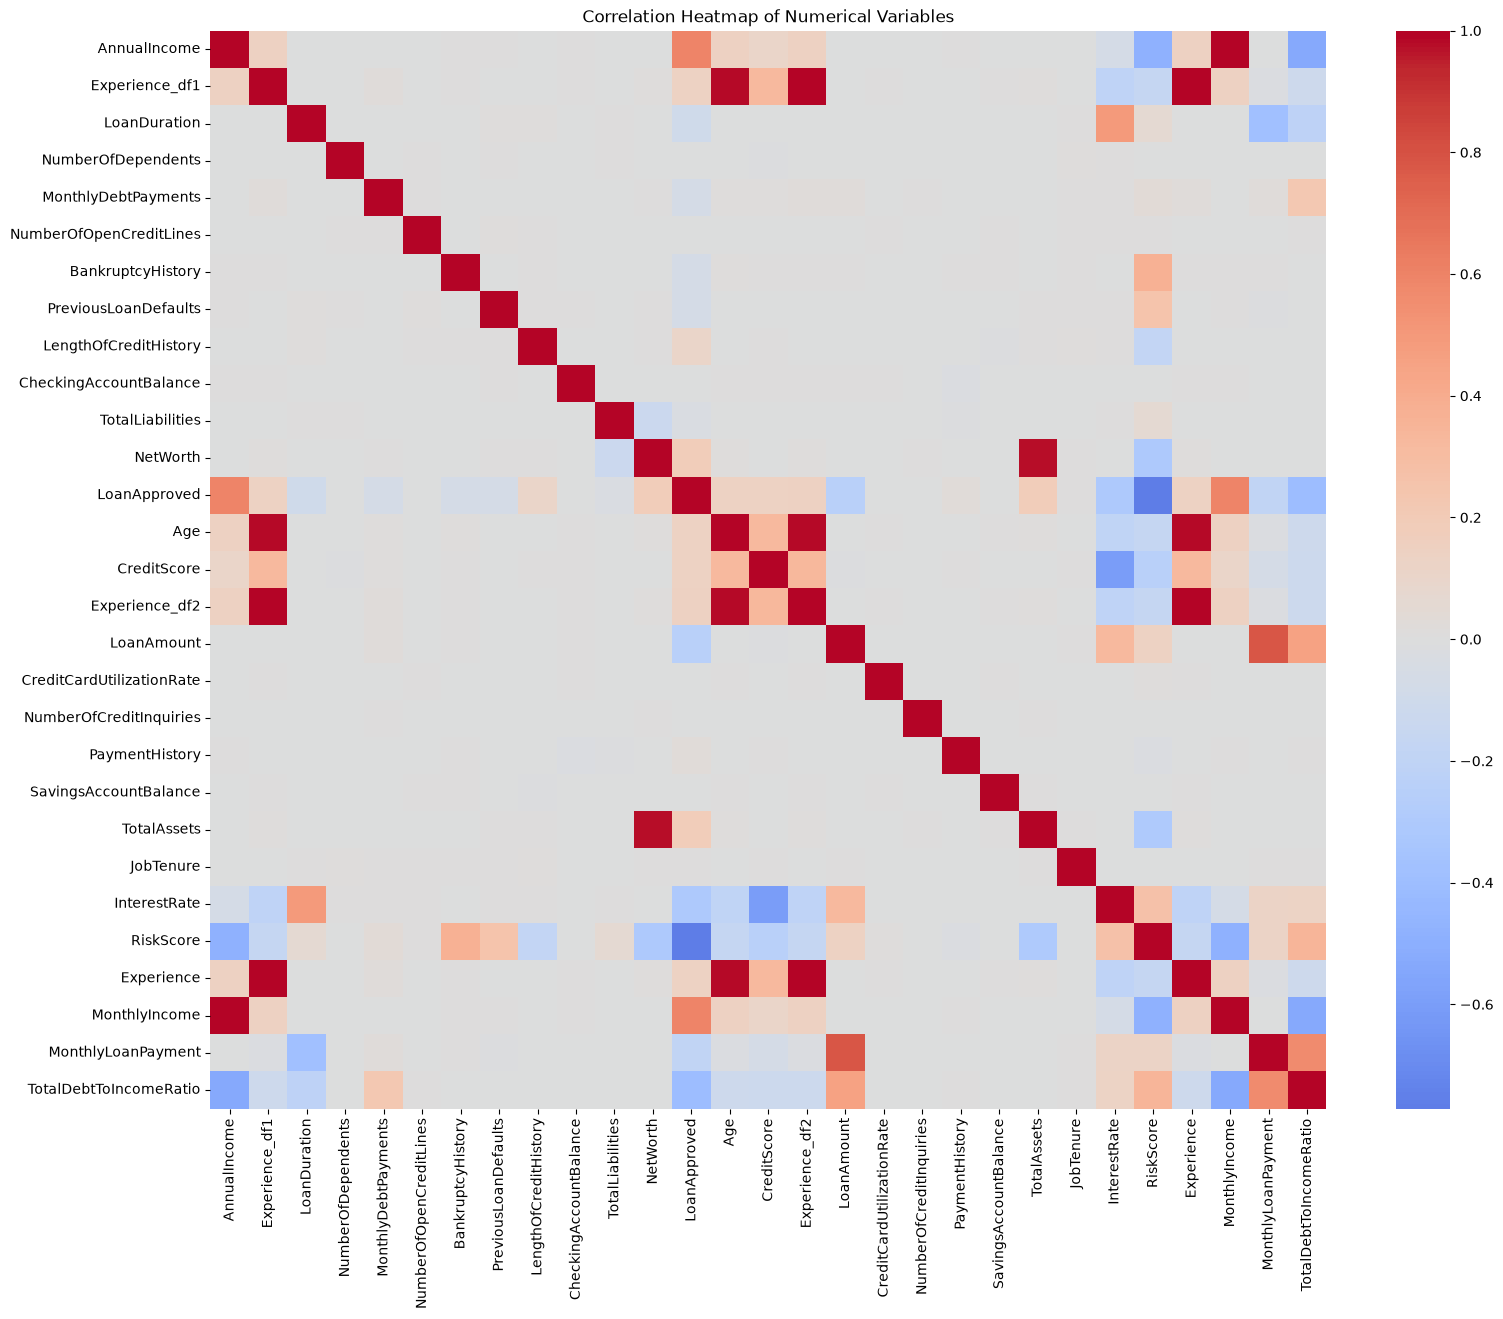

In [170]:
# Plot correlation heatmap
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [171]:
# Calculate correlations with LoanApproved
loan_approval_correlation = (
    correlation_matrix["LoanApproved"]
    .sort_values(ascending=False)
)

print(loan_approval_correlation)

LoanApproved                 1.000
AnnualIncome                 0.598
MonthlyIncome                0.598
NetWorth                     0.188
TotalAssets                  0.184
Experience_df2               0.143
CreditScore                  0.142
Age                          0.141
Experience_df1               0.141
Experience                   0.141
LengthOfCreditHistory        0.106
PaymentHistory               0.031
JobTenure                    0.005
NumberOfDependents           0.002
SavingsAccountBalance        0.001
CheckingAccountBalance       0.001
NumberOfOpenCreditLines     -0.005
NumberOfCreditInquiries     -0.006
CreditCardUtilizationRate   -0.007
TotalLiabilities            -0.029
PreviousLoanDefaults        -0.065
MonthlyDebtPayments         -0.070
BankruptcyHistory           -0.071
LoanDuration                -0.095
MonthlyLoanPayment          -0.184
LoanAmount                  -0.239
InterestRate                -0.302
TotalDebtToIncomeRatio      -0.410
RiskScore           

In [172]:
# Display strongest absolute correlations with LoanApproved
strongest_correlations = (
    loan_approval_correlation
    .drop("LoanApproved")
    .abs()
    .sort_values(ascending=False)
)

print(
    strongest_correlations.head(10)
)

RiskScore                0.771
AnnualIncome             0.598
MonthlyIncome            0.598
TotalDebtToIncomeRatio   0.410
InterestRate             0.302
LoanAmount               0.239
NetWorth                 0.188
MonthlyLoanPayment       0.184
TotalAssets              0.184
Experience_df2           0.143
Name: LoanApproved, dtype: float64


In [173]:
# Display original correlations for the strongest variables
top_variables = strongest_correlations.head(10).index

print(
    loan_approval_correlation.loc[top_variables]
)

RiskScore                -0.771
AnnualIncome              0.598
MonthlyIncome             0.598
TotalDebtToIncomeRatio   -0.410
InterestRate             -0.302
LoanAmount               -0.239
NetWorth                  0.188
MonthlyLoanPayment       -0.184
TotalAssets               0.184
Experience_df2            0.143
Name: LoanApproved, dtype: float64


In [174]:
# Calculate correlation between income and loan amount
print(
    df[
        [
            "AnnualIncome",
            "LoanAmount"
        ]
    ].corr()
)

              AnnualIncome  LoanAmount
AnnualIncome         1.000      -0.004
LoanAmount          -0.004       1.000


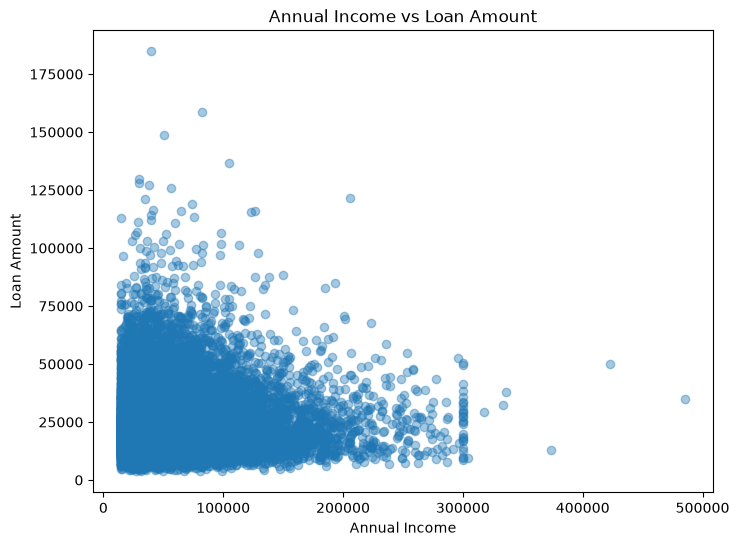

In [175]:
# Plot annual income against loan amount
plt.figure(figsize=(8, 6))

plt.scatter(
    df["AnnualIncome"],
    df["LoanAmount"],
    alpha=0.4
)

plt.title("Annual Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.show()

In [176]:
# Calculate correlation between CreditScore and RiskScore
print(
    df[
        [
            "CreditScore",
            "RiskScore"
        ]
    ].corr()
)

             CreditScore  RiskScore
CreditScore        1.000     -0.239
RiskScore         -0.239      1.000


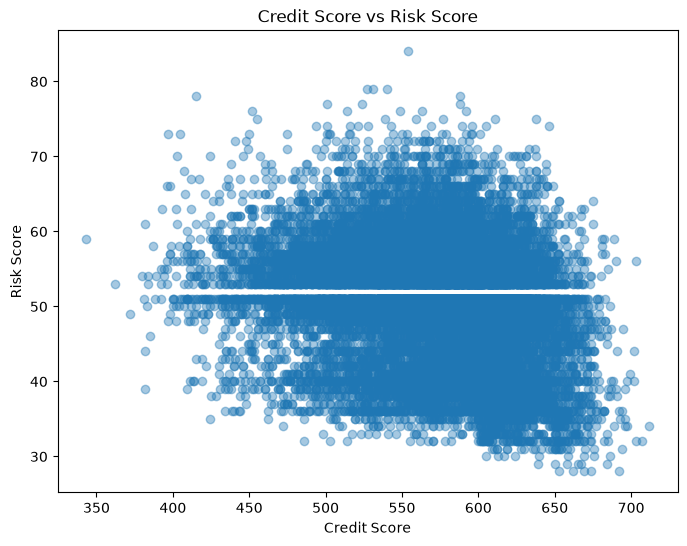

In [177]:
# Plot credit score against risk score
plt.figure(figsize=(8, 6))

plt.scatter(
    df["CreditScore"],
    df["RiskScore"],
    alpha=0.4
)

plt.title("Credit Score vs Risk Score")
plt.xlabel("Credit Score")
plt.ylabel("Risk Score")
plt.show()

In [178]:
# Calculate income and debt ratio by approval status
print(
    df.groupby("LoanApproved")[
        [
            "MonthlyIncome",
            "MonthlyDebtPayments",
            "TotalDebtToIncomeRatio"
        ]
    ].mean()
)

              MonthlyIncome  MonthlyDebtPayments  TotalDebtToIncomeRatio
LoanApproved                                                            
0                  3803.455              463.783                  47.809
1                  8517.546              424.074                  15.331


In [179]:
# Calculate group means for key credit variables
print(
    df.groupby("LoanApproved")[
        [
            "CreditScore",
            "RiskScore",
            "NumberOfCreditInquiries",
            "CreditCardUtilizationRate"
        ]
    ].mean()
)

              CreditScore  RiskScore  NumberOfCreditInquiries  \
LoanApproved                                                    
0                 567.554     54.024                    0.996   
1                 584.534     39.725                    0.983   

              CreditCardUtilizationRate  
LoanApproved                             
0                                38.228  
1                                36.339  


In [180]:
# Create credit score groups
df["CreditScoreGroup"] = pd.cut(
    df["CreditScore"],
    bins=[0, 500, 600, 700, 800, 1000],
    labels=[
        "Below 500",
        "500-599",
        "600-699",
        "700-799",
        "800+"
    ]
)

# Calculate approval rate by credit score group
credit_group_approval = (
    df.groupby(
        "CreditScoreGroup",
        observed=False
    )["LoanApproved"]
    .mean() * 100
)

print(credit_group_approval)

CreditScoreGroup
Below 500   14.951
500-599     21.134
600-699     31.653
700-799     66.667
800+           NaN
Name: LoanApproved, dtype: float64


In [181]:
# Create debt to income ratio groups
df["DTIGroup"] = pd.cut(
    df["TotalDebtToIncomeRatio"],
    bins=[-float("inf"), 20, 40, 60, 80, 100, float("inf")],
    labels=[
        "Below 20%",
        "20-39%",
        "40-59%",
        "60-79%",
        "80-99%",
        "100%+"
    ]
)

# Calculate approval rate by debt to income group
dti_approval = (
    df.groupby(
        "DTIGroup",
        observed=False
    )["LoanApproved"]
    .mean() * 100
)

print(dti_approval)

DTIGroup
Below 20%   62.779
20-39%      14.279
40-59%       1.690
60-79%       0.479
80-99%       0.000
100%+        0.087
Name: LoanApproved, dtype: float64


In [182]:
# Calculate approval counts and rates by loan purpose
loan_purpose_analysis = pd.DataFrame({
    "Applications": df["LoanPurpose"].value_counts(),
    "Approval Rate": (
        df.groupby("LoanPurpose")["LoanApproved"]
        .mean() * 100
    )
})

print(
    loan_purpose_analysis
)

                    Applications  Approval Rate
LoanPurpose                                    
Auto                        4034         24.269
Debt Consolidation          5027         23.513
Education                   3008         25.299
Home                        5925         23.797
Other                       2006         22.333


In [183]:
# Compare numerical means by loan approval
approval_numeric_summary = df.groupby(
    "LoanApproved"
)[
    [
        "AnnualIncome",
        "Age",
        "CreditScore",
        "LoanAmount",
        "InterestRate",
        "RiskScore",
        "MonthlyIncome",
        "MonthlyLoanPayment",
        "TotalDebtToIncomeRatio"
    ]
].mean()

print(approval_numeric_summary)

              AnnualIncome    Age  CreditScore  LoanAmount  InterestRate  \
LoanApproved                                                               
0                45641.461 38.834      567.554   26684.996        24.619   
1               102210.551 42.677      584.534   19144.709        21.634   

              RiskScore  MonthlyIncome  MonthlyLoanPayment  \
LoanApproved                                                 
0                54.024       3803.455             981.191   
1                39.725       8517.546             689.748   

              TotalDebtToIncomeRatio  
LoanApproved                          
0                             47.809  
1                             15.331  


In [184]:
# # Calculate percentage of different application dates
# different_date_percentage = (
#     len(different_dates) /
#     df["ApplicationDate_df1"].notna().sum()
# ) * 100

# print(
#     "Different application dates:",
#     len(different_dates)
# )

# print(
#     "Percentage of different dates:",
#     different_date_percentage
# )

In [185]:
# Extract year from Dataset 1 application date
df["ApplicationYear_df1"] = (
    df["ApplicationDate_df1"].dt.year
)

# Extract year from Dataset 2 application date
df["ApplicationYear_df2"] = (
    df["ApplicationDate_df2"].dt.year
)

# Display application years from Dataset 1
print("Dataset 1 application years:")
print(
    df["ApplicationYear_df1"].value_counts()
    .sort_index()
)

# Display application years from Dataset 2
print("\nDataset 2 application years:")
print(
    df["ApplicationYear_df2"].value_counts()
    .sort_index()
)

Dataset 1 application years:
ApplicationYear_df1
2018.000    1008
2019.000    1008
2020.000    1008
2021.000    1008
2022.000    1008
2023.000    1008
2024.000     975
2025.000     864
Name: count, dtype: int64

Dataset 2 application years:
ApplicationYear_df2
2018.000    144
2019.000    144
2020.000    144
2021.000    144
2022.000    144
2023.000    144
2024.000    144
2025.000    144
2026.000    144
2027.000    144
2028.000    144
2029.000    144
2030.000    144
2031.000    144
2032.000    144
2033.000    144
2034.000    144
2035.000    144
2036.000    144
2037.000    144
2038.000    144
2039.000    144
2040.000    144
2041.000    144
2042.000    144
2043.000    144
2044.000    144
2045.000    144
2046.000    144
2047.000    144
2048.000    144
2049.000    144
2050.000    144
2051.000    144
2052.000    144
2053.000    144
2054.000    144
2055.000    144
2056.000    144
2057.000    144
2058.000    144
2059.000    144
2060.000    144
2061.000    144
2062.000    144
2063.000    144
206

In [186]:
# Calculate approval rates by Dataset 1 application year
approval_by_year_df1 = (
    df.dropna(subset=["ApplicationYear_df1"])
    .groupby("ApplicationYear_df1")["LoanApproved"]
    .agg(
        Applications="count",
        Approved="sum",
        ApprovalRate="mean"
    )
)

approval_by_year_df1["ApprovalRate"] = (
    approval_by_year_df1["ApprovalRate"] * 100
)

print(approval_by_year_df1)

                     Applications  Approved  ApprovalRate
ApplicationYear_df1                                      
2018.000                     1008       259        25.694
2019.000                     1008       219        21.726
2020.000                     1008       259        25.694
2021.000                     1008       240        23.810
2022.000                     1008       245        24.306
2023.000                     1008       243        24.107
2024.000                      975       249        25.538
2025.000                      864       210        24.306


In [187]:
# Calculate approval rates by Dataset 2 application year
approval_by_year_df2 = (
    df.dropna(subset=["ApplicationYear_df2"])
    .groupby("ApplicationYear_df2")["LoanApproved"]
    .agg(
        Applications="count",
        Approved="sum",
        ApprovalRate="mean"
    )
)

approval_by_year_df2["ApprovalRate"] = (
    approval_by_year_df2["ApprovalRate"] * 100
)

print(approval_by_year_df2)

                     Applications  Approved  ApprovalRate
ApplicationYear_df2                                      
2018.000                      144        38        26.389
2019.000                      144        35        24.306
2020.000                      144        35        24.306
2021.000                      144        33        22.917
2022.000                      144        33        22.917
2023.000                      144        31        21.528
2024.000                      144        33        22.917
2025.000                      144        34        23.611
2026.000                      144        43        29.861
2027.000                      144        31        21.528
2028.000                      144        35        24.306
2029.000                      144        37        25.694
2030.000                      144        39        27.083
2031.000                      144        38        26.389
2032.000                      144        39        27.083
2033.000      

In [188]:
# Calculate difference between the two application dates
df["ApplicationDateDifference"] = (
    df["ApplicationDate_df2"] -
    df["ApplicationDate_df1"]
).dt.days

# Display descriptive statistics of date differences
print(
    df["ApplicationDateDifference"].describe()
)

count    7887.000
mean     8569.273
std      5758.453
min         0.000
25%      2922.000
50%      8766.000
75%     14610.000
max     17532.000
Name: ApplicationDateDifference, dtype: float64


In [189]:
# Display the most common date differences
print(
    df["ApplicationDateDifference"]
    .value_counts()
    .head(10)
)

ApplicationDateDifference
0.000        1152
2922.000     1152
5844.000     1152
8766.000     1152
11688.000    1152
14610.000    1152
17532.000     975
Name: count, dtype: int64


In [190]:
# Display minimum and maximum date differences
print(
    "Minimum difference:",
    df["ApplicationDateDifference"].min()
)

print(
    "Maximum difference:",
    df["ApplicationDateDifference"].max()
)

Minimum difference: 0.0
Maximum difference: 17532.0


In [191]:
# Remove temporary date analysis columns
df.drop(
    columns=[
        "ApplicationYear_df1",
        "ApplicationYear_df2",
        "ApplicationDateDifference"
    ],
    inplace=True
)

# **Task 3: Model Building**

### Model 01: Decision Tree Model

*Define the modelling objectives*

In [192]:
# Create a separate copy for classification modelling
classification_df = df.copy()

# Display the shape of the modelling dataset
print("Classification dataset shape:", classification_df.shape)

Classification dataset shape: (20000, 40)


*Target Variable Distribution*

In [193]:
# Check the target variable distribution
print(classification_df["LoanApproved"].value_counts())

# Calculate the target percentage distribution
print(
    classification_df["LoanApproved"]
    .value_counts(normalize=True)
    .mul(100)
)

LoanApproved
0    15220
1     4780
Name: count, dtype: int64
LoanApproved
0   76.100
1   23.900
Name: proportion, dtype: float64


*Pre-process of the Data Set*

In [194]:
# Remove identifier and raw date columns from the predictors
classification_df = classification_df.drop(
    columns=[
        "ID",
        "ApplicationDate_df1",
        "ApplicationDate_df2"
    ],
    errors="ignore"
)

# Display the remaining columns
print(classification_df.columns.tolist())

['AnnualIncome', 'EmploymentStatus', 'Experience_df1', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'LoanApproved', 'Age', 'CreditScore', 'EducationLevel', 'Experience_df2', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience', 'RiskScoreMissing', 'MonthlyIncome', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'CreditScoreGroup', 'DTIGroup']


In [195]:
# Check whether the consolidated Experience matches Dataset 1
print(
    "Experience mismatches:",
    (
        classification_df["Experience"]
        != classification_df["Experience_df1"]
    ).sum()
)

Experience mismatches: 0


In [196]:
# Remove duplicate Experience source columns
classification_df = classification_df.drop(
    columns=[
        "Experience_df1",
        "Experience_df2"
    ],
    errors="ignore"
)

In [197]:
# Check RiskScore data type
print(classification_df["RiskScore"].dtype)

# Check remaining missing RiskScore values
print(
    "Missing RiskScore:",
    classification_df["RiskScore"].isna().sum()
)

float64
Missing RiskScore: 0


In [198]:
# Check remaining missing values
missing_values = (
    classification_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [199]:
# Display the modelling dataset dimensions
print("Rows:", classification_df.shape[0])
print("Columns:", classification_df.shape[1])

Rows: 20000
Columns: 35


In [200]:
# Display the data types of modelling variables
print(classification_df.dtypes)

AnnualIncome                    int64
EmploymentStatus                  str
LoanDuration                    int64
NumberOfDependents              int64
MonthlyDebtPayments             int64
NumberOfOpenCreditLines         int64
BankruptcyHistory               int64
PreviousLoanDefaults            int64
LengthOfCreditHistory           int64
CheckingAccountBalance          int64
TotalLiabilities                int64
NetWorth                        int64
LoanApproved                    int64
Age                             int64
CreditScore                     int64
EducationLevel                    str
LoanAmount                      int64
MaritalStatus                     str
HomeOwnershipStatus               str
CreditCardUtilizationRate     float64
NumberOfCreditInquiries         int64
LoanPurpose                       str
PaymentHistory                  int64
SavingsAccountBalance           int64
TotalAssets                     int64
JobTenure                       int64
InterestRate

*Model Building*

In [201]:
# Define the target variable
y = classification_df["LoanApproved"]

In [202]:
# Remove grouped variables derived from existing numerical variables
classification_df = classification_df.drop(
    columns=[
        "CreditScoreGroup",
        "DTIGroup"
    ],
    errors="ignore"
)

In [203]:
# Define the predictor variables
X = classification_df.drop(
    columns=["LoanApproved"]
)

# Display the predictor columns
print(X.columns.tolist())

['AnnualIncome', 'EmploymentStatus', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'Age', 'CreditScore', 'EducationLevel', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience', 'RiskScoreMissing', 'MonthlyIncome', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']


In [204]:
# Check the number of unique values in each predictor
unique_counts = X.nunique().sort_values()

print(unique_counts)

BankruptcyHistory                2
PreviousLoanDefaults             2
RiskScoreMissing                 2
EmploymentStatus                 3
HomeOwnershipStatus              4
LoanPurpose                      5
MaritalStatus                    5
EducationLevel                   5
NumberOfDependents               6
NumberOfCreditInquiries          8
LoanDuration                    10
NumberOfOpenCreditLines         14
JobTenure                       17
LengthOfCreditHistory           29
PaymentHistory                  38
RiskScore                       52
Experience                      62
Age                             63
CreditScore                    322
MonthlyDebtPayments           1299
CreditCardUtilizationRate     1962
InterestRate                  2170
CheckingAccountBalance        5151
SavingsAccountBalance         9199
LoanAmount                   15578
TotalLiabilities             17163
MonthlyIncome                17516
AnnualIncome                 17516
NetWorth            

In [205]:
# Identify categorical predictor columns
categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'RiskScoreMissing']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10704\1253643258.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [206]:
# Identify numerical predictor columns
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['AnnualIncome', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'Age', 'CreditScore', 'LoanAmount', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience', 'MonthlyIncome', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']


In [207]:
# Confirm the target distribution before model training
print(y.value_counts())
print(y.value_counts(normalize=True).mul(100))

LoanApproved
0    15220
1     4780
Name: count, dtype: int64
LoanApproved
0   76.100
1   23.900
Name: proportion, dtype: float64


In [208]:
# Check correlations among engineered financial variables
print(
    X[
        [
            "AnnualIncome",
            "MonthlyIncome",
            "LoanAmount",
            "MonthlyLoanPayment",
            "MonthlyDebtPayments",
            "TotalDebtToIncomeRatio"
        ]
    ].corr()
)

                        AnnualIncome  MonthlyIncome  LoanAmount  \
AnnualIncome                   1.000          1.000      -0.004   
MonthlyIncome                  1.000          1.000      -0.004   
LoanAmount                    -0.004         -0.004       1.000   
MonthlyLoanPayment            -0.004         -0.004       0.781   
MonthlyDebtPayments           -0.001         -0.001       0.021   
TotalDebtToIncomeRatio        -0.535         -0.535       0.456   

                        MonthlyLoanPayment  MonthlyDebtPayments  \
AnnualIncome                        -0.004               -0.001   
MonthlyIncome                       -0.004               -0.001   
LoanAmount                           0.781                0.021   
MonthlyLoanPayment                   1.000                0.018   
MonthlyDebtPayments                  0.018                1.000   
TotalDebtToIncomeRatio               0.566                0.219   

                        TotalDebtToIncomeRatio  
AnnualIncom

In [209]:
# Check whether MonthlyIncome equals AnnualIncome divided by 12
monthly_income_check = (
    X["AnnualIncome"] / 12
)

print(
    "MonthlyIncome mismatches:",
    (
        abs(
            X["MonthlyIncome"] -
            monthly_income_check
        ) > 0.01
    ).sum()
)

MonthlyIncome mismatches: 0


In [210]:
# Recalculate the TotalDebtToIncomeRatio
calculated_dti = (
    (
        X["MonthlyLoanPayment"] +
        X["MonthlyDebtPayments"]
    ) * 100
    / X["MonthlyIncome"]
)

# Compare the calculated value with the existing DTI
dti_difference = (
    abs(
        X["TotalDebtToIncomeRatio"] -
        calculated_dti
    )
)

print(
    "DTI mismatches:",
    (dti_difference > 0.01).sum()
)

DTI mismatches: 0


In [211]:
# Check for infinite numerical values
print(
    "Infinite values:",
    np.isinf(
        X.select_dtypes(
            include=["int64", "float64"]
        )
    ).sum().sum()
)

Infinite values: 0


In [212]:
# Remove MonthlyIncome because it duplicates AnnualIncome
X = X.drop(
    columns=["MonthlyIncome"]
)

# Display the updated predictor count
print("Number of predictors:", X.shape[1])

Number of predictors: 31


In [213]:
# Identify categorical predictor columns
categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'RiskScoreMissing']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10704\1253643258.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [214]:
# Identify numerical predictor columns
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['AnnualIncome', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'Age', 'CreditScore', 'LoanAmount', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']


In [215]:
# Check for remaining missing values in predictors
print(
    "Total missing values:",
    X.isna().sum().sum()
)

Total missing values: 0


In [216]:
# Display the final number of predictors
print("Number of predictors:", X.shape[1])

# Display the final predictor names
print(X.columns.tolist())

Number of predictors: 31
['AnnualIncome', 'EmploymentStatus', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'Age', 'CreditScore', 'EducationLevel', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience', 'RiskScoreMissing', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']


*Preprocessing the Pipeline*

In [217]:
# Import the train-test splitting function
from sklearn.model_selection import train_test_split

# Split the data using stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [218]:
# Display the training and testing dimensions
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16000, 31)
X_test: (4000, 31)
y_train: (16000,)
y_test: (4000,)


In [219]:
# Check target distribution in the training set
print("Training target distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
)

# Check target distribution in the testing set
print("\nTesting target distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
)

Training target distribution:
LoanApproved
0   76.100
1   23.900
Name: proportion, dtype: float64

Testing target distribution:
LoanApproved
0   76.100
1   23.900
Name: proportion, dtype: float64


In [220]:
# Identify numerical predictor columns
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical predictor columns
categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Display the column groups
print("Numerical columns:", numerical_columns)
print("\nCategorical columns:", categorical_columns)

Numerical columns: ['AnnualIncome', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'Age', 'CreditScore', 'LoanAmount', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']

Categorical columns: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'RiskScoreMissing']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10704\2521232670.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


*Categorical Encoder*

In [221]:
# Import the one-hot encoder
from sklearn.preprocessing import OneHotEncoder

# Create the categorical encoding transformer
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

*Column Transformer*

In [222]:
# Import ColumnTransformer
from sklearn.compose import ColumnTransformer

# Create the preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer,
            categorical_columns
        )
    ],
    remainder="passthrough"
)

*Creation of the Baseline Decision Tree Pipeline*

In [223]:
# Import the Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

# Import Pipeline
from sklearn.pipeline import Pipeline

# Create the baseline Decision Tree
baseline_tree = DecisionTreeClassifier(
    random_state=42
)

# Create the complete modelling pipeline
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", baseline_tree)
    ]
)

In [224]:
# Train the baseline Decision Tree
baseline_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['AnnualIncome','EmploymentStatus','LoanDuration',...,'RiskScoreMissing', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``)

In [225]:
# Generate predictions for the test dataset
y_pred = baseline_pipeline.predict(X_test)

# Generate prediction probabilities
y_pred_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

In [226]:
# Display the first 20 actual and predicted values
print("Actual values:")
print(y_test.iloc[:20].values)

print("\nPredicted values:")
print(y_pred[:20])

print("\nPredicted approval probabilities:")
print(y_pred_proba[:20])

Actual values:
[0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 1]

Predicted values:
[0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 1]

Predicted approval probabilities:
[0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1.]


In [227]:
# Import classification evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

# Display the results
print("Baseline Decision Tree Performance")
print("-----------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Baseline Decision Tree Performance
-----------------------------------
Accuracy : 0.979
Precision: 0.957
Recall   : 0.955
F1 Score : 0.956
ROC-AUC  : 0.9708


In [228]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

# Display the confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3003   41]
 [  43  913]]


In [229]:
# Import classification report
from sklearn.metrics import classification_report

# Display detailed classification metrics
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Approved",
            "Approved"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

Not Approved       0.99      0.99      0.99      3044
    Approved       0.96      0.96      0.96       956

    accuracy                           0.98      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.98      0.98      0.98      4000



*Feature Importance*

In [230]:
# Extract the trained preprocessing component
fitted_preprocessor = baseline_pipeline.named_steps["preprocessor"]

# Extract the trained Decision Tree
fitted_tree = baseline_pipeline.named_steps["classifier"]

# Get the transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get the Decision Tree feature importances
feature_importances = fitted_tree.feature_importances_

In [231]:
# Create a feature importance dataframe
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 20 features
print(feature_importance_df.head(20).to_string(index=False))

                                    Feature  Importance
                       remainder__RiskScore       0.858
          remainder__TotalDebtToIncomeRatio       0.061
                     remainder__CreditScore       0.015
                    remainder__LoanDuration       0.011
                    remainder__InterestRate       0.007
               remainder__BankruptcyHistory       0.005
                      remainder__LoanAmount       0.004
                    remainder__AnnualIncome       0.003
                     remainder__TotalAssets       0.003
                        remainder__NetWorth       0.003
           remainder__LengthOfCreditHistory       0.003
    categorical__EducationLevel_High School       0.002
           remainder__SavingsAccountBalance       0.002
                remainder__TotalLiabilities       0.002
categorical__EmploymentStatus_Self-Employed       0.002
             remainder__MonthlyDebtPayments       0.002
       remainder__CreditCardUtilizationRate     

In [232]:
# Calculate cumulative feature importance
feature_importance_df["CumulativeImportance"] = (
    feature_importance_df["Importance"].cumsum()
)

# Display the top 20 features with cumulative importance
print(
    feature_importance_df.head(20).to_string(index=False)
)

                                    Feature  Importance  CumulativeImportance
                       remainder__RiskScore       0.858                 0.858
          remainder__TotalDebtToIncomeRatio       0.061                 0.919
                     remainder__CreditScore       0.015                 0.934
                    remainder__LoanDuration       0.011                 0.946
                    remainder__InterestRate       0.007                 0.953
               remainder__BankruptcyHistory       0.005                 0.958
                      remainder__LoanAmount       0.004                 0.963
                    remainder__AnnualIncome       0.003                 0.966
                     remainder__TotalAssets       0.003                 0.969
                        remainder__NetWorth       0.003                 0.971
           remainder__LengthOfCreditHistory       0.003                 0.974
    categorical__EducationLevel_High School       0.002         

*Decision Tree without RiskScore*

In [233]:
# Remove RiskScore from the training predictors
X_train_no_risk = X_train.drop(
    columns=["RiskScore"]
)

# Remove RiskScore from the testing predictors
X_test_no_risk = X_test.drop(
    columns=["RiskScore"]
)

# Display the new dimensions
print("X_train_no_risk:", X_train_no_risk.shape)
print("X_test_no_risk:", X_test_no_risk.shape)

X_train_no_risk: (16000, 30)
X_test_no_risk: (4000, 30)


In [234]:
# Identify numerical columns without RiskScore
numerical_columns_no_risk = X_train_no_risk.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical columns without RiskScore
categorical_columns_no_risk = X_train_no_risk.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Display the column groups
print("Numerical columns:")
print(numerical_columns_no_risk)

print("\nCategorical columns:")
print(categorical_columns_no_risk)

Numerical columns:
['AnnualIncome', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'Age', 'CreditScore', 'LoanAmount', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'Experience', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']

Categorical columns:
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'RiskScoreMissing']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10704\724216423.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns_no_risk = X_train_no_risk.select_dtypes(


In [235]:
# Create the categorical encoder without RiskScore
categorical_transformer_no_risk = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [236]:
# Create the preprocessing transformer without RiskScore
preprocessor_no_risk = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer_no_risk,
            categorical_columns_no_risk
        )
    ],
    remainder="passthrough"
)

In [237]:
# Create the Decision Tree without RiskScore
tree_no_risk = DecisionTreeClassifier(
    random_state=42
)

# Create the complete pipeline without RiskScore
pipeline_no_risk = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_risk),
        ("classifier", tree_no_risk)
    ]
)

In [238]:
# Train the Decision Tree without RiskScore
pipeline_no_risk.fit(
    X_train_no_risk,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['AnnualIncome','EmploymentStatus','LoanDuration',...,'RiskScoreMissing', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``)

In [239]:
# Generate predictions without RiskScore
y_pred_no_risk = pipeline_no_risk.predict(
    X_test_no_risk
)

# Generate prediction probabilities without RiskScore
y_pred_proba_no_risk = pipeline_no_risk.predict_proba(
    X_test_no_risk
)[:, 1]

In [240]:
# Calculate performance metrics without RiskScore
accuracy_no_risk = accuracy_score(
    y_test,
    y_pred_no_risk
)

precision_no_risk = precision_score(
    y_test,
    y_pred_no_risk,
    zero_division=0
)

recall_no_risk = recall_score(
    y_test,
    y_pred_no_risk,
    zero_division=0
)

f1_no_risk = f1_score(
    y_test,
    y_pred_no_risk,
    zero_division=0
)

roc_auc_no_risk = roc_auc_score(
    y_test,
    y_pred_proba_no_risk
)

# Display the results
print("Decision Tree Without RiskScore")
print("--------------------------------")
print("Accuracy :", round(accuracy_no_risk, 4))
print("Precision:", round(precision_no_risk, 4))
print("Recall   :", round(recall_no_risk, 4))
print("F1 Score :", round(f1_no_risk, 4))
print("ROC-AUC  :", round(roc_auc_no_risk, 4))

Decision Tree Without RiskScore
--------------------------------
Accuracy : 0.896
Precision: 0.783
Recall   : 0.7814
F1 Score : 0.7822
ROC-AUC  : 0.8567


In [241]:
# Calculate the confusion matrix without RiskScore
cm_no_risk = confusion_matrix(
    y_test,
    y_pred_no_risk
)

# Display the confusion matrix
print("Confusion Matrix:")
print(cm_no_risk)

Confusion Matrix:
[[2837  207]
 [ 209  747]]


In [242]:
# Display the classification report without RiskScore
print(
    classification_report(
        y_test,
        y_pred_no_risk,
        target_names=[
            "Not Approved",
            "Approved"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

Not Approved       0.93      0.93      0.93      3044
    Approved       0.78      0.78      0.78       956

    accuracy                           0.90      4000
   macro avg       0.86      0.86      0.86      4000
weighted avg       0.90      0.90      0.90      4000



In [243]:
# Create a comparison table for both Decision Tree models
dt_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "DT_With_RiskScore": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "DT_Without_RiskScore": [
        accuracy_no_risk,
        precision_no_risk,
        recall_no_risk,
        f1_no_risk,
        roc_auc_no_risk
    ]
})

# Display the comparison
print(
    dt_comparison.to_string(index=False)
)

   Metric  DT_With_RiskScore  DT_Without_RiskScore
 Accuracy              0.979                 0.896
Precision              0.957                 0.783
   Recall              0.955                 0.781
 F1 Score              0.956                 0.782
  ROC-AUC              0.971                 0.857


*Analyzation of RiskScore*

In [244]:
# Calculate loan approval rate for each RiskScore value
risk_score_analysis = df.groupby("RiskScore")["LoanApproved"].agg(
    ["count", "mean"]
)

# Convert the mean into a percentage
risk_score_analysis["ApprovalRate"] = (
    risk_score_analysis["mean"] * 100
)

# Remove the intermediate mean column
risk_score_analysis = risk_score_analysis.drop(
    columns=["mean"]
)

# Display the RiskScore approval analysis
print(
    risk_score_analysis.to_string()
)

           count  ApprovalRate
RiskScore                     
28.000         5       100.000
29.000         6       100.000
30.000         9       100.000
31.000        25       100.000
32.000        93       100.000
33.000        96       100.000
34.000       109       100.000
35.000       185       100.000
36.000       547       100.000
37.000       338       100.000
38.000       382        99.738
39.000       426        99.531
40.000       799        98.999
41.000       376        93.351
42.000       369        90.515
43.000       318        84.906
44.000       473        75.476
45.000       325        42.154
46.000       420        21.429
47.000       527        12.334
48.000       748        10.829
49.000       890         2.809
50.000      1095         1.279
51.000      2546         1.296
53.000      1254         0.478
54.000      1226         0.163
55.000      1160         0.431
56.000       912         0.110
57.000       826         0.000
58.000       719         0.000
59.000  

In [245]:
# Calculate the correlation between RiskScore and LoanApproved
risk_score_correlation = df[
    ["RiskScore", "LoanApproved"]
].corr()

# Display the correlation
print(risk_score_correlation)

              RiskScore  LoanApproved
RiskScore         1.000        -0.771
LoanApproved     -0.771         1.000


In [246]:
# Calculate approval rate based on original RiskScore missingness
risk_missing_analysis = df.groupby(
    "RiskScoreMissing"
)["LoanApproved"].agg(
    ["count", "sum", "mean"]
)

# Convert approval rate into a percentage
risk_missing_analysis["ApprovalRate"] = (
    risk_missing_analysis["mean"] * 100
)

# Remove the intermediate mean column
risk_missing_analysis = risk_missing_analysis.drop(
    columns=["mean"]
)

# Display the result
print(risk_missing_analysis)

                  count   sum  ApprovalRate
RiskScoreMissing                           
False             18725  4764        25.442
True               1275    16         1.255


In [247]:
# Calculate RiskScore statistics for each loan approval class
risk_by_approval = df.groupby(
    "LoanApproved"
)["RiskScore"].agg(
    ["count", "mean", "median", "min", "max"]
)

# Display the statistics
print(risk_by_approval)

              count   mean  median    min    max
LoanApproved                                    
0             15220 54.024  54.000 38.000 84.000
1              4780 39.725  40.000 28.000 56.000


*Hyperparameter Optimisation*

In [248]:
# Define the hyperparameter search space
param_grid_dt = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 5, 10, 15, 20, 25, 30],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10]
}

# Display the hyperparameter combinations
print("Hyperparameter search space:")
for parameter, values in param_grid_dt.items():
    print(parameter, ":", values)

Hyperparameter search space:
classifier__criterion : ['gini', 'entropy', 'log_loss']
classifier__max_depth : [None, 5, 10, 15, 20, 25, 30]
classifier__min_samples_split : [2, 5, 10, 20]
classifier__min_samples_leaf : [1, 2, 5, 10]


In [249]:
# Create stratified five-fold cross-validation

from sklearn.model_selection import StratifiedKFold

cv_dt = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Display the cross-validation configuration
print(cv_dt)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [250]:
# Create the Decision Tree GridSearch

from sklearn.model_selection import GridSearchCV

# Create the Decision Tree GridSearch
dt_grid_search = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid_dt,
    cv=cv_dt,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Confirm the GridSearch object
print("Decision Tree GridSearch created successfully.")

Decision Tree GridSearch created successfully.


In [251]:
# Run Decision Tree hyperparameter optimisation
dt_grid_search.fit(
    X_train,
    y_train
)

# Display the best cross-validation F1-score
print(
    "Best cross-validation F1:",
    round(dt_grid_search.best_score_, 4)
)

Fitting 5 folds for each of 336 candidates, totalling 1680 fits
Best cross-validation F1: 0.9677


In [252]:
# Display the best Decision Tree hyperparameters
print("Best Decision Tree hyperparameters:")
print(dt_grid_search.best_params_)

Best Decision Tree hyperparameters:
{'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5}


In [253]:
# Display the best cross-validation F1-score
print(
    "Best Decision Tree CV F1:",
    round(dt_grid_search.best_score_, 4)
)

Best Decision Tree CV F1: 0.9677


*Final model - Decision Tree*

In [254]:
# Retrieve the best Decision Tree pipeline
dt_final_model = dt_grid_search.best_estimator_

# Display the final Decision Tree model
print(dt_final_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'LoanPurpose',
                                                   'RiskScoreMissing'])])),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', min_samples_leaf=2,
                                        min_samples_split=5,
                                        random_state=42))])


In [255]:
# Generate predictions from the tuned Decision Tree
y_pred_dt_tuned = dt_final_model.predict(
    X_test
)

# Generate approval probabilities from the tuned Decision Tree
y_pred_proba_dt_tuned = dt_final_model.predict_proba(
    X_test
)[:, 1]

In [256]:
# Calculate tuned Decision Tree performance
dt_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_dt_tuned
)

dt_tuned_precision = precision_score(
    y_test,
    y_pred_dt_tuned,
    zero_division=0
)

dt_tuned_recall = recall_score(
    y_test,
    y_pred_dt_tuned,
    zero_division=0
)

dt_tuned_f1 = f1_score(
    y_test,
    y_pred_dt_tuned,
    zero_division=0
)

dt_tuned_roc_auc = roc_auc_score(
    y_test,
    y_pred_proba_dt_tuned
)

# Display tuned Decision Tree performance
print("Tuned Decision Tree Performance")
print("--------------------------------")
print("Accuracy :", round(dt_tuned_accuracy, 4))
print("Precision:", round(dt_tuned_precision, 4))
print("Recall   :", round(dt_tuned_recall, 4))
print("F1 Score :", round(dt_tuned_f1, 4))
print("ROC-AUC  :", round(dt_tuned_roc_auc, 4))

Tuned Decision Tree Performance
--------------------------------
Accuracy : 0.9845
Precision: 0.9715
Recall   : 0.9634
F1 Score : 0.9674
ROC-AUC  : 0.9805


In [257]:
# Calculate the tuned Decision Tree confusion matrix
cm_dt_tuned = confusion_matrix(
    y_test,
    y_pred_dt_tuned
)

# Display the confusion matrix
print("Confusion Matrix:")
print(cm_dt_tuned)

Confusion Matrix:
[[3017   27]
 [  35  921]]


In [258]:
# Display the tuned Decision Tree classification report
print(
    classification_report(
        y_test,
        y_pred_dt_tuned,
        target_names=[
            "Not Approved",
            "Approved"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

Not Approved       0.99      0.99      0.99      3044
    Approved       0.97      0.96      0.97       956

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



In [259]:
# Display the final Decision Tree model
print("Final Decision Tree model:")
print(dt_final_model)

Final Decision Tree model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'LoanPurpose',
                                                   'RiskScoreMissing'])])),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', min_samples_leaf=2,
                                        min_samples_split=5,
                                        ran

In [260]:
# Store the final Decision Tree performance metrics
decision_tree_accuracy = dt_tuned_accuracy
decision_tree_precision = dt_tuned_precision
decision_tree_recall = dt_tuned_recall
decision_tree_f1 = dt_tuned_f1
decision_tree_roc_auc = dt_tuned_roc_auc

# Display the final Decision Tree performance
print("Final Decision Tree Performance")
print("--------------------------------")
print("Accuracy :", round(decision_tree_accuracy, 4))
print("Precision:", round(decision_tree_precision, 4))
print("Recall   :", round(decision_tree_recall, 4))
print("F1 Score :", round(decision_tree_f1, 4))
print("ROC-AUC  :", round(decision_tree_roc_auc, 4))

Final Decision Tree Performance
--------------------------------
Accuracy : 0.9845
Precision: 0.9715
Recall   : 0.9634
F1 Score : 0.9674
ROC-AUC  : 0.9805


In [261]:
# Create a summary of the final Decision Tree
decision_tree_summary = {
    "Model": "Decision Tree",
    "Accuracy": decision_tree_accuracy,
    "Precision": decision_tree_precision,
    "Recall": decision_tree_recall,
    "F1 Score": decision_tree_f1,
    "ROC-AUC": decision_tree_roc_auc
}

# Display the Decision Tree summary
print(decision_tree_summary)

{'Model': 'Decision Tree', 'Accuracy': 0.9845, 'Precision': 0.9715189873417721, 'Recall': 0.9633891213389121, 'F1 Score': 0.967436974789916, 'ROC-AUC': 0.9804590208325316}


In [262]:
# import joblib
# import os

# model_folder = r"D:\LoanApproval\Models"

# # Create the folder if it does not already exist
# os.makedirs(model_folder, exist_ok=True)

# # Save Decision Tree
# joblib.dump(
#     dt_final_model,
#     os.path.join(model_folder, "dt_final_model.pkl")
# )

# print("Models saved successfully.")
# print("Location:", model_folder)

In [263]:
# print(
#     "Decision Tree:",
#     os.path.exists(
#         os.path.join(model_folder, "dt_final_model.pkl")
#     )
# )

### Model 02: Logistic Regression Model

In [264]:
# Logistic Regression imports
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Logistic Regression imports completed successfully.")

Logistic Regression imports completed successfully.


*Identify the features*

In [265]:
# Identify categorical and numerical features for Logistic Regression

categorical_features_lr = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_features_lr = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features_lr)

print("\nNumerical features:")
print(numerical_features_lr)

print("\nNumber of categorical features:", len(categorical_features_lr))
print("Number of numerical features:", len(numerical_features_lr))

Categorical features:
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'RiskScoreMissing']

Numerical features:
['AnnualIncome', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'Age', 'CreditScore', 'LoanAmount', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']

Number of categorical features: 6
Number of numerical features: 25


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10704\1324571942.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_lr = X.select_dtypes(


*Baseline Regression Model*

In [266]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing for Logistic Regression
logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_lr
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features_lr
        )
    ]
)

print("Logistic Regression preprocessor created successfully.")

Logistic Regression preprocessor created successfully.


In [267]:
from sklearn.pipeline import Pipeline

# Create Logistic Regression model
logistic_regression_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Create complete Logistic Regression pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor),
        ("classifier", logistic_regression_model)
    ]
)

print("Logistic Regression pipeline created successfully.")
print("\nPipeline:")
print(logistic_pipeline)

Logistic Regression pipeline created successfully.

Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'LoanPurpose',
                                                   'RiskScoreMissing']),
                                                 ('numerical', StandardScaler(),
                                                  ['AnnualIncome',
                                                   'LoanDuration',
                             

In [268]:
# Train the baseline Logistic Regression model

logistic_pipeline.fit(X_train, y_train)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


In [269]:
# Generate predictions on the test set

y_pred_lr = logistic_pipeline.predict(X_test)

# Generate probability predictions for ROC-AUC
y_pred_proba_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_lr))

Predictions generated successfully.
Number of predictions: 4000


In [270]:
# Evaluate Baseline Logistic Regression

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print("Baseline Logistic Regression Performance")
print("-" * 45)
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")
print(f"ROC-AUC  : {roc_auc_lr:.4f}")

Baseline Logistic Regression Performance
---------------------------------------------
Accuracy : 0.9955
Precision: 0.9926
Recall   : 0.9885
F1 Score : 0.9906
ROC-AUC  : 0.9998


In [271]:
# Confusion Matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

Confusion Matrix:
[[3037    7]
 [  11  945]]


In [272]:
# Classification Report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Not Approved", "Approved"]
))

Classification Report:
              precision    recall  f1-score   support

Not Approved       1.00      1.00      1.00      3044
    Approved       0.99      0.99      0.99       956

    accuracy                           1.00      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       1.00      1.00      1.00      4000



*Examine Logistic Regression Coefficients*

In [273]:
# Extract transformed feature names
feature_names_lr = logistic_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Extract Logistic Regression coefficients
coefficients_lr = logistic_pipeline.named_steps[
    "classifier"
].coef_[0]

# Create a DataFrame of coefficients
lr_coefficients_df = pd.DataFrame({
    "Feature": feature_names_lr,
    "Coefficient": coefficients_lr
})

# Add absolute coefficient for ranking
lr_coefficients_df["Absolute_Coefficient"] = (
    lr_coefficients_df["Coefficient"].abs()
)

# Sort by absolute coefficient
lr_coefficients_df = lr_coefficients_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("Top 20 Logistic Regression Features:")
print(lr_coefficients_df.head(20))

Top 20 Logistic Regression Features:
                                        Feature  Coefficient  \
45                         numerical__RiskScore       -8.015   
48            numerical__TotalDebtToIncomeRatio       -3.826   
44                      numerical__InterestRate       -3.418   
24                      numerical__AnnualIncome        2.759   
36                       numerical__CreditScore       -2.617   
0        categorical__EmploymentStatus_Employed       -1.884   
6       categorical__EducationLevel_High School       -1.532   
37                        numerical__LoanAmount       -1.434   
29                 numerical__BankruptcyHistory        1.403   
23           categorical__RiskScoreMissing_True       -1.276   
1   categorical__EmploymentStatus_Self-Employed        1.002   
30              numerical__PreviousLoanDefaults        0.898   
5         categorical__EducationLevel_Doctorate        0.863   
14       categorical__HomeOwnershipStatus_Other       -0.811   
3  

In [274]:
# Check correlations between numerical predictors and LoanApproved
# using X, which contains the exact features used by Logistic Regression

correlation_data_lr = X[numerical_features_lr].copy()

# Add target variable
correlation_data_lr["LoanApproved"] = y.reset_index(drop=True)

# Calculate correlations
correlation_with_target = (
    correlation_data_lr
    .corr()["LoanApproved"]
    .drop("LoanApproved")
    .sort_values(key=abs, ascending=False)
)

print("Numerical feature correlations with LoanApproved:")
print(correlation_with_target)

Numerical feature correlations with LoanApproved:
RiskScore                   -0.771
AnnualIncome                 0.598
TotalDebtToIncomeRatio      -0.410
InterestRate                -0.302
LoanAmount                  -0.239
NetWorth                     0.188
MonthlyLoanPayment          -0.184
TotalAssets                  0.184
CreditScore                  0.142
Age                          0.141
Experience                   0.141
LengthOfCreditHistory        0.106
LoanDuration                -0.095
BankruptcyHistory           -0.071
MonthlyDebtPayments         -0.070
PreviousLoanDefaults        -0.065
PaymentHistory               0.031
TotalLiabilities            -0.029
CreditCardUtilizationRate   -0.007
NumberOfCreditInquiries     -0.006
JobTenure                    0.005
NumberOfOpenCreditLines     -0.005
NumberOfDependents           0.002
SavingsAccountBalance        0.001
CheckingAccountBalance       0.001
Name: LoanApproved, dtype: float64


In [275]:
# Compare RiskScore between Loan Approved and Not Approved groups

risk_score_by_target = (
    pd.DataFrame({
        "RiskScore": X["RiskScore"],
        "LoanApproved": y
    })
    .groupby("LoanApproved")["RiskScore"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

print("RiskScore statistics by LoanApproved:")
print(risk_score_by_target)

RiskScore statistics by LoanApproved:
              count   mean  median   std    min    max
LoanApproved                                          
0             15220 54.024  54.000 5.342 38.000 84.000
1              4780 39.725  40.000 3.882 28.000 56.000


*Logistic Regression Without RiskScore*

In [276]:
# Create a copy of the predictors without RiskScore

X_no_risk_lr = X.drop(columns=["RiskScore"]).copy()

print("Original number of predictors:", X.shape[1])
print("Predictors without RiskScore:", X_no_risk_lr.shape[1])

Original number of predictors: 31
Predictors without RiskScore: 30


In [277]:
# Create matching train/test datasets without RiskScore

X_train_no_risk_lr = X_train.drop(columns=["RiskScore"]).copy()
X_test_no_risk_lr = X_test.drop(columns=["RiskScore"]).copy()

print("X_train_no_risk_lr shape:", X_train_no_risk_lr.shape)
print("X_test_no_risk_lr shape:", X_test_no_risk_lr.shape)

X_train_no_risk_lr shape: (16000, 30)
X_test_no_risk_lr shape: (4000, 30)


In [278]:
# Identify categorical and numerical features without RiskScore

categorical_features_no_risk_lr = X_train_no_risk_lr.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_features_no_risk_lr = X_train_no_risk_lr.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features without RiskScore:")
print(categorical_features_no_risk_lr)

print("\nNumber of categorical features:",
      len(categorical_features_no_risk_lr))

print("\nNumber of numerical features without RiskScore:",
      len(numerical_features_no_risk_lr))

Categorical features without RiskScore:
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'RiskScoreMissing']

Number of categorical features: 6

Number of numerical features without RiskScore: 24


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10704\2059115153.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_no_risk_lr = X_train_no_risk_lr.select_dtypes(


In [279]:
# Preprocessing for Logistic Regression without RiskScore

logistic_preprocessor_no_risk = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_no_risk_lr
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features_no_risk_lr
        )
    ]
)

print("Logistic Regression preprocessor without RiskScore created successfully.")

Logistic Regression preprocessor without RiskScore created successfully.


In [280]:
# Create Logistic Regression model without RiskScore

logistic_regression_no_risk_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Create pipeline without RiskScore
logistic_pipeline_no_risk = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor_no_risk),
        ("classifier", logistic_regression_no_risk_model)
    ]
)

print("Logistic Regression pipeline without RiskScore created successfully.")
print("\nPipeline:")
print(logistic_pipeline_no_risk)

Logistic Regression pipeline without RiskScore created successfully.

Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'LoanPurpose',
                                                   'RiskScoreMissing']),
                                                 ('numerical', StandardScaler(),
                                                  ['AnnualIncome',
                                                   'LoanDuration',
           

In [281]:
# Train Logistic Regression without RiskScore

logistic_pipeline_no_risk.fit(
    X_train_no_risk_lr,
    y_train
)

print("Logistic Regression without RiskScore trained successfully.")

Logistic Regression without RiskScore trained successfully.


In [282]:
# Generate predictions

y_pred_lr_no_risk = logistic_pipeline_no_risk.predict(
    X_test_no_risk_lr
)

y_pred_proba_lr_no_risk = logistic_pipeline_no_risk.predict_proba(
    X_test_no_risk_lr
)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_lr_no_risk))

Predictions generated successfully.
Number of predictions: 4000


In [283]:
# Evaluate Logistic Regression without RiskScore

accuracy_lr_no_risk = accuracy_score(
    y_test, y_pred_lr_no_risk
)

precision_lr_no_risk = precision_score(
    y_test, y_pred_lr_no_risk
)

recall_lr_no_risk = recall_score(
    y_test, y_pred_lr_no_risk
)

f1_lr_no_risk = f1_score(
    y_test, y_pred_lr_no_risk
)

roc_auc_lr_no_risk = roc_auc_score(
    y_test, y_pred_proba_lr_no_risk
)

print("Logistic Regression Without RiskScore Performance")
print("-" * 55)
print(f"Accuracy : {accuracy_lr_no_risk:.4f}")
print(f"Precision: {precision_lr_no_risk:.4f}")
print(f"Recall   : {recall_lr_no_risk:.4f}")
print(f"F1 Score : {f1_lr_no_risk:.4f}")
print(f"ROC-AUC  : {roc_auc_lr_no_risk:.4f}")

Logistic Regression Without RiskScore Performance
-------------------------------------------------------
Accuracy : 0.9653
Precision: 0.9323
Recall   : 0.9215
F1 Score : 0.9269
ROC-AUC  : 0.9946


In [284]:
# Confusion Matrix

cm_lr_no_risk = confusion_matrix(
    y_test,
    y_pred_lr_no_risk
)

print("Confusion Matrix:")
print(cm_lr_no_risk)

Confusion Matrix:
[[2980   64]
 [  75  881]]


In [285]:
# Classification Report

print("Classification Report with no risk score:")
print(
    classification_report(
        y_test,
        y_pred_lr_no_risk,
        target_names=["Not Approved", "Approved"]
    )
)

Classification Report with no risk score:
              precision    recall  f1-score   support

Not Approved       0.98      0.98      0.98      3044
    Approved       0.93      0.92      0.93       956

    accuracy                           0.97      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.97      0.97      0.97      4000



*Hyperparameter Optimization*

In [286]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for Logistic Regression
logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["lbfgs", "liblinear"],
    "classifier__class_weight": [None, "balanced"]
}

print("Logistic Regression hyperparameter grid:")
print(logistic_param_grid)

Logistic Regression hyperparameter grid:
{'classifier__C': [0.01, 0.1, 1, 10, 100], 'classifier__solver': ['lbfgs', 'liblinear'], 'classifier__class_weight': [None, 'balanced']}


In [287]:
# Logistic Regression hyperparameter optimization

logistic_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Run GridSearchCV
logistic_grid_search.fit(X_train, y_train)

print("\nLogistic Regression hyperparameter tuning completed.")
print("Best CV F1 Score:", logistic_grid_search.best_score_)
print("Best Parameters:", logistic_grid_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Logistic Regression hyperparameter tuning completed.
Best CV F1 Score: 0.9911046659419152
Best Parameters: {'classifier__C': 1, 'classifier__class_weight': None, 'classifier__solver': 'liblinear'}


*Final Logistic Regression Model*

In [288]:
# Create the final Logistic Regression model using the best parameters

logistic_final_model = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor),
        (
            "classifier",
            LogisticRegression(
                C=1,
                solver="liblinear",
                class_weight=None,
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

print("Final Logistic Regression model created.")
print("\nBest parameters:")
print(logistic_grid_search.best_params_)

Final Logistic Regression model created.

Best parameters:
{'classifier__C': 1, 'classifier__class_weight': None, 'classifier__solver': 'liblinear'}


In [289]:
# Train the final Logistic Regression model

logistic_final_model.fit(X_train, y_train)

print("Final Logistic Regression model trained successfully.")

Final Logistic Regression model trained successfully.


In [290]:
# Generate final test predictions

y_pred_lr_final = logistic_final_model.predict(X_test)

y_pred_proba_lr_final = logistic_final_model.predict_proba(
    X_test
)[:, 1]

print("Final Logistic Regression predictions generated.")
print("Number of predictions:", len(y_pred_lr_final))

Final Logistic Regression predictions generated.
Number of predictions: 4000


*Final Logistic Regression Coefficient Analysis*

In [291]:
# Extract feature names from the final Logistic Regression pipeline

final_lr_feature_names = logistic_final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Extract coefficients from the trained Logistic Regression model

final_lr_coefficients = logistic_final_model.named_steps[
    "classifier"
].coef_[0]

# Create coefficient DataFrame

final_lr_coefficients_df = pd.DataFrame({
    "Feature": final_lr_feature_names,
    "Coefficient": final_lr_coefficients
})

# Calculate absolute coefficient for ranking

final_lr_coefficients_df["Absolute_Coefficient"] = (
    final_lr_coefficients_df["Coefficient"].abs()
)

# Sort from strongest to weakest

final_lr_coefficients_df = final_lr_coefficients_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("Top 20 Final Logistic Regression Features:")
print(final_lr_coefficients_df.head(20).to_string(index=False))

Top 20 Final Logistic Regression Features:
                                 Feature  Coefficient  Absolute_Coefficient
                    numerical__RiskScore       -8.073                 8.073
                 numerical__InterestRate       -3.305                 3.305
       numerical__TotalDebtToIncomeRatio       -2.905                 2.905
                 numerical__AnnualIncome        2.887                 2.887
                  numerical__CreditScore       -2.583                 2.583
  categorical__EmploymentStatus_Employed       -2.433                 2.433
 categorical__EducationLevel_High School       -1.782                 1.782
      categorical__RiskScoreMissing_True       -1.603                 1.603
            numerical__BankruptcyHistory        1.465                 1.465
                   numerical__LoanAmount       -1.349                 1.349
     categorical__RiskScoreMissing_False       -1.235                 1.235
  categorical__HomeOwnershipStatus_Other     

In [292]:
# Top positive coefficients

positive_lr_features = (
    final_lr_coefficients_df[
        final_lr_coefficients_df["Coefficient"] > 0
    ]
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

print("Top 10 Positive Logistic Regression Coefficients:")
print(positive_lr_features.to_string(index=False))

Top 10 Positive Logistic Regression Coefficients:
                                    Feature  Coefficient  Absolute_Coefficient
                    numerical__AnnualIncome        2.887                 2.887
               numerical__BankruptcyHistory        1.465                 1.465
            numerical__PreviousLoanDefaults        0.923                 0.923
categorical__EmploymentStatus_Self-Employed        0.617                 0.617
      categorical__EducationLevel_Doctorate        0.616                 0.616
                      numerical__Experience        0.327                 0.327
                  numerical__PaymentHistory        0.309                 0.309
           numerical__LengthOfCreditHistory        0.290                 0.290
         categorical__MaritalStatus_Unknown        0.255                 0.255
                        numerical__NetWorth        0.240                 0.240


In [293]:
# Top negative coefficients

negative_lr_features = (
    final_lr_coefficients_df[
        final_lr_coefficients_df["Coefficient"] < 0
    ]
    .sort_values("Coefficient", ascending=True)
    .head(10)
)

print("Top 10 Negative Logistic Regression Coefficients:")
print(negative_lr_features.to_string(index=False))

Top 10 Negative Logistic Regression Coefficients:
                                Feature  Coefficient  Absolute_Coefficient
                   numerical__RiskScore       -8.073                 8.073
                numerical__InterestRate       -3.305                 3.305
      numerical__TotalDebtToIncomeRatio       -2.905                 2.905
                 numerical__CreditScore       -2.583                 2.583
 categorical__EmploymentStatus_Employed       -2.433                 2.433
categorical__EducationLevel_High School       -1.782                 1.782
     categorical__RiskScoreMissing_True       -1.603                 1.603
                  numerical__LoanAmount       -1.349                 1.349
    categorical__RiskScoreMissing_False       -1.235                 1.235
 categorical__HomeOwnershipStatus_Other       -1.190                 1.190


In [294]:
# Final Logistic Regression evaluation

final_lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr_final
)

final_lr_precision = precision_score(
    y_test,
    y_pred_lr_final
)

final_lr_recall = recall_score(
    y_test,
    y_pred_lr_final
)

final_lr_f1 = f1_score(
    y_test,
    y_pred_lr_final
)

final_lr_roc_auc = roc_auc_score(
    y_test,
    y_pred_proba_lr_final
)

print("Final Logistic Regression Performance")
print("-" * 50)
print(f"Accuracy : {final_lr_accuracy:.4f}")
print(f"Precision: {final_lr_precision:.4f}")
print(f"Recall   : {final_lr_recall:.4f}")
print(f"F1 Score : {final_lr_f1:.4f}")
print(f"ROC-AUC  : {final_lr_roc_auc:.4f}")

Final Logistic Regression Performance
--------------------------------------------------
Accuracy : 0.9955
Precision: 0.9916
Recall   : 0.9895
F1 Score : 0.9906
ROC-AUC  : 0.9999


In [295]:
# Final Logistic Regression Confusion Matrix

final_lr_cm = confusion_matrix(
    y_test,
    y_pred_lr_final
)

print("Final Logistic Regression Confusion Matrix:")
print(final_lr_cm)

Final Logistic Regression Confusion Matrix:
[[3036    8]
 [  10  946]]


In [296]:
# Final Logistic Regression Classification Report

print("Final Logistic Regression Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr_final,
        target_names=["Not Approved", "Approved"]
    )
)

Final Logistic Regression Classification Report:
              precision    recall  f1-score   support

Not Approved       1.00      1.00      1.00      3044
    Approved       0.99      0.99      0.99       956

    accuracy                           1.00      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       1.00      1.00      1.00      4000



In [309]:
# import joblib
# import os

# model_folder = r"D:\LoanApproval\Models"

# # Create the folder if it does not already exist
# os.makedirs(model_folder, exist_ok=True)

# # Save Logistic Regression
# joblib.dump(
#     logistic_final_model,
#     os.path.join(model_folder, "logistic_final_model.pkl")
# )

# print("Models saved successfully.")
# print("Location:", model_folder)

Models saved successfully.
Location: D:\LoanApproval\Models


In [310]:
# print(
#     "Logistic Regression:",
#     os.path.exists(
#         os.path.join(model_folder, "logistic_final_model.pkl")
#     )
# )

Logistic Regression: True


### Model 03: Random Forest Regression Model

In [ ]:
# Define the regression target
regression_target = "LoanAmount"

# Define columns that should not be used as predictors
columns_to_exclude_rf = [
    "LoanAmount",
    "MonthlyLoanPayment",
    "LoanApproved",
    "ID",
    "ApplicationDate_df1",
    "ApplicationDate_df2",
    "Experience_df1",
    "Experience_df2"
]

# Create the regression feature dataset
X_rf = df.drop(
    columns=columns_to_exclude_rf
)

# Create the regression target
y_rf = df[regression_target]

# Display the regression dataset dimensions
print("Random Forest Regression Dataset")
print("---------------------------------")
print("Number of predictors:", X_rf.shape[1])
print("Number of observations:", X_rf.shape[0])
print("Regression target:", regression_target)

Random Forest Regression Dataset
---------------------------------
Number of predictors: 32
Number of observations: 20000
Regression target: LoanAmount


In [ ]:
# Display the current dataset columns
print("Current df columns:")
print(df.columns.tolist())

# Display the current dataset dimensions
print("\nCurrent dataset shape:")
print(df.shape)

Current df columns:
['ID', 'ApplicationDate_df1', 'AnnualIncome', 'EmploymentStatus', 'Experience_df1', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'LoanApproved', 'ApplicationDate_df2', 'Age', 'CreditScore', 'EducationLevel', 'Experience_df2', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience', 'RiskScoreMissing', 'MonthlyIncome', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'CreditScoreGroup', 'DTIGroup']

Current dataset shape:
(20000, 40)


In [ ]:
# Display columns related to feature engineering
print("Potential feature-engineered columns:")
print([
    column for column in df.columns
    if any(keyword in column.lower() for keyword in [
        "monthlyincome",
        "monthlyloan",
        "debttoincome",
        "group"
    ])
])

Potential feature-engineered columns:
['MonthlyIncome', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'CreditScoreGroup', 'DTIGroup']


In [ ]:
# Display descriptive statistics for the regression target
print("LoanAmount Statistical Summary")
print("------------------------------")
print(y_rf.describe())

LoanAmount Statistical Summary
------------------------------
count    20000.000
mean     24882.868
std      13427.421
min       3674.000
25%      15575.000
50%      21914.500
75%      30835.000
max     184732.000
Name: LoanAmount, dtype: float64


In [ ]:
# Check missing values in the Random Forest regression predictors
rf_missing_values = X_rf.isnull().sum()

# Display columns containing missing values
print("Missing values in Random Forest predictors:")
print(rf_missing_values[rf_missing_values > 0])

# Check missing values in the regression target
print("\nMissing values in regression target:")
print(y_rf.isnull().sum())

Missing values in Random Forest predictors:
Series([], dtype: int64)

Missing values in regression target:
0


In [ ]:
# Identify categorical predictors
rf_categorical_columns = X_rf.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Identify numerical predictors
rf_numerical_columns = X_rf.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Display the predictor groups
print("Categorical predictors:")
print(rf_categorical_columns)

print("\nNumber of categorical predictors:")
print(len(rf_categorical_columns))

print("\nNumerical predictors:")
print(rf_numerical_columns)

print("\nNumber of numerical predictors:")
print(len(rf_numerical_columns))

Categorical predictors:
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'RiskScoreMissing', 'CreditScoreGroup', 'DTIGroup']

Number of categorical predictors:
8

Numerical predictors:
['AnnualIncome', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'Age', 'CreditScore', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience', 'MonthlyIncome', 'TotalDebtToIncomeRatio']

Number of numerical predictors:
24


In [ ]:
# Split the regression data into training and testing sets
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_rf,
    y_rf,
    test_size=0.20,
    random_state=42
)

# Display the regression train/test dimensions
print("Random Forest Regression Train/Test Split")
print("-------------------------------------------")
print("X_rf_train:", X_rf_train.shape)
print("X_rf_test :", X_rf_test.shape)
print("y_rf_train:", y_rf_train.shape)
print("y_rf_test :", y_rf_test.shape)

Random Forest Regression Train/Test Split
-------------------------------------------
X_rf_train: (16000, 32)
X_rf_test : (4000, 32)
y_rf_train: (16000,)
y_rf_test : (4000,)


In [ ]:
# Create the categorical preprocessing pipeline
rf_categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Create the Random Forest Regression preprocessor
rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            rf_categorical_transformer,
            rf_categorical_columns
        )
    ],
    remainder="passthrough"
)

# Display the Random Forest Regression preprocessor
print("Random Forest Regression preprocessor created successfully.")
print(rf_preprocessor)

Random Forest Regression preprocessor created successfully.
ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['EmploymentStatus', 'EducationLevel',
                                  'MaritalStatus', 'HomeOwnershipStatus',
                                  'LoanPurpose', 'RiskScoreMissing',
                                  'CreditScoreGroup', 'DTIGroup'])])


In [ ]:
# Create the Random Forest regression model

from sklearn.ensemble import RandomForestRegressor

random_forest_regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Create the Random Forest Regression pipeline
rf_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("regressor", random_forest_regressor)
    ]
)

# Display the Random Forest Regression pipeline
print("Random Forest Regression pipeline created successfully.")
print(rf_regression_pipeline)

Random Forest Regression pipeline created successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'LoanPurpose',
                                                   'RiskScoreMissing',
                                                   'CreditScoreGroup',
                                                   'DTIGroup'])])),
                ('regressor',
                 Random

In [ ]:
# Train the baseline Random Forest Regression model
rf_regression_pipeline.fit(
    X_rf_train,
    y_rf_train
)

# Confirm that training was completed
print("Baseline Random Forest Regression training completed successfully.")

Baseline Random Forest Regression training completed successfully.


In [ ]:
# Generate Random Forest Regression predictions
y_rf_pred = rf_regression_pipeline.predict(
    X_rf_test
)

# Display the number of predictions
print("Number of predictions:", len(y_rf_pred))

# Display the first five predictions
print("\nFirst five predicted LoanAmount values:")
print(y_rf_pred[:5])

Number of predictions: 4000

First five predicted LoanAmount values:
[23162.535 15934.285 35236.11  28667.13  33235.9  ]


In [ ]:
# Import regression evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate regression performance metrics
rf_mae = mean_absolute_error(
    y_rf_test,
    y_rf_pred
)

rf_mse = mean_squared_error(
    y_rf_test,
    y_rf_pred
)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(
    y_rf_test,
    y_rf_pred
)

# Display Random Forest Regression performance
print("Baseline Random Forest Regression Performance")
print("-----------------------------------------------")
print("MAE :", round(rf_mae, 2))
print("MSE :", round(rf_mse, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Baseline Random Forest Regression Performance
-----------------------------------------------
MAE : 2393.35
MSE : 13577693.08
RMSE: 3684.79
R²  : 0.9194


In [ ]:
# Generate predictions for the training data
y_rf_train_pred = rf_regression_pipeline.predict(
    X_rf_train
)

# Calculate training regression metrics
rf_train_mae = mean_absolute_error(
    y_rf_train,
    y_rf_train_pred
)

rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_rf_train,
        y_rf_train_pred
    )
)

rf_train_r2 = r2_score(
    y_rf_train,
    y_rf_train_pred
)

# Display training and testing performance
print("Random Forest Regression Overfitting Check")
print("--------------------------------------------")

print("\nTraining Performance")
print("MAE :", round(rf_train_mae, 2))
print("RMSE:", round(rf_train_rmse, 2))
print("R²  :", round(rf_train_r2, 4))

print("\nTesting Performance")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest Regression Overfitting Check
--------------------------------------------

Training Performance
MAE : 906.87
RMSE: 1491.57
R²  : 0.9879

Testing Performance
MAE : 2393.35
RMSE: 3684.79
R²  : 0.9194


In [ ]:
# Calculate the R² generalisation gap
rf_r2_gap = rf_train_r2 - rf_r2

# Display the R² generalisation gap
print("Random Forest R² Generalisation Gap")
print("------------------------------------")
print("Training R²:", round(rf_train_r2, 4))
print("Testing R² :", round(rf_r2, 4))
print("R² Gap     :", round(rf_r2_gap, 4))

Random Forest R² Generalisation Gap
------------------------------------
Training R²: 0.9879
Testing R² : 0.9194
R² Gap     : 0.0684


In [ ]:
# Extract the fitted Random Forest regressor
rf_regressor_fitted = rf_regression_pipeline.named_steps["regressor"]

# Extract the fitted preprocessing step
rf_fitted_preprocessor = rf_regression_pipeline.named_steps["preprocessor"]

# Get the transformed feature names
rf_feature_names = rf_fitted_preprocessor.get_feature_names_out()

# Get Random Forest feature importances
rf_feature_importances = rf_regressor_fitted.feature_importances_

# Create the feature importance dataframe
rf_feature_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_feature_importances
})

# Sort features by importance
rf_feature_importance_df = rf_feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display the top 20 features
print("Top 20 Random Forest Regression Features")
print("-----------------------------------------")
print(rf_feature_importance_df.head(20).to_string(index=False))

Top 20 Random Forest Regression Features
-----------------------------------------
                             Feature  Importance
   remainder__TotalDebtToIncomeRatio       0.379
            remainder__MonthlyIncome       0.144
             remainder__AnnualIncome       0.143
      remainder__MonthlyDebtPayments       0.099
             remainder__LoanDuration       0.089
             remainder__InterestRate       0.065
              remainder__CreditScore       0.016
remainder__CreditCardUtilizationRate       0.005
    remainder__SavingsAccountBalance       0.005
         remainder__TotalLiabilities       0.004
   remainder__CheckingAccountBalance       0.004
                 remainder__NetWorth       0.004
              remainder__TotalAssets       0.004
    remainder__LengthOfCreditHistory       0.004
           remainder__PaymentHistory       0.004
                remainder__RiskScore       0.003
                      remainder__Age       0.003
               remainder__Experienc

In [ ]:
# Calculate cumulative feature importance
rf_feature_importance_df["CumulativeImportance"] = (
    rf_feature_importance_df["Importance"].cumsum()
)

# Display the top 20 features with cumulative importance
print("Random Forest Regression Cumulative Feature Importance")
print("-------------------------------------------------------")
print(
    rf_feature_importance_df.head(20).to_string(index=False)
)

Random Forest Regression Cumulative Feature Importance
-------------------------------------------------------
                             Feature  Importance  CumulativeImportance
   remainder__TotalDebtToIncomeRatio       0.379                 0.379
            remainder__MonthlyIncome       0.144                 0.523
             remainder__AnnualIncome       0.143                 0.667
      remainder__MonthlyDebtPayments       0.099                 0.765
             remainder__LoanDuration       0.089                 0.855
             remainder__InterestRate       0.065                 0.920
              remainder__CreditScore       0.016                 0.935
remainder__CreditCardUtilizationRate       0.005                 0.940
    remainder__SavingsAccountBalance       0.005                 0.945
         remainder__TotalLiabilities       0.004                 0.950
   remainder__CheckingAccountBalance       0.004                 0.954
                 remainder__NetWorth 

In [ ]:
# Find the number of features needed to reach selected importance levels
importance_90 = (
    rf_feature_importance_df["CumulativeImportance"] >= 0.90
).idxmax() + 1

importance_95 = (
    rf_feature_importance_df["CumulativeImportance"] >= 0.95
).idxmax() + 1

importance_99 = (
    rf_feature_importance_df["CumulativeImportance"] >= 0.99
).idxmax() + 1

# Display the cumulative importance thresholds
print("Features required to reach cumulative importance:")
print("90%:", importance_90)
print("95%:", importance_95)
print("99%:", importance_99)

Features required to reach cumulative importance:
90%: 6
95%: 11
99%: 26


In [ ]:
# Import GridSearchCV for Random Forest regression optimisation
from sklearn.model_selection import GridSearchCV

# Define the Random Forest regression parameter grid
param_grid_rf = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__max_depth": [None, 10, 20],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2],
    "regressor__max_features": ["sqrt", 1.0]
}

# Display the number of parameter combinations
parameter_combinations_rf = 1

for parameter in param_grid_rf.values():
    parameter_combinations_rf *= len(parameter)

print("Random Forest Regression Hyperparameter Grid")
print("----------------------------------------------")
print("Parameter combinations:", parameter_combinations_rf)

Random Forest Regression Hyperparameter Grid
----------------------------------------------
Parameter combinations: 72


In [ ]:
# # Create the Random Forest regression grid search
# rf_regression_grid_search = GridSearchCV(
#     estimator=rf_regression_pipeline,
#     param_grid=param_grid_rf,
#     cv=5,
#     scoring="neg_root_mean_squared_error",
#     n_jobs=2,
#     verbose=1
# )

# # Run the Random Forest regression hyperparameter optimisation
# rf_regression_grid_search.fit(
#     X_rf_train,
#     y_rf_train
# )

# # Display the best cross-validation RMSE
# print("Best Random Forest Regression CV RMSE:")
# print(round(-rf_regression_grid_search.best_score_, 2))

# # Display the best hyperparameters
# print("\nBest Random Forest Regression hyperparameters:")
# print(rf_regression_grid_search.best_params_)

In [ ]:
# Create a Colab-safe Random Forest regressor
random_forest_regressor_safe = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=1
)

# Create the Colab-safe Random Forest regression pipeline
rf_regression_pipeline_safe = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("regressor", random_forest_regressor_safe)
    ]
)

# Display the pipeline
print("Colab-safe Random Forest Regression pipeline created successfully.")
print(rf_regression_pipeline_safe)

Colab-safe Random Forest Regression pipeline created successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'LoanPurpose',
                                                   'RiskScoreMissing',
                                                   'CreditScoreGroup',
                                                   'DTIGroup'])])),
                ('regressor',
            

In [ ]:
# Create a representative sample for initial hyperparameter optimisation
X_rf_tuning, _, y_rf_tuning, _ = train_test_split(
    X_rf_train,
    y_rf_train,
    train_size=8000,
    random_state=42
)

# Display the tuning sample dimensions
print("Random Forest Regression Tuning Sample")
print("---------------------------------------")
print("X_rf_tuning:", X_rf_tuning.shape)
print("y_rf_tuning:", y_rf_tuning.shape)

Random Forest Regression Tuning Sample
---------------------------------------
X_rf_tuning: (8000, 32)
y_rf_tuning: (8000,)


In [ ]:
# Define a memory-efficient Random Forest tuning grid
param_grid_rf_tuning = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [None, 20],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2],
    "regressor__max_features": ["sqrt", 1.0]
}

# Calculate the number of parameter combinations
parameter_combinations_rf_tuning = 1

for parameter in param_grid_rf_tuning.values():
    parameter_combinations_rf_tuning *= len(parameter)

print("Random Forest tuning parameter combinations:")
print(parameter_combinations_rf_tuning)

Random Forest tuning parameter combinations:
32


In [ ]:
# Create the initial Random Forest regression grid search
rf_regression_grid_search = GridSearchCV(
    estimator=rf_regression_pipeline_safe,
    param_grid=param_grid_rf_tuning,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    verbose=1
)

# Run the initial hyperparameter optimisation
rf_regression_grid_search.fit(
    X_rf_tuning,
    y_rf_tuning
)

# Display the best cross-validation RMSE
print("Best Random Forest Regression CV RMSE:")
print(round(-rf_regression_grid_search.best_score_, 2))

# Display the best hyperparameters
print("\nBest Random Forest Regression hyperparameters:")
print(rf_regression_grid_search.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Random Forest Regression CV RMSE:
5424.79

Best Random Forest Regression hyperparameters:
{'regressor__max_depth': None, 'regressor__max_features': 1.0, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}


In [ ]:
# Define a smaller focused Random Forest regression parameter grid
param_grid_rf_focused = {
    "regressor__n_estimators": [200],
    "regressor__max_depth": [None, 15, 20],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2],
    "regressor__max_features": [1.0]
}

# Calculate the number of parameter combinations
parameter_combinations_rf_focused = 1

for parameter in param_grid_rf_focused.values():
    parameter_combinations_rf_focused *= len(parameter)

print("Focused Random Forest Regression Search")
print("----------------------------------------")
print("Parameter combinations:", parameter_combinations_rf_focused)
print("Total CV fits:", parameter_combinations_rf_focused * 3)

Focused Random Forest Regression Search
----------------------------------------
Parameter combinations: 12
Total CV fits: 36


In [ ]:
# Create the focused Random Forest regression grid search
rf_regression_grid_search = GridSearchCV(
    estimator=rf_regression_pipeline_safe,
    param_grid=param_grid_rf_focused,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    verbose=1
)

# Run the focused search on all training observations
rf_regression_grid_search.fit(
    X_rf_train,
    y_rf_train
)

# Display the best cross-validation RMSE
print("Best Full-Training CV RMSE:")
print(round(-rf_regression_grid_search.best_score_, 2))

# Display the best hyperparameters
print("\nBest Random Forest Regression hyperparameters:")
print(rf_regression_grid_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [ ]:
# Create the final Random Forest regression model
rf_final_regressor = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=1
)

# Create the final Random Forest regression pipeline
rf_final_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("regressor", rf_final_regressor)
    ]
)

# Display the final Random Forest regression pipeline
print("Final Random Forest Regression pipeline created successfully.")
print(rf_final_pipeline)

In [ ]:
# Train the final Random Forest regression model
rf_final_pipeline.fit(
    X_rf_train,
    y_rf_train
)

# Confirm successful training
print("Final Random Forest Regression model training completed successfully.")

In [ ]:
# Generate predictions for the untouched test dataset
y_pred_rf_final = rf_final_pipeline.predict(
    X_rf_test
)

# Display the number of predictions
print("Number of final predictions:", len(y_pred_rf_final))

# Display the first five predictions
print("\nFirst five predicted LoanAmount values:")
print(np.round(y_pred_rf_final[:5], 2))

In [ ]:
# Calculate final Random Forest regression performance metrics
rf_final_mae = mean_absolute_error(
    y_rf_test,
    y_pred_rf_final
)

rf_final_mse = mean_squared_error(
    y_rf_test,
    y_pred_rf_final
)

rf_final_rmse = np.sqrt(
    rf_final_mse
)

rf_final_r2 = r2_score(
    y_rf_test,
    y_pred_rf_final
)

# Display final Random Forest regression performance
print("Final Random Forest Regression Performance")
print("--------------------------------------------")
print("MAE :", round(rf_final_mae, 2))
print("MSE :", round(rf_final_mse, 2))
print("RMSE:", round(rf_final_rmse, 2))
print("R²  :", round(rf_final_r2, 4))

In [ ]:
# Compare baseline and final Random Forest regression performance
rf_regression_comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Baseline Random Forest": [
        2393.35,
        3684.79,
        0.9194
    ],
    "Final Random Forest": [
        rf_final_mae,
        rf_final_rmse,
        rf_final_r2
    ]
})

# Display the Random Forest regression comparison
print(rf_regression_comparison)

In [ ]:
# Generate predictions for the training dataset
y_pred_rf_final_train = rf_final_pipeline.predict(
    X_rf_train
)

# Calculate final training performance
rf_final_train_mae = mean_absolute_error(
    y_rf_train,
    y_pred_rf_final_train
)

rf_final_train_rmse = np.sqrt(
    mean_squared_error(
        y_rf_train,
        y_pred_rf_final_train
    )
)

rf_final_train_r2 = r2_score(
    y_rf_train,
    y_pred_rf_final_train
)

# Calculate the final Random Forest R² generalisation gap
rf_final_r2_gap = (
    rf_final_train_r2 -
    rf_final_r2
)

# Display the final overfitting check
print("Final Random Forest Regression Overfitting Check")
print("------------------------------------------------")
print("\nTraining Performance")
print("MAE :", round(rf_final_train_mae, 2))
print("RMSE:", round(rf_final_train_rmse, 2))
print("R²  :", round(rf_final_train_r2, 4))

print("\nTesting Performance")
print("MAE :", round(rf_final_mae, 2))
print("RMSE:", round(rf_final_rmse, 2))
print("R²  :", round(rf_final_r2, 4))

print("\nRandom Forest R² Generalisation Gap")
print("------------------------------------")
print("Training R²:", round(rf_final_train_r2, 4))
print("Testing R² :", round(rf_final_r2, 4))
print("R² Gap     :", round(rf_final_r2_gap, 4))

In [ ]:
# Store the selected final Random Forest Regression model
rf_selected_model = rf_regression_pipeline

print("Final Random Forest Regression model selected.")
print("---------------------------------------------")
print("Selected model: Baseline Random Forest Regression")
print("Target variable: LoanAmount")
print("Test RMSE: 3684.79")
print("Test R²: 0.9194")

In [ ]:
# Verify the selected Random Forest model
print("Selected Random Forest Regression Model")
print("---------------------------------------")
print(rf_selected_model)

### Model 04: K-Means Clustering Model

In [ ]:
# ============================================================
# Prepare Dataset for K-Means Clustering
# ============================================================

# Create a copy of the current dataset
kmeans_data = df.copy()

# Remove target variables and non-predictive identifier/date columns
kmeans_excluded_columns = [
    'ID',
    'ApplicationDate_df1',
    'ApplicationDate_df2',
    'LoanApproved',
    'LoanAmount'
]

# Create the clustering dataset
kmeans_data = kmeans_data.drop(
    columns=kmeans_excluded_columns,
    errors='ignore'
)

print("K-Means Dataset")
print("----------------")
print("Rows:", kmeans_data.shape[0])
print("Columns:", kmeans_data.shape[1])

print("\nColumns used for clustering:")
print(kmeans_data.columns.tolist())

In [ ]:
# ============================================================
# Check Redundancy Among K-Means Numerical Variables
# ============================================================

# Identify numerical variables in the K-Means dataset
kmeans_numerical_columns = kmeans_data.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Number of numerical K-Means variables:", len(kmeans_numerical_columns))
print("\nNumerical variables:")
print(kmeans_numerical_columns)

# Calculate correlation matrix
kmeans_correlation_matrix = kmeans_data[
    kmeans_numerical_columns
].corr()

# Display selected potentially redundant relationships
kmeans_redundancy_check = kmeans_correlation_matrix.loc[
    [
        'AnnualIncome',
        'Experience',
        'Experience_df1',
        'Experience_df2',
        'MonthlyIncome',
        'CreditScore',
        'RiskScore',
        'TotalDebtToIncomeRatio'
    ],
    [
        'AnnualIncome',
        'Experience',
        'Experience_df1',
        'Experience_df2',
        'MonthlyIncome',
        'CreditScore',
        'RiskScore',
        'TotalDebtToIncomeRatio'
    ]
]

print("\nPotentially Redundant Variable Correlations")
print("---------------------------------------------")
print(kmeans_redundancy_check.round(3))

In [ ]:
# ============================================================
# Remove Confirmed Duplicate Variables
# ============================================================

# Variables confirmed to contain duplicate information
kmeans_duplicate_columns = [
    'Experience_df1',
    'Experience_df2',
    'MonthlyIncome'
]

# Remove the duplicate variables
kmeans_refined_data = kmeans_data.drop(
    columns=kmeans_duplicate_columns,
    errors='ignore'
)

print("Refined K-Means Dataset")
print("-----------------------")
print("Rows:", kmeans_refined_data.shape[0])
print("Columns:", kmeans_refined_data.shape[1])

print("\nRemoved variables:")
print(kmeans_duplicate_columns)

print("\nRemaining variables:")
print(kmeans_refined_data.columns.tolist())

In [ ]:
# ============================================================
# Identify K-Means Numerical and Categorical Variables
# ============================================================

# Identify categorical variables
kmeans_categorical_columns = kmeans_refined_data.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

# Identify numerical variables
kmeans_numerical_columns = kmeans_refined_data.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("K-Means Categorical Variables")
print("-----------------------------")
print(kmeans_categorical_columns)
print("Number of categorical variables:", len(kmeans_categorical_columns))

print("\nK-Means Numerical Variables")
print("---------------------------")
print(kmeans_numerical_columns)
print("Number of numerical variables:", len(kmeans_numerical_columns))

print("\nTotal variables:", len(kmeans_categorical_columns) + len(kmeans_numerical_columns))

In [ ]:
# ============================================================
# Create K-Means Preprocessing Pipeline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Create the numerical preprocessing
kmeans_numerical_transformer = StandardScaler()

# Create the categorical preprocessing
kmeans_categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Create the complete K-Means preprocessing pipeline
kmeans_preprocessor = ColumnTransformer(
    transformers=[
        (
            'numerical',
            kmeans_numerical_transformer,
            kmeans_numerical_columns
        ),
        (
            'categorical',
            kmeans_categorical_transformer,
            kmeans_categorical_columns
        )
    ],
    remainder='drop'
)

print("K-Means preprocessing pipeline created successfully.")
print("-----------------------------------------------")
print(kmeans_preprocessor)

In [ ]:
# ============================================================
# Transform Data for K-Means
# ============================================================

# Apply the preprocessing pipeline
kmeans_processed_data = kmeans_preprocessor.fit_transform(
    kmeans_refined_data
)

print("K-Means Processed Dataset")
print("-------------------------")
print("Rows:", kmeans_processed_data.shape[0])
print("Columns:", kmeans_processed_data.shape[1])
print("Data type:", kmeans_processed_data.dtype)

# Check for missing or infinite values
print("\nMissing values:", np.isnan(kmeans_processed_data).sum())
print("Infinite values:", np.isinf(kmeans_processed_data).sum())

In [ ]:
# ============================================================
# Inspect Transformed K-Means Features
# ============================================================

kmeans_feature_names = kmeans_preprocessor.get_feature_names_out()

print("Number of transformed features:", len(kmeans_feature_names))

print("\nFirst 20 transformed features:")
for feature in kmeans_feature_names[:20]:
    print(feature)

print("\nLast 20 transformed features:")
for feature in kmeans_feature_names[-20:]:
    print(feature)

In [ ]:
# ============================================================
# Determine the Optimal Number of K-Means Clusters
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Range of cluster numbers to evaluate
kmeans_k_values = range(2, 11)

# Lists to store evaluation results
kmeans_inertia_values = []
kmeans_silhouette_scores = []

print("Evaluating K-Means cluster numbers...")
print("--------------------------------------")

for k in kmeans_k_values:

    # Create K-Means model
    kmeans_temp_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit the model
    kmeans_temp_labels = kmeans_temp_model.fit_predict(
        kmeans_processed_data
    )

    # Store inertia
    kmeans_inertia_values.append(
        kmeans_temp_model.inertia_
    )

    # Calculate silhouette score
    kmeans_silhouette_scores.append(
        silhouette_score(
            kmeans_processed_data,
            kmeans_temp_labels
        )
    )

    print(
        f"K = {k:2d} | "
        f"Inertia = {kmeans_temp_model.inertia_:,.2f} | "
        f"Silhouette Score = {kmeans_silhouette_scores[-1]:.4f}"
    )

In [ ]:
# ============================================================
# Verify K-Means Numerical Scaling
# ============================================================

# Extract the processed numerical portion
kmeans_scaled_numerical = kmeans_processed_data[
    :, :len(kmeans_numerical_columns)
]

# Calculate mean and standard deviation
kmeans_scaled_means = np.mean(
    kmeans_scaled_numerical,
    axis=0
)

kmeans_scaled_stds = np.std(
    kmeans_scaled_numerical,
    axis=0
)

print("K-Means Scaling Verification")
print("-----------------------------")

print(
    "Maximum absolute mean:",
    round(np.max(np.abs(kmeans_scaled_means)), 6)
)

print(
    "Minimum standard deviation:",
    round(np.min(kmeans_scaled_stds), 6)
)

print(
    "Maximum standard deviation:",
    round(np.max(kmeans_scaled_stds), 6)
)

In [ ]:
# ============================================================
# PCA Diagnostic for K-Means
# ============================================================

from sklearn.decomposition import PCA

# Fit PCA without fixing the number of components
kmeans_pca_diagnostic = PCA(
    random_state=42
)

# Transform the scaled and encoded K-Means data
kmeans_pca_data = kmeans_pca_diagnostic.fit_transform(
    kmeans_processed_data
)

# Calculate cumulative explained variance
kmeans_pca_cumulative_variance = np.cumsum(
    kmeans_pca_diagnostic.explained_variance_ratio_
)

# Find number of components needed for selected variance levels
kmeans_pca_components_90 = np.argmax(
    kmeans_pca_cumulative_variance >= 0.90
) + 1

kmeans_pca_components_95 = np.argmax(
    kmeans_pca_cumulative_variance >= 0.95
) + 1

print("PCA Diagnostic Results")
print("----------------------")
print("Original features:", kmeans_processed_data.shape[1])
print("PCA components:", kmeans_pca_data.shape[1])

print(
    "\nComponents required for 90% variance:",
    kmeans_pca_components_90
)

print(
    "Components required for 95% variance:",
    kmeans_pca_components_95
)

print(
    "\nVariance explained by first 2 components:",
    round(
        kmeans_pca_diagnostic.explained_variance_ratio_[:2].sum(),
        4
    )
)

print(
    "Variance explained by first 3 components:",
    round(
        kmeans_pca_diagnostic.explained_variance_ratio_[:3].sum(),
        4
    )
)

print(
    "Variance explained by first 10 components:",
    round(
        kmeans_pca_cumulative_variance[9],
        4
    )
)

In [ ]:
# ============================================================
# PCA-Based K-Means Diagnostic
# ============================================================

# Create PCA retaining approximately 90% of the variance
kmeans_pca_90 = PCA(
    n_components=0.90,
    random_state=42
)

# Transform the processed K-Means data
kmeans_pca_90_data = kmeans_pca_90.fit_transform(
    kmeans_processed_data
)

print("PCA-Based K-Means Dataset")
print("-------------------------")
print("Original features:", kmeans_processed_data.shape[1])
print("PCA features:", kmeans_pca_90_data.shape[1])
print(
    "Explained variance:",
    round(kmeans_pca_90.explained_variance_ratio_.sum(), 4)
)

# Evaluate K = 2 to 10
kmeans_pca_k_values = range(2, 11)

kmeans_pca_inertia_values = []
kmeans_pca_silhouette_scores = []

print("\nPCA-Based K-Means Evaluation")
print("----------------------------")

for k in kmeans_pca_k_values:

    kmeans_pca_temp_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans_pca_temp_labels = kmeans_pca_temp_model.fit_predict(
        kmeans_pca_90_data
    )

    kmeans_pca_inertia_values.append(
        kmeans_pca_temp_model.inertia_
    )

    kmeans_pca_silhouette_scores.append(
        silhouette_score(
            kmeans_pca_90_data,
            kmeans_pca_temp_labels
        )
    )

    print(
        f"K = {k:2d} | "
        f"Inertia = {kmeans_pca_temp_model.inertia_:,.2f} | "
        f"Silhouette Score = "
        f"{kmeans_pca_silhouette_scores[-1]:.4f}"
    )

In [ ]:
# ============================================================
# Final PCA-Based K-Means Model
# ============================================================

# Create the final K-Means model
kmeans_final_model = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

# Fit the model and generate cluster assignments
kmeans_final_labels = kmeans_final_model.fit_predict(
    kmeans_pca_90_data
)

# Calculate final silhouette score
kmeans_final_silhouette = silhouette_score(
    kmeans_pca_90_data,
    kmeans_final_labels
)

# Calculate final inertia
kmeans_final_inertia = kmeans_final_model.inertia_

print("Final PCA-Based K-Means Model")
print("-----------------------------")
print("Number of clusters:", 6)
print("Number of PCA features:", kmeans_pca_90_data.shape[1])
print(
    "Explained variance:",
    round(kmeans_pca_90.explained_variance_ratio_.sum(), 4)
)
print(
    "Inertia:",
    round(kmeans_final_inertia, 2)
)
print(
    "Silhouette Score:",
    round(kmeans_final_silhouette, 4)
)

In [ ]:
# ============================================================
# Final K-Means Cluster Size Analysis
# ============================================================

kmeans_cluster_size_summary = pd.Series(
    kmeans_final_labels
).value_counts().sort_index()

kmeans_cluster_percentage = (
    kmeans_cluster_size_summary / len(kmeans_final_labels) * 100
)

kmeans_cluster_size_table = pd.DataFrame({
    "Cluster": kmeans_cluster_size_summary.index,
    "Count": kmeans_cluster_size_summary.values,
    "Percentage": kmeans_cluster_percentage.values
})

print("Final K-Means Cluster Size Analysis")
print("-----------------------------------")
print(kmeans_cluster_size_table.to_string(index=False))

In [ ]:
# ============================================================
# Final K-Means Cluster Financial Profile
# ============================================================

kmeans_profile_variables = [
    "AnnualIncome",
    "LoanDuration",
    "NumberOfDependents",
    "MonthlyDebtPayments",
    "NumberOfOpenCreditLines",
    "BankruptcyHistory",
    "PreviousLoanDefaults",
    "LengthOfCreditHistory",
    "CheckingAccountBalance",
    "TotalLiabilities",
    "NetWorth",
    "Age",
    "CreditScore",
    "CreditCardUtilizationRate",
    "NumberOfCreditInquiries",
    "PaymentHistory",
    "SavingsAccountBalance",
    "TotalAssets",
    "JobTenure",
    "InterestRate",
    "RiskScore",
    "Experience",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio"
]

# Create a copy of the original clustering data
kmeans_cluster_profile_df = df[
    kmeans_profile_variables
].copy()

# Add the final cluster assignments
kmeans_cluster_profile_df["KMeansCluster"] = (
    kmeans_final_labels
)

# Calculate mean values for each cluster
kmeans_cluster_profile_means = (
    kmeans_cluster_profile_df
    .groupby("KMeansCluster")
    .mean()
    .round(2)
)

print("Final K-Means Cluster Financial Profile")
print("----------------------------------------")
print(kmeans_cluster_profile_means)

In [ ]:
# ============================================================
# Investigate High-Wealth Cluster
# ============================================================

kmeans_cluster_4_check = kmeans_cluster_profile_df[
    kmeans_cluster_profile_df["KMeansCluster"] == 4
]

print("Cluster 4 Wealth Investigation")
print("-----------------------------")

print("Number of applicants:", len(kmeans_cluster_4_check))

print("\nNetWorth statistics:")
print(
    kmeans_cluster_4_check["NetWorth"]
    .describe()
    .round(2)
)

print("\nTotalAssets statistics:")
print(
    kmeans_cluster_4_check["TotalAssets"]
    .describe()
    .round(2)
)

print("\nCluster 4 NetWorth percentiles:")
print(
    kmeans_cluster_4_check["NetWorth"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .round(2)
)

print("\nCluster 4 TotalAssets percentiles:")
print(
    kmeans_cluster_4_check["TotalAssets"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .round(2)
)

In [ ]:
# ============================================================
#K-Means Categorical Cluster Profile
# ============================================================

kmeans_categorical_variables = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose",
    "RiskScoreMissing",
    "CreditScoreGroup",
    "DTIGroup"
]

print("K-Means Categorical Cluster Profiles")
print("------------------------------------")

for kmeans_category in kmeans_categorical_variables:

    print("\n" + "=" * 70)
    print("Variable:", kmeans_category)
    print("=" * 70)

    kmeans_category_table = pd.crosstab(
        kmeans_cluster_profile_df["KMeansCluster"],
        df[kmeans_category],
        normalize="index"
    ) * 100

    print(
        kmeans_category_table.round(2)
    )

In [ ]:
# ============================================================
# Loan Approval Rate by K-Means Cluster
# ============================================================

kmeans_approval_by_cluster = (
    df.assign(
        KMeansCluster=kmeans_final_labels
    )
    .groupby("KMeansCluster")["LoanApproved"]
    .agg(
        Applicants="count",
        Approved="sum",
        ApprovalRate="mean"
    )
    .reset_index()
)

kmeans_approval_by_cluster["ApprovalRate"] = (
    kmeans_approval_by_cluster["ApprovalRate"] * 100
).round(2)

print("Loan Approval Rate by K-Means Cluster")
print("--------------------------------------")
print(kmeans_approval_by_cluster.to_string(index=False))

In [ ]:
# ============================================================
# Statistical Test of Cluster and Loan Approval
# ============================================================

from scipy.stats import chi2_contingency

kmeans_approval_contingency = pd.crosstab(
    df["LoanApproved"],
    kmeans_final_labels
)

kmeans_chi2_statistic, kmeans_chi2_pvalue, kmeans_chi2_dof, kmeans_expected = (
    chi2_contingency(kmeans_approval_contingency)
)

print("K-Means Cluster vs Loan Approval Chi-Square Test")
print("--------------------------------------------------")

print("\nObserved contingency table:")
print(kmeans_approval_contingency)

print("\nChi-square statistic:", round(kmeans_chi2_statistic, 4))
print("Degrees of freedom:", kmeans_chi2_dof)
print("p-value:", kmeans_chi2_pvalue)

if kmeans_chi2_pvalue < 0.05:
    print("\nConclusion: There is a statistically significant association")
    print("between K-Means cluster membership and LoanApproved.")
else:
    print("\nConclusion: No statistically significant association")
    print("was detected between K-Means cluster membership and LoanApproved.")

In [ ]:
# ============================================================
# Final K-Means Model
# ============================================================

from sklearn.cluster import KMeans

kmeans_final_model = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

# Fit the final K-Means model using the PCA-transformed data
kmeans_final_labels = kmeans_final_model.fit_predict(
    kmeans_pca_90_data
)

print("Final K-Means model created successfully.")
print("---------------------------------------")
print("Number of clusters:", kmeans_final_model.n_clusters)
print("Number of PCA features:", kmeans_pca_data.shape[1])
print("Inertia:", round(kmeans_final_model.inertia_, 2))

In [ ]:
# ============================================================
# Corrected Part 145A - Create the Selected 25 PCA Features
# ============================================================

from sklearn.decomposition import PCA

kmeans_pca_final = PCA(
    n_components=25,
    random_state=42
)

kmeans_pca_final_data = kmeans_pca_final.fit_transform(
    kmeans_processed_data
)

kmeans_pca_final_explained_variance = (
    kmeans_pca_final.explained_variance_ratio_.sum()
)

print("Final PCA dataset created successfully.")
print("--------------------------------------")
print("Original features:", kmeans_processed_data.shape[1])
print("PCA features:", kmeans_pca_final_data.shape[1])
print(
    "Explained variance:",
    round(kmeans_pca_final_explained_variance, 4)
)

In [ ]:
# ============================================================
# Find K-Means / PCA variables and their shapes
# ============================================================

kmeans_pca_variables = [
    name for name in globals()
    if "kmeans" in name.lower() or "pca" in name.lower()
]

print("K-Means / PCA variables currently available")
print("--------------------------------------------")

for name in sorted(kmeans_pca_variables):

    value = globals()[name]

    if hasattr(value, "shape"):
        print(
            f"{name:<40} | "
            f"type: {type(value).__name__:<20} | "
            f"shape: {value.shape}"
        )
    else:
        print(
            f"{name:<40} | "
            f"type: {type(value).__name__}"
        )

In [ ]:
# ============================================================
# Verify Final PCA-Based K-Means Model
# ============================================================

print("Final K-Means Model Verification")
print("---------------------------------")

print(
    "PCA data shape:",
    kmeans_pca_90_data.shape
)

print(
    "Explained variance:",
    round(
        kmeans_pca_90.explained_variance_ratio_.sum(),
        4
    )
)

print(
    "Number of clusters:",
    kmeans_final_model.n_clusters
)

print(
    "Inertia:",
    round(kmeans_final_inertia, 2)
)

print(
    "Silhouette Score:",
    round(kmeans_final_silhouette, 4)
)

In [ ]:
# ============================================================
# Part 145 - Create the Final K-Means Model Object
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Create the final K-Means model
kmeans_final_model = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

# Fit the final model using the selected 25 PCA components
kmeans_final_labels = kmeans_final_model.fit_predict(
    kmeans_pca_90_data
)

# Calculate final silhouette score
kmeans_final_silhouette = silhouette_score(
    kmeans_pca_90_data,
    kmeans_final_labels
)

# Store final inertia
kmeans_final_inertia = kmeans_final_model.inertia_

# Display final model information
print("Final PCA-Based K-Means Model")
print("-----------------------------")
print("Number of clusters:",
      kmeans_final_model.n_clusters)

print("Number of PCA features:",
      kmeans_pca_90_data.shape[1])

print(
    "Explained variance:",
    round(
        kmeans_pca_90.explained_variance_ratio_.sum(),
        4
    )
)

print(
    "Inertia:",
    round(kmeans_final_inertia, 2)
)

print(
    "Silhouette Score:",
    round(kmeans_final_silhouette, 4)
)

In [ ]:
# ============================================================
# Final K-Means Cluster Visualisation
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    kmeans_pca_90_data[:, 0],
    kmeans_pca_90_data[:, 1],
    c=kmeans_final_labels,
    s=15,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Final K-Means Clusters Using First Two PCA Components")
plt.colorbar(label="K-Means Cluster")

plt.show()

In [ ]:
# ============================================================
# Final K-Means Cluster Size Visualisation
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    kmeans_cluster_size_summary.index.astype(str),
    kmeans_cluster_size_summary.values
)

plt.xlabel("K-Means Cluster")
plt.ylabel("Number of Applicants")
plt.title("Applicant Distribution Across Final K-Means Clusters")

plt.show()

In [ ]:
# ============================================================
# Final K-Means Financial Profile Comparison
# ============================================================

# Select the main financial and credit variables
kmeans_financial_profile = kmeans_cluster_profile_means[
    [
        "AnnualIncome",
        "LoanDuration",
        "MonthlyDebtPayments",
        "CreditScore",
        "InterestRate",
        "RiskScore",
        "Experience",
        "MonthlyLoanPayment",
        "TotalDebtToIncomeRatio",
        "NetWorth",
        "TotalAssets"
    ]
]

# Standardise each variable across the six clusters
kmeans_financial_profile_scaled = (
    kmeans_financial_profile -
    kmeans_financial_profile.mean()
) / kmeans_financial_profile.std()

# Create the heatmap
plt.figure(figsize=(14, 7))

sns.heatmap(
    kmeans_financial_profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Final K-Means Cluster Financial Profile")
plt.xlabel("Financial and Credit Variables")
plt.ylabel("K-Means Cluster")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Loan Approval Rate by Final K-Means Cluster
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    kmeans_approval_by_cluster["KMeansCluster"].astype(str),
    kmeans_approval_by_cluster["ApprovalRate"]
)

plt.xlabel("K-Means Cluster")
plt.ylabel("Loan Approval Rate (%)")
plt.title("Loan Approval Rate by Final K-Means Cluster")

plt.ylim(0, 65)

plt.show()

In [ ]:
# ============================================================
#Final K-Means Cluster Summary
# ============================================================

# Create a report-ready summary using existing results
kmeans_final_summary = pd.DataFrame({
    "Cluster": kmeans_cluster_size_summary.index,
    "Applicants": kmeans_cluster_size_summary.values,
    "Percentage": kmeans_cluster_percentage.values
})

# Add approval rates
kmeans_final_summary["ApprovalRate"] = (
    kmeans_approval_by_cluster["ApprovalRate"].values
)

# Add selected financial characteristics
kmeans_final_summary["AnnualIncome"] = (
    kmeans_cluster_profile_means["AnnualIncome"].values
)

kmeans_final_summary["CreditScore"] = (
    kmeans_cluster_profile_means["CreditScore"].values
)

kmeans_final_summary["RiskScore"] = (
    kmeans_cluster_profile_means["RiskScore"].values
)

kmeans_final_summary["TotalDebtToIncomeRatio"] = (
    kmeans_cluster_profile_means["TotalDebtToIncomeRatio"].values
)

kmeans_final_summary["NetWorth"] = (
    kmeans_cluster_profile_means["NetWorth"].values
)

kmeans_final_summary["TotalAssets"] = (
    kmeans_cluster_profile_means["TotalAssets"].values
)

# Display the final summary
print("Final K-Means Cluster Summary")
print("-----------------------------")

display(
    kmeans_final_summary.round(2)
)

In [ ]:
# ============================================================
# Final K-Means Model Validation Summary
# ============================================================

kmeans_validation_summary = {
    "Observations": kmeans_pca_90_data.shape[0],
    "Original transformed features": kmeans_pca_data.shape[1],
    "PCA features retained": kmeans_pca_90_data.shape[1],
    "Explained variance": kmeans_pca_90.explained_variance_ratio_.sum(),
    "Number of clusters": kmeans_final_model.n_clusters,
    "Inertia": kmeans_final_inertia,
    "Silhouette Score": kmeans_final_silhouette,
    "Chi-square statistic": kmeans_chi2_statistic,
    "Chi-square degrees of freedom": kmeans_chi2_dof,
    "Chi-square p-value": kmeans_chi2_pvalue
}

print("Final K-Means Model Validation Summary")
print("---------------------------------------")

for parameter, value in kmeans_validation_summary.items():
    if isinstance(value, float):
        print(parameter + ":", round(value, 4))
    else:
        print(parameter + ":", value)

In [ ]:
# ============================================================
# Final K-Means Results Table
# ============================================================

kmeans_report_table = kmeans_final_summary.copy()

# Add an interpretation for each cluster
kmeans_report_table["ClusterInterpretation"] = [
    "Financially constrained / very high debt burden",
    "Large mainstream / moderate financial profile",
    "Higher-income / stronger credit profile",
    "Previous-default / elevated-risk profile",
    "High-wealth / highest approval profile",
    "Bankruptcy / higher-risk profile"
]

# Rename columns for report readability
kmeans_report_table = kmeans_report_table.rename(
    columns={
        "Cluster": "Cluster",
        "Applicants": "Applicants",
        "Percentage": "Percentage (%)",
        "ApprovalRate": "Approval Rate (%)",
        "AnnualIncome": "Annual Income",
        "CreditScore": "Credit Score",
        "RiskScore": "Risk Score",
        "TotalDebtToIncomeRatio": "DTI (%)",
        "NetWorth": "Net Worth",
        "TotalAssets": "Total Assets",
        "ClusterInterpretation": "Interpretation"
    }
)

# Round numerical values
kmeans_report_table = kmeans_report_table.round(2)

# Display final report table
print("Final K-Means Results Table")
print("---------------------------")

display(kmeans_report_table)

In [ ]:
# ============================================================
# Save Final K-Means Model
# ============================================================

import joblib
from sklearn.pipeline import Pipeline

# Complete K-Means pipeline
kmeans_gui_pipeline = Pipeline([
    ("preprocessor", kmeans_preprocessor),
    ("pca", kmeans_pca_90),
    ("kmeans", kmeans_final_model)
])

# Save
kmeans_model_path = "/content/drive/MyDrive/st20373648-LoanApproval/models/final_kmeans_gui_model.joblib"

joblib.dump(
    kmeans_gui_pipeline,
    kmeans_model_path
)

print("Final K-Means model saved successfully.")
print("Path:", kmeans_model_path)

In [ ]:
rf_regression_pipeline

In [ ]:
# ============================================================
# Save Final Random Forest Regression Model
# ============================================================

import joblib

rf_model_path = "/content/drive/MyDrive/st20373648-LoanApproval/models/final_random_forest_regression.joblib"

joblib.dump(
    rf_final_pipeline,
    rf_model_path
)

print("Final Random Forest Regression model saved successfully.")
print("Path:", rf_model_path)

In [ ]:
# ============================================================
# Verify Saved Random Forest Regression Model
# ============================================================

rf_final_loaded = joblib.load(
    rf_model_path
)

print("Random Forest Regression Model Verification")
print("---------------------------------------------")
print("Model loaded successfully:", True)
print("Model type:", type(rf_final_loaded).__name__)
print()
print("Saved model:")
print(rf_final_loaded)

In [ ]:
decision_tree_final_model

In [ ]:
# ============================================================
# Save Final Decision Tree Model
# ============================================================

import joblib

dt_model_path = "/content/drive/MyDrive/st20373648-LoanApproval/models/final_decision_tree_model.joblib"

joblib.dump(
    decision_tree_final_model,
    dt_model_path
)

print("Final Decision Tree model saved successfully.")
print("Path:", dt_model_path)

In [ ]:
# ============================================================
# Verify Saved Decision Tree Model
# ============================================================

decision_tree_loaded = joblib.load(
    dt_model_path
)

print("Decision Tree Model Verification")
print("---------------------------------")
print("Model loaded successfully:", True)
print("Model type:", type(decision_tree_loaded).__name__)

In [ ]:
[x for x in globals() if "rf" in x.lower() or "random" in x.lower()]

# **Task 4: Application Deployment**

In [297]:
print("Decision Tree final model:")
print(dt_final_model)

print("\n" + "=" * 70)

print("Logistic Regression final model:")
print(logistic_final_model)

Decision Tree final model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'LoanPurpose',
                                                   'RiskScoreMissing'])])),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', min_samples_leaf=2,
                                        min_samples_split=5,
                                        ran

In [298]:
print("Decision Tree expected features:")
print(dt_final_model.named_steps["preprocessor"].get_feature_names_out())

print("\nNumber of transformed Decision Tree features:",
      len(dt_final_model.named_steps["preprocessor"].get_feature_names_out()))

print("\nDecision Tree original feature count:",
      dt_final_model.named_steps["preprocessor"].n_features_in_)

print("\n" + "=" * 70)

print("Logistic Regression original feature count:",
      logistic_final_model.named_steps["preprocessor"].n_features_in_)

Decision Tree expected features:
['categorical__EmploymentStatus_Employed'
 'categorical__EmploymentStatus_Self-Employed'
 'categorical__EmploymentStatus_Unemployed'
 'categorical__EducationLevel_Associate'
 'categorical__EducationLevel_Bachelor'
 'categorical__EducationLevel_Doctorate'
 'categorical__EducationLevel_High School'
 'categorical__EducationLevel_Master'
 'categorical__MaritalStatus_Divorced'
 'categorical__MaritalStatus_Married' 'categorical__MaritalStatus_Single'
 'categorical__MaritalStatus_Unknown' 'categorical__MaritalStatus_Widowed'
 'categorical__HomeOwnershipStatus_Mortgage'
 'categorical__HomeOwnershipStatus_Other'
 'categorical__HomeOwnershipStatus_Own'
 'categorical__HomeOwnershipStatus_Rent' 'categorical__LoanPurpose_Auto'
 'categorical__LoanPurpose_Debt Consolidation'
 'categorical__LoanPurpose_Education' 'categorical__LoanPurpose_Home'
 'categorical__LoanPurpose_Other' 'categorical__RiskScoreMissing_False'
 'categorical__RiskScoreMissing_True' 'remainder__Annu

In [299]:
# GUI Part 1A - Create a sample applicant

import pandas as pd
import numpy as np

# Sample applicant values
annual_income = 1200000
employment_status = "Employed"
loan_duration = 5
number_of_dependents = 2
monthly_debt_payments = 20000
number_of_open_credit_lines = 5
bankruptcy_history = 0
previous_loan_defaults = 0
length_of_credit_history = 10
checking_account_balance = 150000
total_liabilities = 300000
net_worth = 1000000
age = 35
credit_score = 700
education_level = "Bachelor"
loan_amount = 500000
marital_status = "Married"
home_ownership_status = "Own"
credit_card_utilization_rate = 30.0
number_of_credit_inquiries = 2
loan_purpose = "Home"
payment_history = 30
savings_account_balance = 250000
total_assets = 1500000
job_tenure = 5
interest_rate = 18.0
risk_score = 40.0
experience = 10

# Calculate Monthly Income using the exact notebook formula
monthly_income = annual_income / 12

# Calculate monthly interest rate
monthly_rate = interest_rate / (100 * 12)

# Calculate Monthly Loan Payment using the exact notebook formula
monthly_loan_payment = (
    loan_amount *
    monthly_rate *
    (1 + monthly_rate) ** loan_duration
) / (
    (1 + monthly_rate) ** loan_duration - 1
)

# Calculate Total Debt-to-Income Ratio
total_debt_to_income_ratio = (
    (
        monthly_loan_payment +
        monthly_debt_payments
    ) *
    100 /
    monthly_income
)

# RiskScore is provided, so RiskScoreMissing is False
risk_score_missing = False

# Create the 31-feature input DataFrame
gui_input = pd.DataFrame([{
    "AnnualIncome": annual_income,
    "EmploymentStatus": employment_status,
    "LoanDuration": loan_duration,
    "NumberOfDependents": number_of_dependents,
    "MonthlyDebtPayments": monthly_debt_payments,
    "NumberOfOpenCreditLines": number_of_open_credit_lines,
    "BankruptcyHistory": bankruptcy_history,
    "PreviousLoanDefaults": previous_loan_defaults,
    "LengthOfCreditHistory": length_of_credit_history,
    "CheckingAccountBalance": checking_account_balance,
    "TotalLiabilities": total_liabilities,
    "NetWorth": net_worth,
    "Age": age,
    "CreditScore": credit_score,
    "EducationLevel": education_level,
    "LoanAmount": loan_amount,
    "MaritalStatus": marital_status,
    "HomeOwnershipStatus": home_ownership_status,
    "CreditCardUtilizationRate": credit_card_utilization_rate,
    "NumberOfCreditInquiries": number_of_credit_inquiries,
    "LoanPurpose": loan_purpose,
    "PaymentHistory": payment_history,
    "SavingsAccountBalance": savings_account_balance,
    "TotalAssets": total_assets,
    "JobTenure": job_tenure,
    "InterestRate": interest_rate,
    "RiskScore": risk_score,
    "Experience": experience,
    "RiskScoreMissing": risk_score_missing,
    "MonthlyLoanPayment": monthly_loan_payment,
    "TotalDebtToIncomeRatio": total_debt_to_income_ratio
}])

print("GUI input created successfully.")
print("Shape:", gui_input.shape)
print("\nCalculated values:")
print("Monthly Income:", round(monthly_income, 2))
print("Monthly Loan Payment:", round(monthly_loan_payment, 2))
print("Total Debt-to-Income Ratio:", round(total_debt_to_income_ratio, 2))

print("\nInput columns:")
print(gui_input.columns.tolist())

GUI input created successfully.
Shape: (1, 31)

Calculated values:
Monthly Income: 100000.0
Monthly Loan Payment: 104544.66
Total Debt-to-Income Ratio: 124.54

Input columns:
['AnnualIncome', 'EmploymentStatus', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'Age', 'CreditScore', 'EducationLevel', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience', 'RiskScoreMissing', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']


In [300]:
# Test Decision Tree with the GUI input

dt_test_prediction = dt_final_model.predict(gui_input)

print("Decision Tree prediction:", dt_test_prediction[0])

if dt_test_prediction[0] == 1:
    print("Result: Loan Approved")
else:
    print("Result: Loan Not Approved")

Decision Tree prediction: 0
Result: Loan Not Approved


In [301]:
# Test Logistic Regression with the same GUI input

lr_test_prediction = logistic_final_model.predict(gui_input)

print("Logistic Regression prediction:", lr_test_prediction[0])

if lr_test_prediction[0] == 1:
    print("Result: Loan Approved")
else:
    print("Result: Loan Not Approved")

Logistic Regression prediction: 0
Result: Loan Not Approved


In [302]:
# Test prediction probabilities

dt_probability = dt_final_model.predict_proba(gui_input)[0][1]
lr_probability = logistic_final_model.predict_proba(gui_input)[0][1]

print("Decision Tree approval probability:",
      round(dt_probability * 100, 2), "%")

print("Logistic Regression approval probability:",
      round(lr_probability * 100, 2), "%")

Decision Tree approval probability: 0.0 %
Logistic Regression approval probability: 0.0 %


In [303]:
# GUI Part 1A - Approved applicant test

approved_input = pd.DataFrame([{
    "AnnualIncome": 3000000,
    "EmploymentStatus": "Employed",
    "LoanDuration": 3,
    "NumberOfDependents": 1,
    "MonthlyDebtPayments": 10000,
    "NumberOfOpenCreditLines": 4,
    "BankruptcyHistory": 0,
    "PreviousLoanDefaults": 0,
    "LengthOfCreditHistory": 15,
    "CheckingAccountBalance": 500000,
    "TotalLiabilities": 300000,
    "NetWorth": 2500000,
    "Age": 40,
    "CreditScore": 780,
    "EducationLevel": "Master",
    "LoanAmount": 300000,
    "MaritalStatus": "Married",
    "HomeOwnershipStatus": "Own",
    "CreditCardUtilizationRate": 15.0,
    "NumberOfCreditInquiries": 1,
    "LoanPurpose": "Home",
    "PaymentHistory": 35,
    "SavingsAccountBalance": 600000,
    "TotalAssets": 3000000,
    "JobTenure": 10,
    "InterestRate": 15.0,
    "RiskScore": 35.0,
    "Experience": 15,
    "RiskScoreMissing": False,
    "MonthlyLoanPayment": 0.0,
    "TotalDebtToIncomeRatio": 0.0
}])

# Calculate Monthly Income
monthly_income_approved = (
    approved_input["AnnualIncome"].iloc[0] / 12
)

# Calculate monthly interest rate
monthly_rate_approved = (
    approved_input["InterestRate"].iloc[0] / (100 * 12)
)

# Calculate Monthly Loan Payment
loan_amount_approved = approved_input["LoanAmount"].iloc[0]
loan_duration_approved = approved_input["LoanDuration"].iloc[0]

monthly_loan_payment_approved = (
    loan_amount_approved *
    monthly_rate_approved *
    (1 + monthly_rate_approved) ** loan_duration_approved
) / (
    (1 + monthly_rate_approved) ** loan_duration_approved - 1
)

# Calculate Total Debt-to-Income Ratio
monthly_debt_approved = (
    approved_input["MonthlyDebtPayments"].iloc[0]
)

total_dti_approved = (
    (monthly_loan_payment_approved + monthly_debt_approved)
    * 100
    / monthly_income_approved
)

# Update calculated values
approved_input["MonthlyLoanPayment"] = monthly_loan_payment_approved
approved_input["TotalDebtToIncomeRatio"] = total_dti_approved

print("Approved test input created.")
print("Shape:", approved_input.shape)

print("\nCalculated values:")
print(
    "Monthly Income:",
    round(monthly_income_approved, 2)
)
print(
    "Monthly Loan Payment:",
    round(monthly_loan_payment_approved, 2)
)
print(
    "Total Debt-to-Income Ratio:",
    round(total_dti_approved, 2)
)

Approved test input created.
Shape: (1, 31)

Calculated values:
Monthly Income: 250000.0
Monthly Loan Payment: 102510.35
Total Debt-to-Income Ratio: 45.0


In [304]:
# Test both final models

dt_approved_prediction = dt_final_model.predict(approved_input)
lr_approved_prediction = logistic_final_model.predict(approved_input)

print("Decision Tree prediction:", dt_approved_prediction[0])

if dt_approved_prediction[0] == 1:
    print("Decision Tree: Loan Approved")
else:
    print("Decision Tree: Loan Not Approved")

print()

print("Logistic Regression prediction:", lr_approved_prediction[0])

if lr_approved_prediction[0] == 1:
    print("Logistic Regression: Loan Approved")
else:
    print("Logistic Regression: Loan Not Approved")

Decision Tree prediction: 1
Decision Tree: Loan Approved

Logistic Regression prediction: 1
Logistic Regression: Loan Approved


In [305]:
# Test approval probabilities

dt_approved_probability = (
    dt_final_model.predict_proba(approved_input)[0][1]
)

lr_approved_probability = (
    logistic_final_model.predict_proba(approved_input)[0][1]
)

print(
    "Decision Tree approval probability:",
    round(dt_approved_probability * 100, 2),
    "%"
)

print(
    "Logistic Regression approval probability:",
    round(lr_approved_probability * 100, 2),
    "%"
)

Decision Tree approval probability: 100.0 %
Logistic Regression approval probability: 100.0 %


In [306]:
import joblib
import os

model_folder = r"D:\LoanApproval\Models"

# Load saved models
dt_loaded = joblib.load(
    os.path.join(model_folder, "dt_final_model.pkl")
)

logistic_loaded = joblib.load(
    os.path.join(model_folder, "logistic_final_model.pkl")
)

print("Saved models loaded successfully.")
print("Decision Tree type:", type(dt_loaded))
print("Logistic Regression type:", type(logistic_loaded))

Saved models loaded successfully.
Decision Tree type: <class 'sklearn.pipeline.Pipeline'>
Logistic Regression type: <class 'sklearn.pipeline.Pipeline'>


In [307]:
# Test the reloaded models

dt_loaded_prediction = dt_loaded.predict(approved_input)
lr_loaded_prediction = logistic_loaded.predict(approved_input)

print("Decision Tree prediction:", dt_loaded_prediction[0])
print("Logistic Regression prediction:", lr_loaded_prediction[0])

Decision Tree prediction: 1
Logistic Regression prediction: 1


In [308]:
# Test probabilities from the reloaded models

dt_loaded_probability = dt_loaded.predict_proba(approved_input)[0][1]
lr_loaded_probability = logistic_loaded.predict_proba(approved_input)[0][1]

print(
    "Decision Tree approval probability:",
    round(dt_loaded_probability * 100, 2),
    "%"
)

print(
    "Logistic Regression approval probability:",
    round(lr_loaded_probability * 100, 2),
    "%"
)

Decision Tree approval probability: 100.0 %
Logistic Regression approval probability: 100.0 %


In [309]:
# Check RiskScore and RiskScoreMissing data types

print("RiskScore data type:")
print(merged_df["RiskScore"].dtype)

print("\nRiskScoreMissing data type:")
print(merged_df["RiskScoreMissing"].dtype)

print("\nRiskScoreMissing unique values:")
print(merged_df["RiskScoreMissing"].unique())

print("\nRiskScoreMissing value counts:")
print(merged_df["RiskScoreMissing"].value_counts(dropna=False))

RiskScore data type:
float64

RiskScoreMissing data type:
bool

RiskScoreMissing unique values:
[False  True]

RiskScoreMissing value counts:
RiskScoreMissing
False    18725
True      1275
Name: count, dtype: int64


In [310]:
# Verify that RiskScoreMissing correctly indicates missing RiskScore values

risk_check = pd.crosstab(
    merged_df["RiskScoreMissing"],
    merged_df["RiskScore"].isna(),
    rownames=["RiskScoreMissing"],
    colnames=["RiskScore.isna()"]
)

print(risk_check)

RiskScore.isna()  False
RiskScoreMissing       
False             18725
True               1275


In [311]:
# Records where RiskScore is available

print("Examples where RiskScoreMissing = False:")
display(
    merged_df.loc[
        merged_df["RiskScoreMissing"] == False,
        ["RiskScore", "RiskScoreMissing"]
    ].head(10)
)

print("\nExamples where RiskScoreMissing = True:")
display(
    merged_df.loc[
        merged_df["RiskScoreMissing"] == True,
        ["RiskScore", "RiskScoreMissing"]
    ].head(10)
)

Examples where RiskScoreMissing = False:


,RiskScore,RiskScoreMissing
0,49.000,False
3,54.000,False
4,36.000,False
5,44.000,False
6,50.000,False
7,42.000,False
8,61.000,False
9,53.000,False
10,47.000,False
11,56.000,False



Examples where RiskScoreMissing = True:


,RiskScore,RiskScoreMissing
1,51.000,True
2,51.000,True
55,51.000,True
61,51.000,True
90,51.000,True
102,51.000,True
124,51.000,True
126,51.000,True
166,51.000,True
200,51.000,True


In [312]:
print("Total records:", len(merged_df))

print(
    "Missing RiskScore:",
    merged_df["RiskScore"].isna().sum()
)

print(
    "RiskScoreMissing = True:",
    (merged_df["RiskScoreMissing"] == True).sum()
)

print(
    "RiskScoreMissing = False:",
    (merged_df["RiskScoreMissing"] == False).sum()
)

Total records: 20000
Missing RiskScore: 0
RiskScoreMissing = True: 1275
RiskScoreMissing = False: 18725


In [313]:
# Check the data types of all Logistic Regression input features

print("Logistic Regression input feature data types:")
print(X_train.dtypes)

Logistic Regression input feature data types:
AnnualIncome                   int64
EmploymentStatus                 str
LoanDuration                   int64
NumberOfDependents             int64
MonthlyDebtPayments            int64
NumberOfOpenCreditLines        int64
BankruptcyHistory              int64
PreviousLoanDefaults           int64
LengthOfCreditHistory          int64
CheckingAccountBalance         int64
TotalLiabilities               int64
NetWorth                       int64
Age                            int64
CreditScore                    int64
EducationLevel                   str
LoanAmount                     int64
MaritalStatus                    str
HomeOwnershipStatus              str
CreditCardUtilizationRate    float64
NumberOfCreditInquiries        int64
LoanPurpose                      str
PaymentHistory                 int64
SavingsAccountBalance          int64
TotalAssets                    int64
JobTenure                      int64
InterestRate                 

In [314]:
print("\nRiskScore dtype in X_train:")
print(X_train["RiskScore"].dtype)

print("\nRiskScoreMissing dtype in X_train:")
print(X_train["RiskScoreMissing"].dtype)


RiskScore dtype in X_train:
float64

RiskScoreMissing dtype in X_train:
bool


In [315]:
# Inspect Logistic Regression preprocessor

lr_preprocessor = logistic_final_model.named_steps["preprocessor"]

print(lr_preprocessor)

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['EmploymentStatus', 'EducationLevel',
                                  'MaritalStatus', 'HomeOwnershipStatus',
                                  'LoanPurpose', 'RiskScoreMissing']),
                                ('numerical', StandardScaler(),
                                 ['AnnualIncome', 'LoanDuration',
                                  'NumberOfDependents', 'MonthlyDebtPayments',
                                  'NumberOfOpenCreditLines',
                                  'Ban...ory', 'PreviousLoanDefaults',
                                  'LengthOfCreditHistory',
                                  'CheckingAccountBalance', 'TotalLiabilities',
                                  'NetWorth', 'Age', 'CreditScore',
                                  'LoanAmount'

In [316]:
# Display the transformers used by Logistic Regression

for name, transformer, columns in lr_preprocessor.transformers_:
    print("\nTransformer:", name)
    print("Columns:", columns)


Transformer: categorical
Columns: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'RiskScoreMissing']

Transformer: numerical
Columns: ['AnnualIncome', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'Age', 'CreditScore', 'LoanAmount', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'Experience', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']


In [317]:
print("Missing values in X_train:")
print(
    X_train.isna().sum()
    .sort_values(ascending=False)
    .head(10)
)

Missing values in X_train:
AnnualIncome               0
EmploymentStatus           0
LoanDuration               0
NumberOfDependents         0
MonthlyDebtPayments        0
NumberOfOpenCreditLines    0
BankruptcyHistory          0
PreviousLoanDefaults       0
LengthOfCreditHistory      0
CheckingAccountBalance     0
dtype: int64


In [318]:
print("\nMissing values in X_test:")
print(
    X_test.isna().sum()
    .sort_values(ascending=False)
    .head(10)
)


Missing values in X_test:
AnnualIncome               0
EmploymentStatus           0
LoanDuration               0
NumberOfDependents         0
MonthlyDebtPayments        0
NumberOfOpenCreditLines    0
BankruptcyHistory          0
PreviousLoanDefaults       0
LengthOfCreditHistory      0
CheckingAccountBalance     0
dtype: int64


In [319]:
print("RiskScore overall statistics:")
print(merged_df["RiskScore"].describe())

print("\nRiskScore median:")
print(merged_df["RiskScore"].median())

print("\nRiskScore mean:")
print(merged_df["RiskScore"].mean())

print("\nRiskScore mode:")
print(merged_df["RiskScore"].mode().tolist())

RiskScore overall statistics:
count   20000.000
mean       50.606
std         7.906
min        28.000
25%        46.000
50%        51.000
75%        56.000
max        84.000
Name: RiskScore, dtype: float64

RiskScore median:
51.0

RiskScore mean:
50.60625

RiskScore mode:
[51.0]


In [320]:
print("RiskScore values where RiskScoreMissing = True:")

print(
    merged_df.loc[
        merged_df["RiskScoreMissing"] == True,
        "RiskScore"
    ].value_counts().head(20)
)

RiskScore values where RiskScoreMissing = True:
RiskScore
51.000    1275
Name: count, dtype: int64


In [321]:
merged_df.to_csv(
    r"D:\LoanApproval\Data\merged_df.csv",
    index=False
)